# Clean Visuals: OPRO Score Evolution (Row 2 only)

A pared-down version of `general_rollout.ipynb`'s Visual 1, restricted to just
the middle row (mean running-max score vs. tokens spent), across the current
6 task columns from `experiments/generate_experiment_args.py` /
`experiments/launch_exps.sh` -- CloudCast, CantBeLate, TSP, HarmBench,
Prompt (GSM8K), Prompt (DROP). `kernelbench` has no runs under
`general_rollout/` anymore (superseded by `tsp` as the 6th task) and is
dropped; GEPA/OpenEvolve are excluded entirely (OPRO-only, per the user).

## Scope notes

- **OPRO-only, 12 canonical variants** (3 sampling strategies x 4 mutators),
  i.e. `noise=0.0` only. `generate_experiment_args.py` now also sweeps
  `noise` over `[0, 0.05, 0.1, 0.25]` for OPRO (48 run-dirs/task on disk,
  not 12) -- filtered down to the `noise=0` subset here so "12 variants"
  means what it meant before that axis was added (confirmed with the user).
- **Inference-model pin**: HarmBench and Prompt (both GSM8K and DROP) each
  have multiple inference-model sweeps on disk. Pinned to each task's
  CURRENT default per `generate_experiment_args.py`'s
  `get_default_inference_model_names` -- Prompt -> Llama-3.2-1B-Instruct,
  HarmBench -> OLMo-2-0425-1B-DPO -- NOT the gemma-4B sweep
  `general_rollout.ipynb` pins to. That gemma-4B pin was tried first here
  too (copied from `general_rollout.ipynb`) and turned out to be reading
  the wrong sweep for Prompt (barely-started, 3-6 records/variant, vs.
  Llama-3.2-1B's complete 51/51) -- confirmed with the user, both pins
  fixed to match the current default.
- **Bank-file layout**: every run dir's `long_running_solution_bank.json`
  now sits one level deeper, under a real `placeholder_path/` subdirectory
  (not flat at the run dir's root like `general_rollout.ipynb` originally
  assumed) -- `find_bank_path` below checks both layouts.
- **No hardcoded iteration/length cap.** Experiments are still running (see
  the coverage report below -- record counts vary a lot run to run, and a
  few variants haven't produced a bank file yet at all). Rather than
  truncating to a fixed `num_iter`, this notebook just reads whatever's
  currently on disk each time it runs, and the token grid extends to the
  *furthest-along* variant (not the shortest) -- `step_interpolate` forward-
  fills a shorter variant's best-so-far past its own last eval, so re-running
  this notebook after more iterations land just naturally extends the plot,
  no code changes needed.

In [1]:
"""Loader for general_rollout run dirs -> ordered (by tokens spent) solution
history. OPRO-only, noise=0 subset (see scope notes above)."""

from __future__ import annotations

import glob
import os

EXPERIMENT_DIR = '../general_rollout'

# Tasks encoded in each run dir name as '..._{task}_...'; 'prompt' further
# splits into two columns by its trailing benchmark suffix (gsm8k/drop).
# 'kernelbench' dropped -- no run dirs left on disk (superseded by 'tsp').
TASKS = ['cloudcast', 'cantbelate', 'tsp', 'harmbench', 'prompt']

# Bounded-substring vocab (see general_rollout.ipynb's parse_run_dir) --
# 'GEPA' must be tried before 'GA' since 'GA' is a substring of 'GEPA'.
MUTATORS = ['kincontext', 'GEPA', 'DE', 'GA']
SAMPLING_STRATEGIES = ['highest_scoring', 'tournament', 'wheel']

# Inference-model pin: harmbench/prompt each hold multiple inference-model
# sweeps on disk now; pinned to each task's CURRENT default inference model
# per generate_experiment_args.py's get_default_inference_model_names
# (prompt -> Llama-3.2-1B-Instruct, harmbench -> OLMo-2-0425-1B-DPO), not
# the older gemma-4B sweep general_rollout.ipynb pins to -- confirmed with
# the user after the gemma-4B pin was found to be reading prompt_gsm8k's
# barely-started sweep (3-6 records/variant) instead of its complete
# Llama-3.2-1B one (51/51); harmbench's gemma-4B sweep is further along
# (51/51 for most variants) than OLMo-2-DPO's (15-16/51) but no longer
# matches the task's current default, so it's repinned too for consistency.
# cloudcast/cantbelate/tsp only ever had a gemma-4B variant, so no filter
# needed there.
TASK_INFERENCE_MODEL_FILTER: dict[str, str] = {
    'prompt': 'meta-llamaLlama-32-1B-Instruct',
    'harmbench': 'allenaiOLMo-2-0425-1B-DPO',
}


def inference_model_ok(dirname: str, task_token: str) -> bool:
    inference_model = TASK_INFERENCE_MODEL_FILTER.get(task_token)
    return inference_model is None or f'_{inference_model}_' in dirname


# Optimizer-llm pin (confirmed with the user): 'prompt' holds a stale
# gemini-3.6-flash sweep (24 dirs) on disk alongside its current
# get_default_optimizer_llms default, gemini-3.5-flash (144 dirs) -- every
# other task here (cloudcast/cantbelate/tsp -> gemini-3.7-flash, harmbench
# -> NeuralDaredevil-8B-abliterated) only ever had one optimizer_llm on
# disk, so no filter needed for them. optimizer_llm is the token
# immediately after the leading 'opro_' (dirname = 'opro_{optimizer_llm}_
# {mutator}_...'), so startswith is precise (no '_..._' substring risk).
TASK_OPTIMIZER_LLM_FILTER: dict[str, str] = {
    'prompt': 'gemini-35-flash',
}


def optimizer_llm_ok(dirname: str, task_token: str) -> bool:
    optimizer_llm = TASK_OPTIMIZER_LLM_FILTER.get(task_token)
    return optimizer_llm is None or dirname.startswith(f'opro_{optimizer_llm}_')


# Embed-model pin (confirmed with the user): cloudcast/cantbelate each hold
# TWO extra full 12-variant sweeps on disk under embed_model values other
# than generate_experiment_args.py's current get_embed_model default
# ('nomic-ai/CodeRankEmbed' for cloudcast/cantbelate/kernelbench) -- a
# stale 'jina-ai/jina-embeddings-v2-base-code' sweep, plus (at noise=0,
# sim_thresh=0 only) a leftover 'all-MiniLM-L6-v2' sweep from before
# get_embed_model existed. Pinned to nomic-ai below so every column's 12
# variants come from one embedding model's worth of runs, not an
# arbitrary (os.listdir-sort-order-dependent) mix of up to three.
TASK_EMBED_MODEL_FILTER: dict[str, str] = {
    'cloudcast': 'nomic-aiCodeRankEmbed',
    'cantbelate': 'nomic-aiCodeRankEmbed',
}


def embed_model_ok(dirname: str, task_token: str) -> bool:
    embed_model = TASK_EMBED_MODEL_FILTER.get(task_token)
    return embed_model is None or f'_{embed_model}_' in dirname


def noise_token(dirname: str) -> str:
    """Raw noise value as it appears in the dirname (e.g. '00', '005').

    main.py builds the dirname by joining every CLI arg value in argparse
    definition order (str(val).replace('.', '').replace('/', '')); noise
    directly follows pruning_strategy, which get_args_for_roll_outs always
    sets to the literal 'lowest_scoring' -- so the token right after that
    literal is noise, regardless of every other arg's value.
    """
    return dirname.split('lowest_scoring_', 1)[1].split('_', 1)[0]


def parse_run_dir(dirname: str) -> tuple[str, str, str, str]:
    """(task_name, column_key, mutator, sampling_strategy)."""
    task_name = next(t for t in TASKS if f'_{t}_' in dirname)
    column_key = task_name
    if task_name == 'prompt':
        benchmark = dirname.rsplit('_', 1)[-1]  # 'drop' or 'gsm8k'
        column_key = f'prompt_{benchmark}'
    mutator = next(m for m in MUTATORS if f'_{m}_' in dirname)
    sampling_strategy = next(s for s in SAMPLING_STRATEGIES if f'_{s}_' in dirname)
    return task_name, column_key, mutator, sampling_strategy


def find_bank_path(run_dir: str) -> str | None:
    """long_running_solution_bank.json for a run dir, whichever layout era
    it's from: flat at the run dir's root, or nested one level under a real
    placeholder_path/ subdirectory (current layout for every run on disk as
    of this notebook). None if the run hasn't produced a bank file yet.
    """
    direct = os.path.join(run_dir, 'long_running_solution_bank.json')
    if os.path.exists(direct):
        return direct
    nested = glob.glob(os.path.join(run_dir, '*', 'long_running_solution_bank.json'))
    return nested[0] if nested else None


def load_bank(path: str) -> list[dict]:
    """Read a solution_bank.json, ordered ascending by id == tokens spent."""
    import json
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    return [data[str(k)] for k in sorted(int(k) for k in data)]


# TSP correctness gap (confirmed with the user): llm_optimizer/tasks/
# traveling_salesman.py's evaluate_distance/extract_string never checks
# that a submitted <trace> visits all TSP_NUM_POINTS cities exactly once
# -- a trace that skips/repeats cities still gets scored (sum of whatever
# consecutive distances it does list), which can come out BETTER than the
# instance's true optimum since skipping cities can produce an
# artificially short "tour". general_rollout/ also holds a num_points in
# {80, 100, 200} sweep for TSP (num_points isn't part of optimizer_label,
# so without num_points_ok below, three full 12-variant sweeps would
# silently collide on the same 12 dict keys) -- pinned to num_points=100
# below, the current default (get_args_for_roll_outs) and the value this
# optimum was solved for: whose proven optimum (re-solved with the same
# exact ortools CP-SAT AddCircuit solver traveling_salesman.py itself
# uses, status=OPTIMAL) is -1651.054 -- yet some num_points=100 records on
# disk score better than that, all with malformed traces (wrong length
# and/or duplicate city indices). A single one of these permanently
# corrupts a variant's running-max forever after, so is_valid_tsp_trace is
# applied at load time (every discovery cell below) rather than left for
# the plots to work around.
TSP_NUM_POINTS = 100
TSP_TRUE_OPTIMUM = -1651.054


def num_points_ok(dirname: str, task_token: str) -> bool:
    """True iff task_token is not 'tsp', or dirname's num_points == 100
    (see TSP correctness gap comment above)."""
    if task_token != 'tsp':
        return True
    tail = dirname.split(f'_{task_token}_', 1)[1].split('_')
    return tail[4] == str(TSP_NUM_POINTS)


# Diversity-check pin (confirmed with the user): general_rollout/ holds a
# 6-way sim_thresh/llm_judge sweep for every task (DIVERSITY_CHECK_VARIANTS
# in generate_experiment_args.py -- plain baseline, exact-dedup baseline,
# sim_thresh in {0.95, 0.8} each with/without an llm_judge second opinion),
# and neither axis is part of optimizer_label -- so without this filter,
# up to 6 full 12-variant sweeps silently collide on the same 12 dict keys.
# Pinned to the plain baseline (sim_thresh=0, no judge) below, matching
# "12 canonical variants" as it was used before this sweep existed. The
# full 6-way comparison lives in its own section further down (which reads
# every variant deliberately, not through this pin).
def sim_thresh_ok(dirname: str, task_token: str) -> bool:
    """True iff dirname's diversity-check variant is the plain baseline
    (sim_thresh=0, no llm_judge). task_token is unused -- every OPRO
    dirname carries this axis regardless of task; kept for signature
    symmetry with inference_model_ok/embed_model_ok/num_points_ok above.
    """
    rest = dirname.split('lowest_scoring_', 1)[1]
    _noise, _prune_noise, _embed_model, llm_judge, sim_thresh = rest.split('_')[:5]
    return sim_thresh == '00' and llm_judge == 'None' 


def is_valid_tsp_trace(solution: str) -> bool:
    """True iff `solution` is a well-formed <trace> visiting all
    TSP_NUM_POINTS cities exactly once."""
    if '<trace>' not in solution or '</trace>' not in solution:
        return False
    inner = solution[
        solution.index('<trace>') + len('<trace>') : solution.index('</trace>')
    ]
    try:
        points = [int(p.strip()) for p in inner.split(',') if p.strip()]
    except ValueError:
        return False
    return sorted(points) == list(range(TSP_NUM_POINTS))


def filter_tsp_records(dirname: str, task_name: str, records: list[dict]) -> list[dict]:
    """Drop malformed-trace records for TSP (see note above); no-op for
    every other task."""
    if task_name != 'tsp':
        return records
    valid = [r for r in records if is_valid_tsp_trace(r['solution'])]
    n_dropped = len(records) - len(valid)
    if n_dropped:
        print(f'[tsp] dropped {n_dropped} invalid-trace record(s) from {dirname}')
    return valid


In [2]:
"""Discover OPRO/noise=0 run dirs, load them, group by column x variant.

No length/iteration truncation (see scope notes above) -- loads exactly
what's on disk right now. Prints a coverage report so it's obvious at a
glance which of the 12 canonical variants are still missing/incomplete for
a given column when this is re-run mid-experiment.

Also applies embed_model_ok / num_points_ok / sim_thresh_ok /
optimizer_llm_ok (see loader cell above) -- cloudcast/cantbelate pinned to
the current nomic-ai embed_model, TSP pinned to num_points=100, every task
pinned to the plain diversity-check baseline (sim_thresh=0, no judge --
the 6-way sweep is its own section further down), prompt pinned to its
current optimizer_llm (gemini-3.5-flash, dropping a stale gemini-3.6-flash
sweep) -- without these, this column's "12 variants" could each silently
be an arbitrary mix of more than one embed_model/num_points/diversity
setting/optimizer_llm cohort.
"""

OPRO_MUTATORS_CANON = ['kincontext', 'DE', 'GA', 'GEPA']
OPRO_STRATEGIES_CANON = ['highest_scoring', 'tournament', 'wheel']
OPRO_VARIANT_ORDER = [
    f'opro_{mutator}_{strategy}'
    for strategy in OPRO_STRATEGIES_CANON
    for mutator in OPRO_MUTATORS_CANON
]

runs_by_column: dict[str, dict[str, list[dict]]] = {}
skipped_no_bank: dict[str, list[str]] = {}

for dirname in sorted(os.listdir(EXPERIMENT_DIR)):
    run_dir = os.path.join(EXPERIMENT_DIR, dirname)
    if not os.path.isdir(run_dir) or not dirname.startswith('opro_'):
        continue
    if noise_token(dirname) != '00':
        continue
    task_name, column_key, mutator, sampling_strategy = parse_run_dir(dirname)
    if not inference_model_ok(dirname, task_name):
        continue
    if not embed_model_ok(dirname, task_name) or not num_points_ok(dirname, task_name):
        continue
    if not sim_thresh_ok(dirname, task_name) or not optimizer_llm_ok(dirname, task_name):
        continue

    optimizer_label = f'opro_{mutator}_{sampling_strategy}'
    bank_path = find_bank_path(run_dir)
    if bank_path is None:
        # Job hasn't produced a bank file yet -- skip rather than crash;
        # re-running this notebook later will pick it up once it exists.
        skipped_no_bank.setdefault(column_key, []).append(optimizer_label)
        continue

    records = load_bank(bank_path)
    records = filter_tsp_records(dirname, task_name, records)
    if not records:
        continue
    runs_by_column.setdefault(column_key, {})[optimizer_label] = records

print(f'{len(runs_by_column)} columns loaded:')
for column_key, variants in sorted(runs_by_column.items()):
    lens = sorted(len(r) for r in variants.values())
    missing = sorted(set(OPRO_VARIANT_ORDER) - set(variants))
    missing += skipped_no_bank.get(column_key, [])
    print(
        f'  {column_key:14s} {len(variants):2d}/12 variants  '
        f'record counts {lens[0]}-{lens[-1]}'
        + (f'  MISSING: {sorted(set(missing))}' if missing else ''),
    )


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_DE_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 6 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 7 invalid-trace record(s) from opro_gemini-37-flash_GA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_GA_wheel_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 8 invalid-trace record(s) from opro_gemini-37-flash_GEPA_wheel_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
6 columns loaded:
  cantbelate     12/12 variants  record counts 151-151
  cloudcast      12/12 variants  record counts 56-151
  harmbench      12/12 variants  record counts 51-51
  prompt_drop    12/12 variants  record counts 34-51
  prompt_gs

## Parallel zero-shot discovery: token budget + best score (early load)

`parallel_zeroshot/` (see `PARALLEL_ZEROSHOT_*` / `get_args_for_parallel_zeroshot`
in `generate_experiment_args.py`) runs N independent **single-step**
(`num_iter=1`) OPRO rollouts per task, one per seed, instead of one long
sequential trajectory -- budget spent as breadth (N parallel 1-shot
attempts) instead of depth. Only `kincontext` and `GEPA` are swept (DE/GA
degenerate into `kincontext` at bank size 1). `N` per task was chosen so
the *total* tokens spent across all its seeds lands close to what a single
sequential `general_rollout` trajectory spends against that task's own
`TASK_TOKEN_BUDGETS` cap -- which is exactly what makes the two comparable
at all: same total token spend, spent breadth-first here vs. depth-first
there.

Loaded early (before the running-max score figures below) so those figures
can overlay each mutator's total token spend (`pz_tokens_by_column`) and
best score reached within it (`pz_score_field_max`, on the **raw `score`**
field -- matched to those figures' own y-metric, *not* `val_score`; a
failed solution's `FAILED_SCORE` sentinel is excluded, see below) as a
vertical reference line -- answering "at the token budget parallel
zero-shot spent, has sequential refinement's running-max already beaten
parallel's one-shot ceiling?"

The full val_score-based histogram + failed/duplicate summary-stats
treatment of this same data lives in its own section near the end of this
notebook, and reuses `pz_generated_by_column` computed here rather than
re-scanning `parallel_zeroshot/` a second time.


In [3]:
"""Loader for parallel_zeroshot run dirs -> one generated-candidate record
per (column, mutator, seed), plus the per-(column, mutator) token budget +
best raw-score reached within it. See the markdown cell above. Reuses
find_bank_path / load_bank / filter_tsp_records from the general_rollout
loader cell above (works before COLUMN_ORDER / MUTATOR_COLOR exist -- this
cell defines its own PZ_TASKS / PZ_MUTATOR_COLOR rather than depending on
the palette cell below it)."""

PARALLEL_ZEROSHOT_DIR = '../parallel_zeroshot'
PZ_TASKS = ['cloudcast', 'cantbelate', 'tsp', 'harmbench', 'prompt']
PZ_MUTATORS = ['kincontext', 'GEPA']

# cloudcast_utils/simulation.py + cant_be_late_utils/simulation.py both
# hardcode this as evaluate()'s return value on a syntax/simulation
# failure -- not a real score.
FAILED_SCORE_SENTINEL = -100_000.0

# kincontext deliberately NOT matching MUTATOR_COLOR's blue for kincontext
# (Trajectory summary scatter section) -- parallel_zeroshot's kincontext
# curve/star sits on top of panels already dense with blue (the 12-step
# OPRO variant ramp), so red reads far more distinctly there; GEPA's
# yellow is unambiguous either way and left matching.
PZ_MUTATOR_COLOR = {'kincontext': '#e34948', 'GEPA': '#eda100'}


def parse_pz_run_dir(dirname: str) -> tuple[str, str, str]:
    """(task_name, column_key, mutator)."""
    task_name = next(t for t in PZ_TASKS if f'_{t}_' in dirname)
    column_key = task_name
    if task_name == 'prompt':
        benchmark = dirname.rsplit('_', 1)[-1]  # 'drop' or 'gsm8k'
        column_key = f'prompt_{benchmark}'
    mutator = next(m for m in PZ_MUTATORS if f'_{m}_' in dirname)
    return task_name, column_key, mutator


# One generated-candidate record (record 2, the num_iter=1 step -- record 1
# is the shared zero-token seed, excluded) per seed, grouped by (column,
# mutator). Reused both by the overlay helper below and by the histogram /
# summary-stats section near the end of this notebook.
pz_generated_by_column: dict[str, dict[str, list[dict]]] = {}
pz_skipped_no_bank = 0

for dirname in sorted(os.listdir(PARALLEL_ZEROSHOT_DIR)):
    run_dir = os.path.join(PARALLEL_ZEROSHOT_DIR, dirname)
    if not os.path.isdir(run_dir) or not dirname.startswith('opro_'):
        continue
    task_name, column_key, mutator = parse_pz_run_dir(dirname)

    bank_path = find_bank_path(run_dir)
    if bank_path is None:
        pz_skipped_no_bank += 1
        continue

    records = load_bank(bank_path)
    records = filter_tsp_records(dirname, task_name, records)  # no-op except tsp
    generated = [r for r in records if r['cumulative_tokens_spent'] > 0]
    if not generated:
        continue
    pz_generated_by_column.setdefault(column_key, {}).setdefault(mutator, []).append(
        generated[-1],
    )

print(
    f'{len(pz_generated_by_column)} parallel_zeroshot columns loaded '
    f'({pz_skipped_no_bank} run dirs skipped, no bank file yet)',
)

# Token budget (sum of cumulative_tokens_spent across every generated
# attempt -- a failed attempt still spent tokens) + max raw `score` reached
# within it (FAILED_SCORE-excluded; see markdown cell above for why `score`
# here, not `val_score`).
pz_tokens_by_column: dict[str, dict[str, float]] = {}
pz_score_field_max: dict[str, dict[str, float]] = {}

for column_key, per_mutator in pz_generated_by_column.items():
    for mutator, records in per_mutator.items():
        pz_tokens_by_column.setdefault(column_key, {})[mutator] = sum(
            r['cumulative_tokens_spent'] for r in records
        )
        valid_scores = [
            r['score'] for r in records if r['score'] != FAILED_SCORE_SENTINEL
        ]
        if valid_scores:
            pz_score_field_max.setdefault(column_key, {})[mutator] = max(valid_scores)


def draw_pz_overlay(ax, column_key: str, sign: float = 1.0) -> None:
    """Overlay parallel_zeroshot's per-mutator token budget (vertical
    dashed line, full panel height) + best raw score reached within that
    budget (star marker, pinned to the actual y-value) on an
    already-drawn running-max-score panel, each labeled with its token
    budget. `sign` matches the panel's own sign convention (TSP plots
    -score as distance -- see tsp_style / the `sign` comment in the
    score-vs-tokens figure cells)."""
    budgets = pz_tokens_by_column.get(column_key, {})
    maxes = pz_score_field_max.get(column_key, {})
    for i, mutator in enumerate(PZ_MUTATORS):
        if mutator not in budgets or mutator not in maxes:
            continue
        x = budgets[mutator]
        y = sign * maxes[mutator]
        color = PZ_MUTATOR_COLOR[mutator]
        ax.axvline(x, color=color, linestyle='--', linewidth=1.1, alpha=0.6, zorder=6)
        ax.scatter(
            [x], [y], color=color, marker='*', s=90, zorder=7,
            edgecolors=SURFACE, linewidths=0.6,
        )
        ax.annotate(
            f'{mutator}: {tokens_fmt(x)} tok',
            xy=(x, 0.97 - 0.09 * i), xycoords=('data', 'axes fraction'),
            xytext=(3, 0), textcoords='offset points',
            ha='left', va='top', fontsize=6.5, color=color,
        )

[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_102_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_104_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_113_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_116_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_142_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_145_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_20_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_34_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_35_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_65_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_67_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_81_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_10_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_125_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_169_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_174_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_26_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_94_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_95_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


5 parallel_zeroshot columns loaded (128 run dirs skipped, no bank file yet)


## Score evolution vs. tokens spent (mean running-max, OPRO-only)

One panel per column: every OPRO variant's own running-max ("best found so
far") trajectory drawn thin/faint in its usual blue-ramp shade, plus one
bold dark mean-of-12 line -- exactly Visual 1 row 2's metric from
`general_rollout.ipynb`, restricted to the 12 OPRO variants (no GEPA/
OpenEvolve, no seed-population overlays).

In [4]:
"""Palette + shared plotting helpers."""

import itertools

import matplotlib.pyplot as plt
import numpy as np

# --- Chart chrome (dataviz skill references/palette.md, light mode) ---
SURFACE = '#fcfcfb'
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'

# --- Accent for the TSP true-optimum reference line (see TSP_TRUE_OPTIMUM
# in the loader cell above) -- distinct from the blue OPRO-variant ramp
# and the black mean line so it reads as "a fixed target", not a 13th run. ---
REFERENCE_LINE_COLOR = '#eb6834'

# --- Sequential blue ramp, 12 steps, one per OPRO variant, fixed canonical
# order so a given (mutator, sampling_strategy) always gets the same shade
# across every column ("color follows the entity") ---
BLUE_RAMP = [
    '#b7d3f6', '#9ec5f4', '#86b6ef', '#6da7ec', '#5598e7', '#3987e5',
    '#2a78d6', '#256abf', '#1c5cab', '#184f95', '#104281', '#0d366b',
]
OPRO_COLOR_BY_LABEL = dict(zip(OPRO_VARIANT_ORDER, BLUE_RAMP, strict=True))


def color_for(optimizer_label: str) -> str:
    return OPRO_COLOR_BY_LABEL[optimizer_label]


# --- Column order + display titles ---
COLUMN_ORDER = [
    'cloudcast', 'cantbelate', 'tsp',
    'harmbench', 'prompt_gsm8k', 'prompt_drop',
]
COLUMN_TITLES = {
    'cloudcast': 'CloudCast',
    'cantbelate': 'CantBeLate',
    'tsp': 'TSP',
    'harmbench': 'HarmBench',
    'prompt_gsm8k': 'Prompt (GSM8K)',
    'prompt_drop': 'Prompt (DROP)',
}


def running_max(values: np.ndarray) -> np.ndarray:
    """Best score found so far, at each step."""
    return np.maximum.accumulate(values)


def step_interpolate(xs: np.ndarray, ys: np.ndarray, grid: np.ndarray) -> np.ndarray:
    """Forward-fill ys(xs) onto grid: value as of the last eval at/before g.

    NaN before xs[0] (no eval yet at that token count). Grid points AFTER
    xs[-1] hold ys[-1] flat (idx clips to len(ys)-1) -- so a variant that
    hasn't spent as many tokens yet still correctly reports its best-so-far
    score at later grid points, letting the mean line run exactly as far as
    the longest (furthest-along) variant, not the shortest.
    """
    idx = np.searchsorted(xs, grid, side='right') - 1
    out = np.where(idx >= 0, ys[np.clip(idx, 0, len(ys) - 1)], np.nan)
    return out


def tokens_fmt(x: float, _pos: int | None = None) -> str:
    if x >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    if x >= 1_000:
        return f'{x / 1_000:.0f}k'
    return f'{x:.0f}'


# --- TSP score is -distance (see TSP_TRUE_OPTIMUM in the loader cell
# above). Every variant shares the exact same seed distance (11324.186)
# at t=0 -- not a per-variant "stuck" outlier, an identical constant
# across all 48 (mutator x sampling x noise) variants -- and by ~20k
# tokens every one of them has escaped into a tight band (verified against
# the data on disk: transient running-max stays within [1735, 2190] for
# all t >= 20k across all 48 variants; final converged values land in
# [1665, 1999], true optimum 1651). Plotted on a log, inverted axis
# ("up" = improving, consistent with every other panel) so the shared
# seed-to-~2000 drop doesn't need its own decade of vertical space --
# TSP_YLIM_DIST then zooms into the band where variants actually differ.
# This *is* a hard clip (like the old ZOOM_YLIM), but a safe one right
# now: it only crops the seed spike every variant shares identically, not
# any variant's real converged tail -- if a future rerun produces a
# variant that doesn't converge into this band, its line will simply run
# off the panel edge rather than this bound auto-adjusting, so revisit
# these numbers if that happens.
TSP_YLABEL = 'distance (log scale, lower = better)'
TSP_YLIM_DIST = (1600, 2300)  # (near-optimal edge, worst-converged edge)


def tsp_style(ax: plt.Axes) -> None:
    ax.set_yscale('log')
    # bottom=larger/worse distance, top=smaller/better -- achieves the
    # "up = improving" inversion directly, no separate invert_yaxis() call.
    ax.set_ylim(TSP_YLIM_DIST[1], TSP_YLIM_DIST[0])


saved to ../figs/clean_visual1_row2_opro_only.pdf


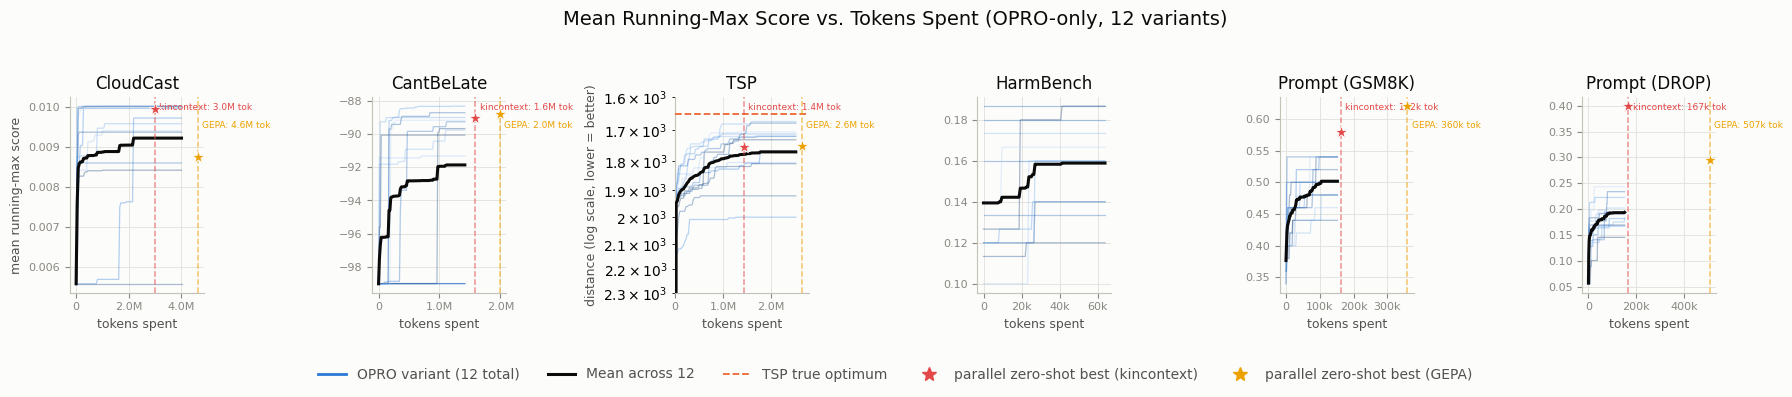

In [5]:
"""Build the 1x6 figure: mean running-max score vs. tokens spent, OPRO-only."""

# TSP's own token extent runs out to ~2.5M, but almost all of its
# convergence happens well before that -- zoom that column in on its own
# (every other column keeps its full autoscaled range).
# All 48 TSP variants converge into their final band by ~20-30k
# tokens (verified against the data on disk); 100k left the last
# 60-70% of the panel as flat tail, so tightened to 40k.
ZOOM_XLIM = {'tsp': (0, 40_000)}

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)

    variants = runs_by_column.get(column_key, {})
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)
    if not variants:
        # Task hasn't produced any usable bank files yet -- leave the panel
        # blank rather than crashing; re-running later will fill it in.
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    trajectories = {
        label: (
            np.array([r['cumulative_tokens_spent'] for r in records], dtype=float),
            running_max(np.array([r['score'] for r in records], dtype=float)),
        )
        for label, records in variants.items()
    }

    # Grid extends to the FURTHEST-along variant (max, not min) -- see
    # step_interpolate's docstring for why that's honest, not fabricated,
    # and lets this panel keep extending on its own as more iterations land.
    grid_end = max(tokens.max() for tokens, _ in trajectories.values())
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    # TSP is plotted as distance (-score) on a log axis instead of raw
    # score (see tsp_style/TSP_YLABEL in the helpers cell above) --
    # everything else (running_max, step_interpolate, the mean line) still
    # operates on score exactly as before; only the values actually handed
    # to ax.plot get sign-flipped for this one column.
    sign = -1.0 if column_key == 'tsp' else 1.0

    interpolated = []
    for label, (tokens, cummax) in trajectories.items():
        resampled = step_interpolate(tokens, cummax, grid)
        interpolated.append(resampled)
        ax.plot(
            grid, sign * resampled, color=color_for(label), linewidth=0.9,
            alpha=0.35, zorder=2,
        )

    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, sign * mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    # Parallel zero-shot discovery overlay: each mutator's total token
    # budget (vertical dashed line) + best raw score reached within it
    # (star marker) -- see the "Parallel zero-shot discovery" cell near
    # the top of this notebook. Drawn before the TSP xlim widening below
    # so its own data point is included in what that widening covers.
    draw_pz_overlay(ax, column_key, sign=sign)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key in ZOOM_XLIM:
        # TSP's parallel_zeroshot token budgets (~1.4-2.7M, see
        # pz_tokens_by_column) run well past the hand-zoomed (0, 40_000)
        # window above -- widen just the upper bound when the overlay
        # needs more room, rather than let draw_pz_overlay's line/star get
        # silently clipped out of the panel.
        x_lo, x_hi = ZOOM_XLIM[column_key]
        budget_max = max(pz_tokens_by_column.get(column_key, {}).values(), default=0)
        x_hi = max(x_hi, budget_max * 1.05)
        ax.set_xlim(x_lo, x_hi)

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO variant (12 total)'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across 12'),
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
] + [
    plt.Line2D(
        [0], [0], color=PZ_MUTATOR_COLOR[m], lw=0, marker='*', markersize=10,
        label=f'parallel zero-shot best ({m})',
    )
    for m in PZ_MUTATORS
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=5,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.15),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent (OPRO-only, 12 variants)',
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

FIGS_DIR = '../figs'
os.makedirs(FIGS_DIR, exist_ok=True)
fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual1_row2_opro_only.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "clean_visual1_row2_opro_only.pdf")}')

plt.show()

## Score evolution vs. tokens spent, by noise value (OPRO-only)

Same 1x6 grid/columns/metric as above, but instead of collapsing to the
`noise=0` subset, includes all 4 noise values OPRO sweeps (`0`, `0.05`,
`0.1`, `0.25`). For each column: one mean-running-max-vs-tokens line per
noise value (mean across that noise value's own 12 mutator x sampling-
strategy variants), colored along a sequential colormap by noise value.
No individual per-variant lines here -- 4 noise groups x 12 variants = 48
per panel was too dense against just the 4 lines that actually matter for
this comparison (confirmed with the user).

In [6]:
"""Discover OPRO run dirs across ALL 4 noise values, grouped by
column x noise_value x variant. Reuses parse_run_dir / noise_token /
find_bank_path / load_bank / inference_model_ok / embed_model_ok /
num_points_ok / sim_thresh_ok / optimizer_llm_ok / filter_tsp_records from
the loader cell above -- same inference-model/embed-model/num_points/
diversity-baseline/optimizer-llm pins, same nested-bank-path handling,
same invalid-TSP-trace filtering, same "skip what's not on disk yet"
behavior, just without the noise=0 filter.
"""

NOISE_TOKEN_TO_VALUE = {'00': 0.0, '005': 0.05, '01': 0.1, '025': 0.25}

runs_by_column_noise: dict[str, dict[float, dict[str, list[dict]]]] = {}

for dirname in sorted(os.listdir(EXPERIMENT_DIR)):
    run_dir = os.path.join(EXPERIMENT_DIR, dirname)
    if not os.path.isdir(run_dir) or not dirname.startswith('opro_'):
        continue
    noise_value = NOISE_TOKEN_TO_VALUE.get(noise_token(dirname))
    if noise_value is None:
        continue  # unexpected noise token -- skip rather than crash
    task_name, column_key, mutator, sampling_strategy = parse_run_dir(dirname)
    if not inference_model_ok(dirname, task_name):
        continue
    if not embed_model_ok(dirname, task_name) or not num_points_ok(dirname, task_name):
        continue
    if not sim_thresh_ok(dirname, task_name) or not optimizer_llm_ok(dirname, task_name):
        continue

    optimizer_label = f'opro_{mutator}_{sampling_strategy}'
    bank_path = find_bank_path(run_dir)
    if bank_path is None:
        continue  # job hasn't produced a bank file yet
    records = load_bank(bank_path)
    records = filter_tsp_records(dirname, task_name, records)
    if not records:
        continue

    runs_by_column_noise.setdefault(column_key, {}).setdefault(
        noise_value, {},
    )[optimizer_label] = records

print(f'{len(runs_by_column_noise)} columns loaded:')
for column_key, by_noise in sorted(runs_by_column_noise.items()):
    coverage = ', '.join(
        f'noise={n}: {len(v):2d}/12' for n, v in sorted(by_noise.items())
    )
    print(f'  {column_key:14s} {coverage}')


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_DE_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_DE_tournament_05_5_-1_15_lowest_scoring_025_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_DE_wheel_05_5_-1_15_lowest_scoring_025_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_005_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 6 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_G

[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_GA_wheel_05_5_-1_15_lowest_scoring_01_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_005_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_025_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_tournament_05_5_-1_15_lowest_scoring_025_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 8 invalid-trace record(s) from opro_gemini-37-flas

[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_tournament_05_5_-1_15_lowest_scoring_01_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_kincontext_tournament_05_5_-1_15_lowest_scoring_025_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
6 columns loaded:
  cantbelate     noise=0.0: 12/12
  cloudcast      noise=0.0: 12/12
  harmbench      noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12
  prompt_drop    noise=0.0: 12/12
  prompt_gsm8k   noise=0.0: 12/12
  tsp            noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12


saved to ../figs/clean_visual1_row2_opro_by_noise.pdf


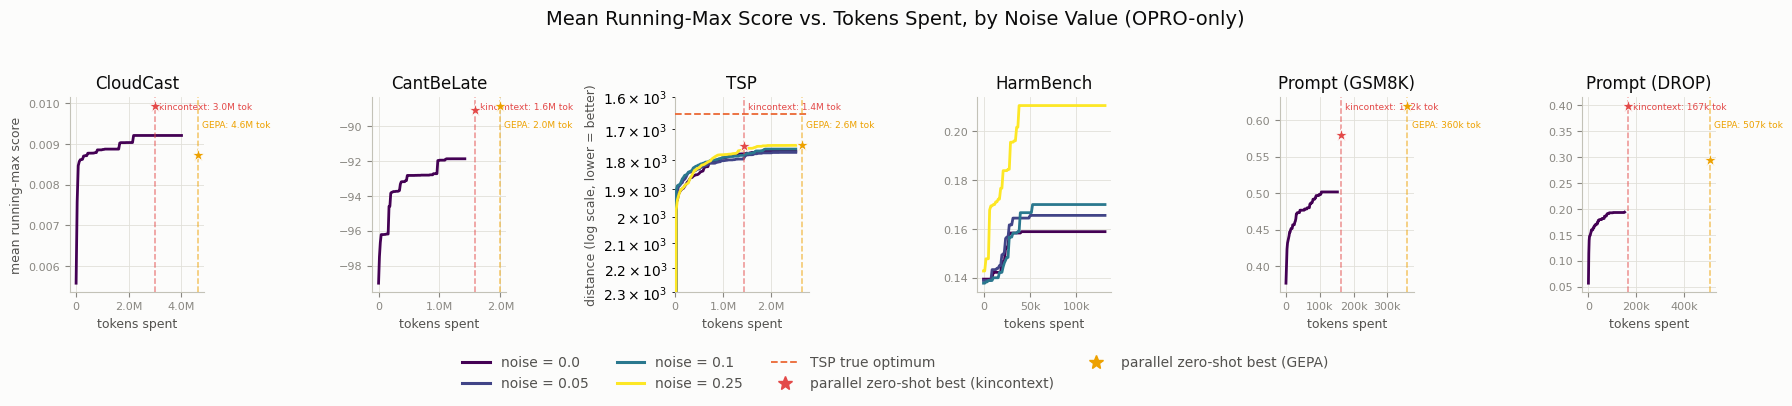

In [7]:
"""Build the 1x6 figure: mean running-max score vs. tokens spent,
OPRO-only, one mean line per noise value (colored by noise), no
per-variant lines (see markdown cell above)."""

NOISE_VALUES = [0.0, 0.05, 0.1, 0.25]
NOISE_CMAP = plt.get_cmap('viridis')
NOISE_NORM = plt.Normalize(vmin=min(NOISE_VALUES), vmax=max(NOISE_VALUES))


def color_for_noise(noise_value: float):
    return NOISE_CMAP(NOISE_NORM(noise_value))


fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    by_noise = runs_by_column_noise.get(column_key, {})
    if not by_noise:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    # One shared grid per column, across every noise group's own variants,
    # extended to the furthest-along point overall -- same "extend to the
    # longest, not the shortest" reasoning as the noise=0 figure above, so
    # all 4 mean lines are drawn on one consistent x range per panel and
    # re-running this after more iterations land just extends it further.
    grid_end = max(
        r['cumulative_tokens_spent']
        for variants in by_noise.values()
        for records in variants.values()
        for r in records
    )
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    # TSP plotted as distance (-score) on a log axis -- see tsp_style/
    # TSP_YLABEL in the helpers cell above and the sign comment in the
    # noise=0 score figure above.
    sign = -1.0 if column_key == 'tsp' else 1.0

    for noise_value in NOISE_VALUES:
        variants = by_noise.get(noise_value)
        if not variants:
            continue
        interpolated = []
        for records in variants.values():
            tokens = np.array(
                [r['cumulative_tokens_spent'] for r in records], dtype=float,
            )
            cummax = running_max(
                np.array([r['score'] for r in records], dtype=float),
            )
            interpolated.append(step_interpolate(tokens, cummax, grid))
        mean_series = np.nanmean(np.vstack(interpolated), axis=0)
        ax.plot(
            grid, sign * mean_series, color=color_for_noise(noise_value),
            linewidth=2.0, zorder=3,
        )

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    # Parallel zero-shot discovery overlay -- see the "Parallel zero-shot
    # discovery" cell near the top of this notebook, and the matching
    # comment in the noise=0 score figure cell above.
    draw_pz_overlay(ax, column_key, sign=sign)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key in ZOOM_XLIM:
        # See the matching widening in the noise=0 score figure cell above
        # -- TSP's parallel_zeroshot budgets run past the hand-zoomed window.
        x_lo, x_hi = ZOOM_XLIM[column_key]
        budget_max = max(pz_tokens_by_column.get(column_key, {}).values(), default=0)
        x_hi = max(x_hi, budget_max * 1.05)
        ax.set_xlim(x_lo, x_hi)

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=color_for_noise(n), lw=2.2, label=f'noise = {n}')
    for n in NOISE_VALUES
] + [
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
] + [
    plt.Line2D(
        [0], [0], color=PZ_MUTATOR_COLOR[m], lw=0, marker='*', markersize=10,
        label=f'parallel zero-shot best ({m})',
    )
    for m in PZ_MUTATORS
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.18),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent, by Noise Value (OPRO-only)',
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual1_row2_opro_by_noise.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "clean_visual1_row2_opro_by_noise.pdf")}')

plt.show()

## Semantic diversity vs. tokens spent (windowed, OPRO-only)

Same shape as the first (noise=0) visual above -- same 12 canonical OPRO
variants, thin per-variant line + one bold dark mean line per column -- but
**y is windowed semantic diversity instead of score**: average pairwise
cosine *distance* across the last 5 chronologically-discovered solutions
(sliding window, not the live population). Plotted as the **raw**
trajectory (no running-max transform) since diversity has no "higher is
strictly better, take the best-so-far" framing the way score does.

**Embedding model, matched to what the real runs actually used**: code
tasks (CloudCast, CantBeLate) -> `nomic-ai/CodeRankEmbed`; text tasks
(HarmBench, Prompt GSM8K/DROP) -> `all-MiniLM-L6-v2`. This is
`generate_experiment_args.py`'s own `get_embed_model` pairing, i.e. the
actual `--embed_model` every `general_rollout` run was launched with (see
`ray_cluster_4927814.out`) -- swapped in from `general_rollout.ipynb`'s
original `Qodo/Qodo-Embed-1-1.5B` pick for CloudCast/CantBeLate, which
didn't match any real run's `embed_model` and was also much slower (1.5B
params vs. CodeRankEmbed's 137M). TSP wasn't part of `general_rollout.ipynb`
(didn't exist yet) so isn't in `get_embed_model`'s pairing either -- its
solutions are raw tour traces like `<trace>3,7,83,...</trace>`, not code,
so it's grouped with the text/`all-MiniLM-L6-v2` bucket (confirmed with the
user).

**No query-prefix asymmetry applied**: `opro.py`'s `QUERY_PREFIXES` gives
`nomic-ai/CodeRankEmbed` an instruction prefix for the *query* side only
when checking one new candidate against the existing pool
(`'Represent this query for searching relevant code: '`) -- a real
distinction for that one-vs-pool retrieval framing. The diversity/
similarity metrics in this notebook are symmetric all-pairs comparisons
among a set of solutions with no natural query/document split, so (matching
how `Qodo/Qodo-Embed-1-1.5B` was embedded here before -- also no prefix)
every text gets encoded plain, unprefixed, on both sides.

**Fresh cache, not `../embedding_cache/`'s existing CantBeLate/CloudCast
files**: those `*__Qodo__Qodo-Embed-1-1.5B.pkl` files are for a different
model entirely now, so building a `*__nomic-ai__CodeRankEmbed.pkl` cache
from scratch is unavoidable, not just an earlier-run staleness issue. This
cell writes to `../embedding_cache/clean_visuals/` (a separate subdirectory
from `../embedding_cache/`'s pre-existing files) so every column's cache
lives in one consistent place going forward.

**Needs a GPU node**: CantBeLate + CloudCast alone need ~3,900 fresh code
embeddings -- CodeRankEmbed's 137M params make this far cheaper than
Qodo-Embed-1.5B was, but still worth a GPU node over CPU-only. The
HarmBench/Prompt/TSP side (`all-MiniLM-L6-v2`) is cheap/CPU-fine regardless.


In [8]:
"""Embedding cache loader + windowed semantic-diversity helper (see
markdown cell above for the task/model pairing and why this writes to a
fresh cache subdirectory instead of ../embedding_cache/'s existing
CantBeLate/CloudCast files)."""

import pickle

import torch
from sentence_transformers import SentenceTransformer

CODE_TASKS = {'cloudcast', 'cantbelate'}
# Matches generate_experiment_args.py's get_embed_model -- the actual
# --embed_model every general_rollout run was launched with for these two
# tasks (see markdown cell above for why this replaced Qodo/Qodo-Embed-1-1.5B).
CODE_EMBED_MODEL = 'nomic-ai/CodeRankEmbed'
TEXT_EMBED_MODEL = 'all-MiniLM-L6-v2'
EMBEDDING_CACHE_DIR = '../embedding_cache/clean_visuals'
DIVERSITY_WINDOW = 5
EMBED_MAX_SEQ_LENGTH = 4096  # see get_or_build_embeddings docstring

EMBED_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


def task_for_column(column_key: str) -> str:
    """column_key -> task_name (undoes the prompt_gsm8k/prompt_drop split)."""
    return 'prompt' if column_key.startswith('prompt_') else column_key


def embed_model_for(column_key: str) -> str:
    """Code embedding model for code tasks, sentence model for everything
    else (text tasks, and TSP -- see markdown cell above)."""
    return CODE_EMBED_MODEL if task_for_column(column_key) in CODE_TASKS else TEXT_EMBED_MODEL


def cache_path_for(column_key: str, model_name: str) -> str:
    filename = f"{column_key}__{model_name.replace('/', '__')}.pkl"
    return os.path.join(EMBEDDING_CACHE_DIR, filename)


def get_or_build_embeddings(
    column_key: str,
    texts: set[str],
    chunk_size: int = 64,
    batch_size: int = 8,
) -> dict[str, np.ndarray]:
    """Load cached embeddings for `texts`, computing + caching what's missing.

    Encodes in small chunks, saving the cache to disk after each one, so a
    future crash/interrupt only loses the in-flight chunk. fp16 only on
    CUDA (halves memory; code snippets can still run up to a few thousand
    tokens even for CodeRankEmbed's much smaller 137M) -- fp16 on CPU
    doesn't help and can be slower/unsupported for some ops, so CPU runs
    stay fp32. Sorting missing texts shortest-first means a batch never
    randomly clusters several of the longest sequences together (the
    worst case for a memory spike).
    """
    model_name = embed_model_for(column_key)
    cache_path = cache_path_for(column_key, model_name)
    os.makedirs(EMBEDDING_CACHE_DIR, exist_ok=True)

    cache: dict[str, np.ndarray] = {}
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            cache = pickle.load(f)

    missing = sorted(texts - cache.keys(), key=len)
    if not missing:
        print(f'[{column_key}] {len(texts)} texts, all cached.')
        return cache

    print(
        f'[{column_key}] embedding {len(missing)} new / {len(texts)} '
        f'total texts with {model_name} on {EMBED_DEVICE}...',
    )
    model_kwargs = {'torch_dtype': torch.float16} if EMBED_DEVICE == 'cuda' else {}
    model = SentenceTransformer(
        model_name, device=EMBED_DEVICE, model_kwargs=model_kwargs,
        # nomic-ai/CodeRankEmbed ships custom modeling code and needs this
        # to load (matches opro.py's own SentenceTransformer call) --
        # harmless no-op for all-MiniLM-L6-v2's stock architecture.
        trust_remote_code=True,
    )
    # Just a min-clamp -- CodeRankEmbed's own native max_seq_length (8192)
    # is already above EMBED_MAX_SEQ_LENGTH, so this still truncates to
    # EMBED_MAX_SEQ_LENGTH exactly as it did for Qodo-Embed (4096 native).
    model.max_seq_length = min(model.max_seq_length, EMBED_MAX_SEQ_LENGTH)

    for start in range(0, len(missing), chunk_size):
        chunk = missing[start : start + chunk_size]
        new_embeddings = model.encode(
            chunk, batch_size=batch_size, show_progress_bar=False,
            convert_to_numpy=True,
        )
        cache.update(zip(chunk, new_embeddings, strict=True))
        with open(cache_path, 'wb') as f:
            pickle.dump(cache, f)
        print(
            f'  [{column_key}] {min(start + chunk_size, len(missing))}'
            f'/{len(missing)} embedded and saved',
        )

    del model
    if EMBED_DEVICE == 'cuda':
        torch.cuda.empty_cache()
    return cache


def windowed_diversity(
    texts: list[str],
    embeddings: dict[str, np.ndarray],
    window: int = DIVERSITY_WINDOW,
) -> np.ndarray:
    """Average pairwise cosine distance across the last `window` solutions.

    Returns an array aligned to texts[window - 1:] -- shorter than `texts`
    itself, since there's no diversity value until `window` solutions
    exist. Empty (not an error) if `texts` itself has fewer than `window`
    entries -- e.g. a TSP variant whose invalid-trace records got filtered
    out (see filter_tsp_records above) down to a handful of real solutions;
    callers should skip a variant entirely when this happens rather than
    plot an all-empty trajectory (see the computation cells below). Duplicate
    solution text is left in deliberately (same no-dedup stance as the
    score visuals above): a duplicate in the window contributes a real
    0-distance pair, honest signal about how much of the window is
    actually novel.
    """
    if len(texts) < window:
        return np.empty(0, dtype=float)

    vecs = np.stack([embeddings[t] for t in texts])
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    unit = vecs / np.where(norms == 0, 1, norms)

    pair_mask = ~np.eye(window, dtype=bool)
    diversity = np.empty(len(texts) - window + 1)
    for out_idx, i in enumerate(range(window - 1, len(texts))):
        w = unit[i - window + 1 : i + 1]
        sims = w @ w.T
        diversity[out_idx] = 1.0 - sims[pair_mask].mean()
    return diversity

In [9]:
"""Compute windowed diversity trajectories per (column, OPRO variant).

Reuses `runs_by_column` from the discovery cell near the top of this
notebook (OPRO-only, noise=0, 12-variant subset) -- no separate loader
needed, this is the exact same run set the first visual plots, just with
diversity instead of score computed over it.
"""

diversity_by_column: dict[str, dict[str, tuple[np.ndarray, np.ndarray]]] = {}

for column_key, variants in runs_by_column.items():
    all_texts = {r['solution'] for records in variants.values() for r in records}
    embeddings = get_or_build_embeddings(column_key, all_texts)

    per_optimizer = {}
    for label, records in variants.items():
        texts = [r['solution'] for r in records]
        diversity = windowed_diversity(texts, embeddings)
        if len(diversity) == 0:
            # Fewer than DIVERSITY_WINDOW real records (e.g. a TSP variant
            # gutted by filter_tsp_records) -- no windowed-diversity value
            # exists yet, skip rather than plot an empty trajectory.
            print(
                f'[{column_key}] skipping {label}: only {len(texts)} '
                f'record(s), need >= {DIVERSITY_WINDOW}',
            )
            continue
        tokens = np.array([r['cumulative_tokens_spent'] for r in records], dtype=float)
        per_optimizer[label] = (tokens[DIVERSITY_WINDOW - 1 :], diversity)
    diversity_by_column[column_key] = per_optimizer

print('diversity trajectories computed for:')
for column_key, per_optimizer in sorted(diversity_by_column.items()):
    if not per_optimizer:
        print(f'  {column_key:14s} 0/12 variants (all too short)')
        continue
    lengths = [len(d) for _, d in per_optimizer.values()]
    print(
        f'  {column_key:14s} {len(per_optimizer):2d}/12 variants, '
        f'trajectory length {min(lengths)}-{max(lengths)}',
    )


[prompt_drop] 548 texts, all cached.
[prompt_gsm8k] 562 texts, all cached.
[tsp] 910 texts, all cached.


[cantbelate] 1725 texts, all cached.
[cloudcast] 1630 texts, all cached.


[harmbench] 581 texts, all cached.
diversity trajectories computed for:
  cantbelate     12/12 variants, trajectory length 147-147
  cloudcast      12/12 variants, trajectory length 52-147
  harmbench      12/12 variants, trajectory length 47-47
  prompt_drop    12/12 variants, trajectory length 30-47
  prompt_gsm8k   12/12 variants, trajectory length 40-47
  tsp            12/12 variants, trajectory length 139-197


/scratch/mansisak/tmp/ipykernel_2534491/2411821845.py:37: RuntimeWarning: Mean of empty slice
  mean_series = np.nanmean(np.vstack(interpolated), axis=0)


saved to ../figs/clean_visual2_diversity_opro_only.pdf


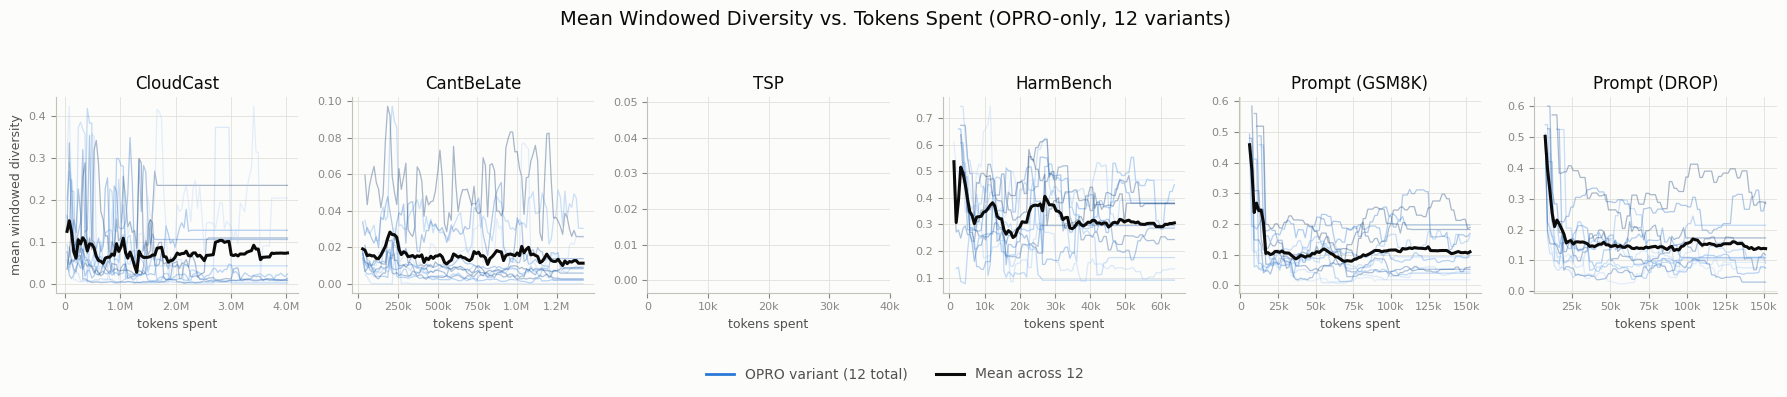

In [10]:
"""Build the 1x6 figure: mean windowed diversity vs. tokens spent,
OPRO-only. Same layout/style as the noise=0 score figure above, just
diversity instead of score and no running-max transform (raw trajectory,
per the markdown cell above)."""

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)

    per_optimizer = diversity_by_column.get(column_key, {})
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)
    if not per_optimizer:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    # Grid extends to the FURTHEST-along variant (max, not min) -- same
    # "read from disk and update" reasoning as the score figure above.
    grid_end = max(tokens.max() for tokens, _ in per_optimizer.values())
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    interpolated = []
    for label, (tokens, diversity) in per_optimizer.items():
        resampled = step_interpolate(tokens, diversity, grid)
        interpolated.append(resampled)
        ax.plot(
            grid, resampled, color=color_for(label), linewidth=0.9,
            alpha=0.35, zorder=2,
        )

    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean windowed diversity', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO variant (12 total)'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across 12'),
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=2,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.15),
)

fig.suptitle(
    'Mean Windowed Diversity vs. Tokens Spent (OPRO-only, 12 variants)',
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual2_diversity_opro_only.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "clean_visual2_diversity_opro_only.pdf")}')

plt.show()


## Semantic diversity vs. tokens spent, by noise value (OPRO-only)

Same idea as the "by noise value" score visual above, applied to the
diversity metric instead: for each column, one mean-windowed-diversity-vs-
tokens line per noise value (mean across that noise value's own 12
variants), colored along the same viridis ramp by noise value, no
per-variant lines. Reuses `runs_by_column_noise` (loaded once, up top,
alongside the noise=0 subset) and the embedding/diversity helpers from the
cell above -- extends the same `embedding_cache/clean_visuals/` cache
files rather than rebuilding them, so only the noise=0.05/0.1/0.25
variants' new solution texts (not already embedded for the noise=0
diversity visual above) actually need fresh GPU work here.

In [11]:
"""Compute windowed diversity trajectories per (column, noise_value, variant).

Embeds once per column across the UNION of all 4 noise groups' texts (not
once per noise group) so get_or_build_embeddings only has to encode each
distinct solution text once, and so this shares/extends the exact same
cache file the noise=0 diversity visual above already populated.
"""

diversity_by_column_noise: dict[str, dict[float, dict[str, tuple[np.ndarray, np.ndarray]]]] = {}

for column_key, by_noise in runs_by_column_noise.items():
    all_texts = {
        r['solution']
        for variants in by_noise.values()
        for records in variants.values()
        for r in records
    }
    embeddings = get_or_build_embeddings(column_key, all_texts)

    per_noise = {}
    for noise_value, variants in by_noise.items():
        per_optimizer = {}
        for label, records in variants.items():
            texts = [r['solution'] for r in records]
            diversity = windowed_diversity(texts, embeddings)
            if len(diversity) == 0:
                # Fewer than DIVERSITY_WINDOW real records (e.g. a TSP
                # variant gutted by filter_tsp_records) -- skip rather
                # than plot an empty trajectory.
                print(
                    f'[{column_key}] skipping noise={noise_value} {label}: '
                    f'only {len(texts)} record(s), need >= {DIVERSITY_WINDOW}',
                )
                continue
            tokens = np.array([r['cumulative_tokens_spent'] for r in records], dtype=float)
            per_optimizer[label] = (tokens[DIVERSITY_WINDOW - 1 :], diversity)
        per_noise[noise_value] = per_optimizer
    diversity_by_column_noise[column_key] = per_noise

print('diversity-by-noise trajectories computed for:')
for column_key, per_noise in sorted(diversity_by_column_noise.items()):
    coverage = ', '.join(
        f'noise={n}: {len(v):2d}/12' for n, v in sorted(per_noise.items())
    )
    print(f'  {column_key:14s} {coverage}')


[prompt_drop] 548 texts, all cached.


[prompt_gsm8k] 562 texts, all cached.
[tsp] 3525 texts, all cached.


[cantbelate] 1725 texts, all cached.
[cloudcast] 1630 texts, all cached.
[harmbench] 2315 texts, all cached.


diversity-by-noise trajectories computed for:
  cantbelate     noise=0.0: 12/12
  cloudcast      noise=0.0: 12/12
  harmbench      noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12
  prompt_drop    noise=0.0: 12/12
  prompt_gsm8k   noise=0.0: 12/12
  tsp            noise=0.0: 12/12, noise=0.05: 12/12, noise=0.1: 12/12, noise=0.25: 12/12


/scratch/mansisak/tmp/ipykernel_2534491/239057400.py:41: RuntimeWarning: Mean of empty slice
  mean_series = np.nanmean(np.vstack(interpolated), axis=0)


saved to ../figs/clean_visual2_diversity_by_noise.pdf


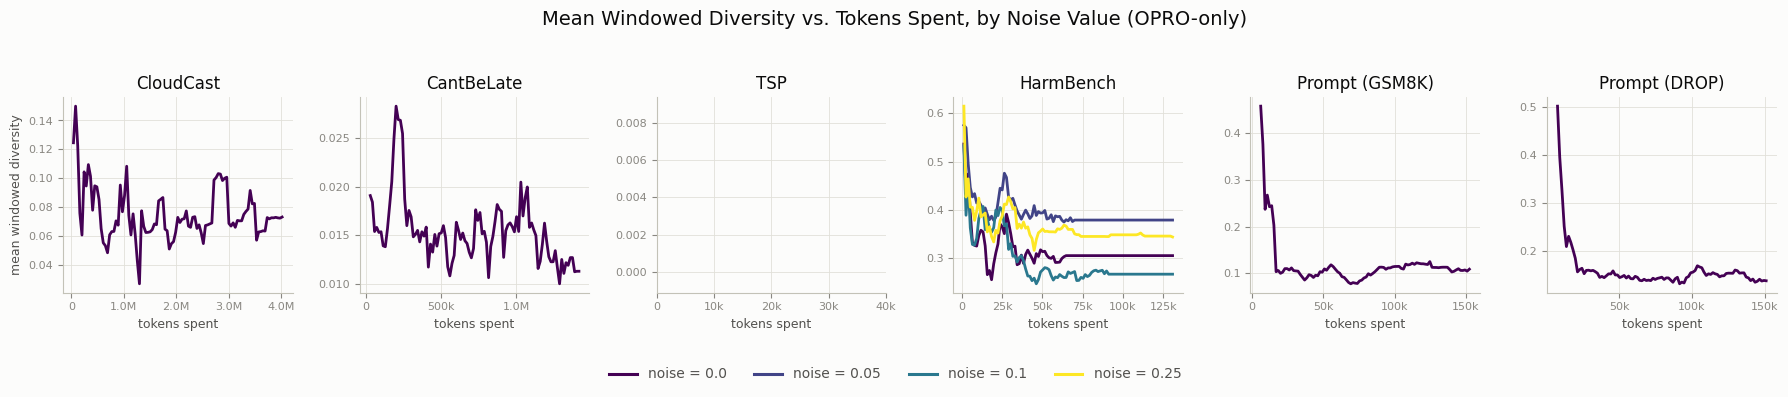

In [12]:
"""Build the 1x6 figure: mean windowed diversity vs. tokens spent,
OPRO-only, one mean line per noise value (colored by noise, same
NOISE_VALUES/color_for_noise as the by-noise score figure above), no
per-variant lines."""

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    per_noise = diversity_by_column_noise.get(column_key, {})
    if not per_noise:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    # One shared grid per column, across every noise group's own variants,
    # extended to the furthest-along point overall -- same reasoning as
    # every other panel in this notebook.
    grid_end = max(
        tokens.max()
        for variants in per_noise.values()
        for tokens, _ in variants.values()
    )
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    for noise_value in NOISE_VALUES:
        variants = per_noise.get(noise_value)
        if not variants:
            continue
        interpolated = [
            step_interpolate(tokens, diversity, grid)
            for tokens, diversity in variants.values()
        ]
        mean_series = np.nanmean(np.vstack(interpolated), axis=0)
        ax.plot(
            grid, mean_series, color=color_for_noise(noise_value),
            linewidth=2.0, zorder=3,
        )

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean windowed diversity', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=color_for_noise(n), lw=2.2, label=f'noise = {n}')
    for n in NOISE_VALUES
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.15),
)

fig.suptitle(
    'Mean Windowed Diversity vs. Tokens Spent, by Noise Value (OPRO-only)',
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual2_diversity_by_noise.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "clean_visual2_diversity_by_noise.pdf")}')

plt.show()


## Trajectory summary scatter: early score & similarity vs. max score achieved (OPRO-only, all noise values)

A different shape from every visual above: each **point** here is one whole
trajectory (one OPRO run), not a time series. 2x6 grid, columns = the same 6
tasks, all 4 noise values pooled together per column (up to 48
trajectories/task).

- **x-axis** (shared within each column, both rows): max score ever achieved
  in that trajectory (its final running-max) -- crash-sentinel scores (see
  `TASK_FAILED_SCORE`, CantBeLate/CloudCast only) excluded, same as
  everywhere else in this notebook family.
- **Top row y**: mean raw score of that trajectory's first N non-crash
  generated solutions.
- **Bottom row y**: mean pairwise COSINE SIMILARITY (not distance -- higher
  means more similar / less diverse) among those same N solutions'
  embeddings -- same embedding-model pairing as the diversity visuals above
  (`nomic-ai/CodeRankEmbed` for CantBeLate/CloudCast, all-MiniLM for the
  rest), reusing the already-populated `embedding_cache/clean_visuals/` cache.
- **"First N"** (confirmed with the user): the seed (record 0) is excluded
  since it isn't optimizer-generated, and so are any crash-sentinel records
  encountered along the way -- i.e. the first N *real* generated solutions,
  skipping over crashes rather than counting them, so both rows are computed
  over the exact same N records per trajectory. A trajectory with fewer than
  N non-crash generated solutions yet is skipped. N is 10 for every task
  (`EARLY_WINDOW_DEFAULT`) -- `TASK_EARLY_WINDOW` exists for a per-task
  override (tried 5 for CantBeLate, reverted back to 10 per the user).
- **Color = mutator** (kincontext/DE/GA/GEPA), not task -- a genuine
  within-panel comparison, so also shape-coded (a 4th category can't clear
  the palette's all-pairs CVD floor on color alone). Two versions below:
  one OLS fit pooled across all 4 mutators per panel, one with a separate
  OLS fit per mutator -- both annotate slope (m) and R^2 per box.

In [13]:
"""Per-trajectory summary stats for the 2x6 scatter below.

Reuses runs_by_column_noise (all 4 noise values, TSP-filtered already) and
get_or_build_embeddings (embeddings already cached from the diversity
visuals above for most texts -- only genuinely new ones, if any, get
embedded here).
"""

# Crash-sentinel scores (see llm_optimizer/tasks/{cant_be_late,cloud_cast}.py's
# FAILED_SCORE) -- not a low real score, so excluded from both the max-score
# x-axis and the early window, same stance as general_rollout.ipynb's
# TASK_FAILED_SCORE. harmbench/prompt/tsp have no such sentinel.
TASK_FAILED_SCORE = {'cantbelate': -100_000.0, 'cloudcast': -100_000.0}

# "First N [non-crash] generated solutions" window, seed excluded.
# TASK_EARLY_WINDOW can override the default per task (tried 5 for
# CantBeLate, reverted back to 10 per the user) -- left in place, empty,
# so a future per-task override is a one-line change again.
EARLY_WINDOW_DEFAULT = 10
TASK_EARLY_WINDOW: dict[str, int] = {}


def early_window_for(task_name: str) -> int:
    return TASK_EARLY_WINDOW.get(task_name, EARLY_WINDOW_DEFAULT)


def first_n_generated(records: list[dict], failed_score: float | None, n: int) -> list[dict]:
    """First `n` non-seed, non-crash-sentinel records, in chronological order."""
    generated = records[1:]  # drop the seed (record 0) -- not optimizer-generated
    if failed_score is not None:
        generated = [r for r in generated if r['score'] != failed_score]
    return generated[:n]


def mean_pairwise_cosine_similarity(texts: list[str], embeddings: dict[str, np.ndarray]) -> float:
    """Mean cosine SIMILARITY (not distance) across every pair in `texts`."""
    vecs = np.stack([embeddings[t] for t in texts])
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    unit = vecs / np.where(norms == 0, 1, norms)
    sims = unit @ unit.T
    pair_mask = ~np.eye(len(texts), dtype=bool)
    return float(sims[pair_mask].mean())


trajectory_points: dict[str, list[dict]] = {}

for column_key, by_noise in runs_by_column_noise.items():
    task_name = task_for_column(column_key)
    failed_score = TASK_FAILED_SCORE.get(task_name)
    window = early_window_for(task_name)

    # Resolve each trajectory's first-N-generated window + full-trajectory
    # max score (crash-sentinel excluded from both), and collect the texts
    # that need embeddings along the way.
    trajectories: list[dict] = []
    early_texts: set[str] = set()
    for variants in by_noise.values():
        for label, records in variants.items():
            early = first_n_generated(records, failed_score, window)
            if len(early) < window:
                continue  # not enough real generated solutions yet
            scores = np.array([r['score'] for r in records], dtype=float)
            valid_scores = scores[scores != failed_score] if failed_score is not None else scores
            if len(valid_scores) == 0:
                continue
            trajectories.append({'label': label, 'early': early, 'max_score': valid_scores.max()})
            early_texts.update(r['solution'] for r in early)

    embeddings = get_or_build_embeddings(column_key, early_texts)

    points = []
    for traj in trajectories:
        early_scores = np.array([r['score'] for r in traj['early']], dtype=float)
        early_texts_list = [r['solution'] for r in traj['early']]
        points.append({
            'label': traj['label'],
            'max_score': traj['max_score'],
            'mean_early_score': early_scores.mean(),
            'mean_early_similarity': mean_pairwise_cosine_similarity(early_texts_list, embeddings),
        })
    trajectory_points[column_key] = points

print('trajectory scatter points (window size per task in parens):')
for column_key in COLUMN_ORDER:
    task_name = task_for_column(column_key)
    window = early_window_for(task_name)
    print(f'  {column_key:14s} (first {window}) {len(trajectory_points.get(column_key, [])):2d} trajectories')


[prompt_drop] 119 texts, all cached.
[prompt_gsm8k] 117 texts, all cached.
[tsp] 373 texts, all cached.
[cantbelate] 120 texts, all cached.


[cloudcast] 120 texts, all cached.
[harmbench] 479 texts, all cached.
trajectory scatter points (window size per task in parens):
  cloudcast      (first 10) 12 trajectories
  cantbelate     (first 10) 12 trajectories
  tsp            (first 10) 48 trajectories
  harmbench      (first 10) 48 trajectories
  prompt_gsm8k   (first 10) 12 trajectories
  prompt_drop    (first 10) 12 trajectories


saved to ../figs/clean_visual3_trajectory_summary_scatter.pdf


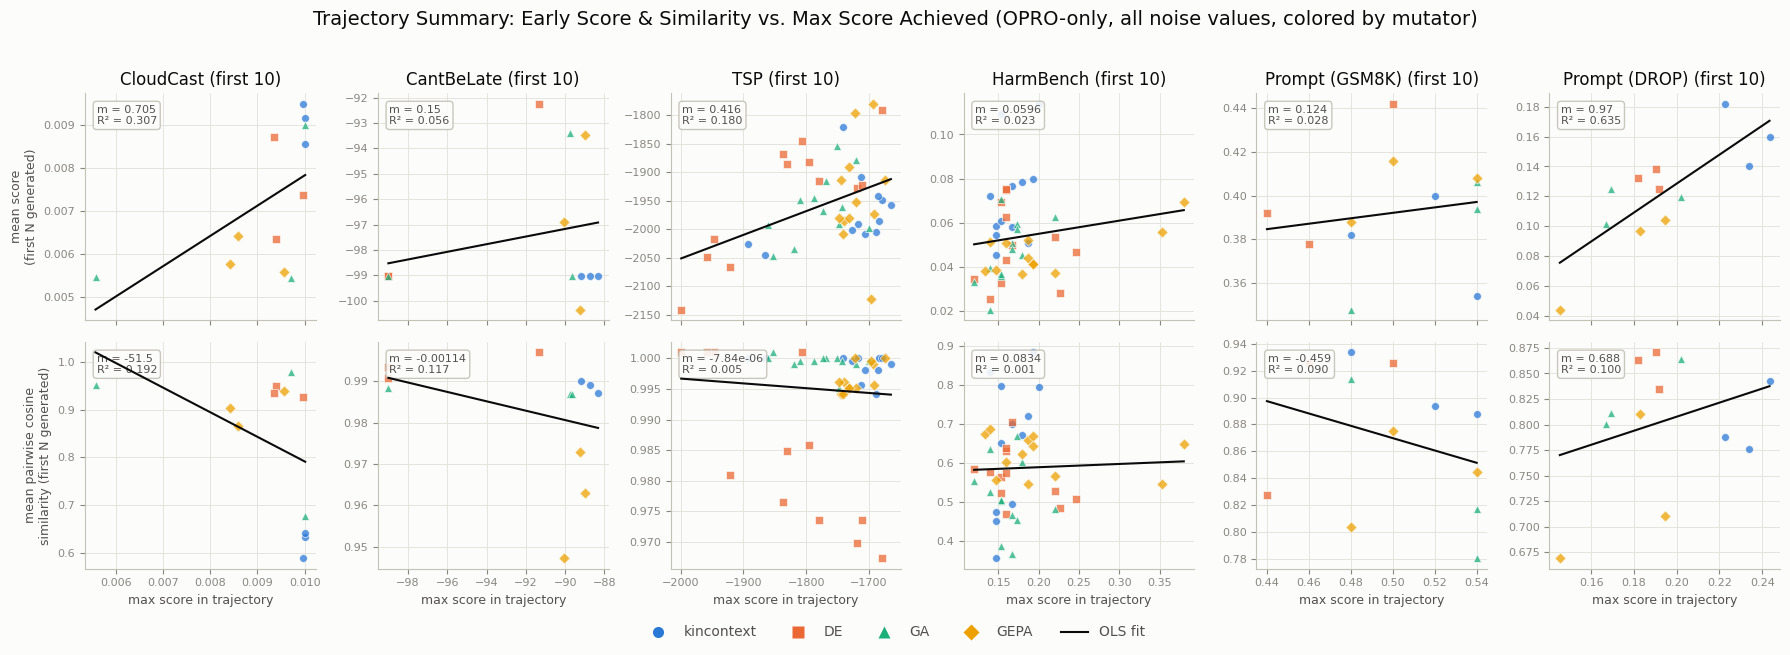

In [14]:
"""Build the 2x6 trajectory-summary scatter figure.

Colored by MUTATOR (not task -- each panel now genuinely mixes 4 colors,
one per mutator, so this is an all-pairs same-panel comparison). Per the
dataviz skill's palette (references/palette.md), only the first 3
categorical slots clear all-pairs CVD separation in both light/dark mode;
a 4th relies on color alone failing the all-pairs floor (yellow vs orange).
Marker SHAPE is added as the secondary channel for the 4th mutator so
identity never depends on hue alone -- the documented mitigation for a
sub-floor slot.

Each panel also gets its own ordinary-least-squares fit line (pooled
across all 4 mutators, not one line per mutator -- a single "does x predict
y here" read per box) with slope (m) and R^2 annotated in a corner box.
"""

MUTATOR_ORDER = ['kincontext', 'DE', 'GA', 'GEPA']
MUTATOR_COLOR = dict(zip(
    MUTATOR_ORDER, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100'], strict=True,
))
MUTATOR_MARKER = dict(zip(MUTATOR_ORDER, ['o', 's', '^', 'D'], strict=True))


def mutator_for_label(label: str) -> str:
    """optimizer_label ('opro_{mutator}_{strategy}') -> mutator.

    Plain split works since every mutator token (kincontext/DE/GA/GEPA) is
    single-word -- no underscore inside it to collide with the split.
    """
    return label.split('_')[1]


def fit_line(x: np.ndarray, y: np.ndarray) -> tuple[float, float, float]:
    """OLS slope/intercept/R^2 for a scatter of (x, y)."""
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
    return slope, intercept, r2


def draw_fit_line(ax: plt.Axes, x: np.ndarray, y: np.ndarray) -> None:
    slope, intercept, r2 = fit_line(x, y)
    x_line = np.array([x.min(), x.max()])
    ax.plot(
        x_line, slope * x_line + intercept, color=INK_PRIMARY,
        linewidth=1.5, linestyle='-', zorder=4,
    )
    ax.text(
        0.05, 0.95, f'm = {slope:.3g}\nR² = {r2:.3f}',
        transform=ax.transAxes, va='top', ha='left', fontsize=8,
        color=INK_SECONDARY,
        bbox={
            'boxstyle': 'round,pad=0.3', 'facecolor': SURFACE,
            'edgecolor': BASELINE, 'alpha': 0.9,
        },
    )


fig, axes = plt.subplots(
    2, 6, figsize=(18, 6), facecolor=SURFACE, sharex='col', sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax_top = axes[0, col_idx]
    ax_bot = axes[1, col_idx]
    ax_top.set_facecolor(SURFACE)
    ax_bot.set_facecolor(SURFACE)
    window = early_window_for(task_for_column(column_key))
    ax_top.set_title(
        f'{COLUMN_TITLES[column_key]} (first {window})', color=INK_PRIMARY, fontsize=12,
    )

    points = trajectory_points.get(column_key, [])
    if not points:
        for ax in (ax_top, ax_bot):
            ax.text(
                0.5, 0.5, 'no data yet', ha='center', va='center',
                color=INK_MUTED, fontsize=10, transform=ax.transAxes,
            )
        continue

    x = np.array([p['max_score'] for p in points])
    y_top = np.array([p['mean_early_score'] for p in points])
    y_bot = np.array([p['mean_early_similarity'] for p in points])
    mutators = [mutator_for_label(p['label']) for p in points]

    for mutator in MUTATOR_ORDER:
        mask = np.array([m == mutator for m in mutators])
        if not mask.any():
            continue
        ax_top.scatter(
            x[mask], y_top[mask], s=32, color=MUTATOR_COLOR[mutator],
            marker=MUTATOR_MARKER[mutator], alpha=0.75,
            linewidths=0.6, edgecolors=SURFACE, zorder=3,
        )
        ax_bot.scatter(
            x[mask], y_bot[mask], s=32, color=MUTATOR_COLOR[mutator],
            marker=MUTATOR_MARKER[mutator], alpha=0.75,
            linewidths=0.6, edgecolors=SURFACE, zorder=3,
        )

    draw_fit_line(ax_top, x, y_top)
    draw_fit_line(ax_bot, x, y_bot)

    ax_bot.set_xlabel('max score in trajectory', color=INK_SECONDARY, fontsize=9)
    for ax in (ax_top, ax_bot):
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        for spine in ax.spines.values():
            spine.set_color(BASELINE)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(color=GRIDLINE, linewidth=0.6)
        ax.set_axisbelow(True)

axes[0, 0].set_ylabel(
    'mean score\n(first N generated)', color=INK_SECONDARY, fontsize=9,
)
axes[1, 0].set_ylabel(
    'mean pairwise cosine\nsimilarity (first N generated)',
    color=INK_SECONDARY, fontsize=9,
)

legend_handles = [
    plt.Line2D(
        [0], [0], marker=MUTATOR_MARKER[m], color='none',
        markerfacecolor=MUTATOR_COLOR[m], markeredgecolor='none',
        markersize=8, label=m,
    )
    for m in MUTATOR_ORDER
] + [
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=1.5, label='OLS fit'),
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=5,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.05),
)

fig.suptitle(
    'Trajectory Summary: Early Score & Similarity vs. Max Score Achieved '
    '(OPRO-only, all noise values, colored by mutator)',
    color=INK_PRIMARY, fontsize=14, y=1.02,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual3_trajectory_summary_scatter.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual3_trajectory_summary_scatter.pdf")}',
)

plt.show()


## Trajectory summary scatter, per-mutator OLS fits (OPRO-only, all noise values)

Same 2x6 grid, same points, same axes as the pooled-fit version above --
but instead of one OLS line fit across all 4 mutators pooled together, each
mutator gets its OWN fit line (and its own slope/R^2), drawn in that
mutator's own color. This asks a different question per panel: not "does x
predict y overall" but "does x predict y *within* each mutator", which can
diverge from the pooled answer (e.g. a mutator-level trend hidden inside a
flat pooled fit, or vice versa -- Simpson's-paradox-shaped effects only
show up in the per-mutator lines). The four (m, R^2) pairs are listed
together in one color-coded corner box per panel rather than four separate
boxes, to keep 12 panels x 4 mutators legible.

saved to ../figs/clean_visual3_trajectory_summary_scatter_per_mutator_fit.pdf


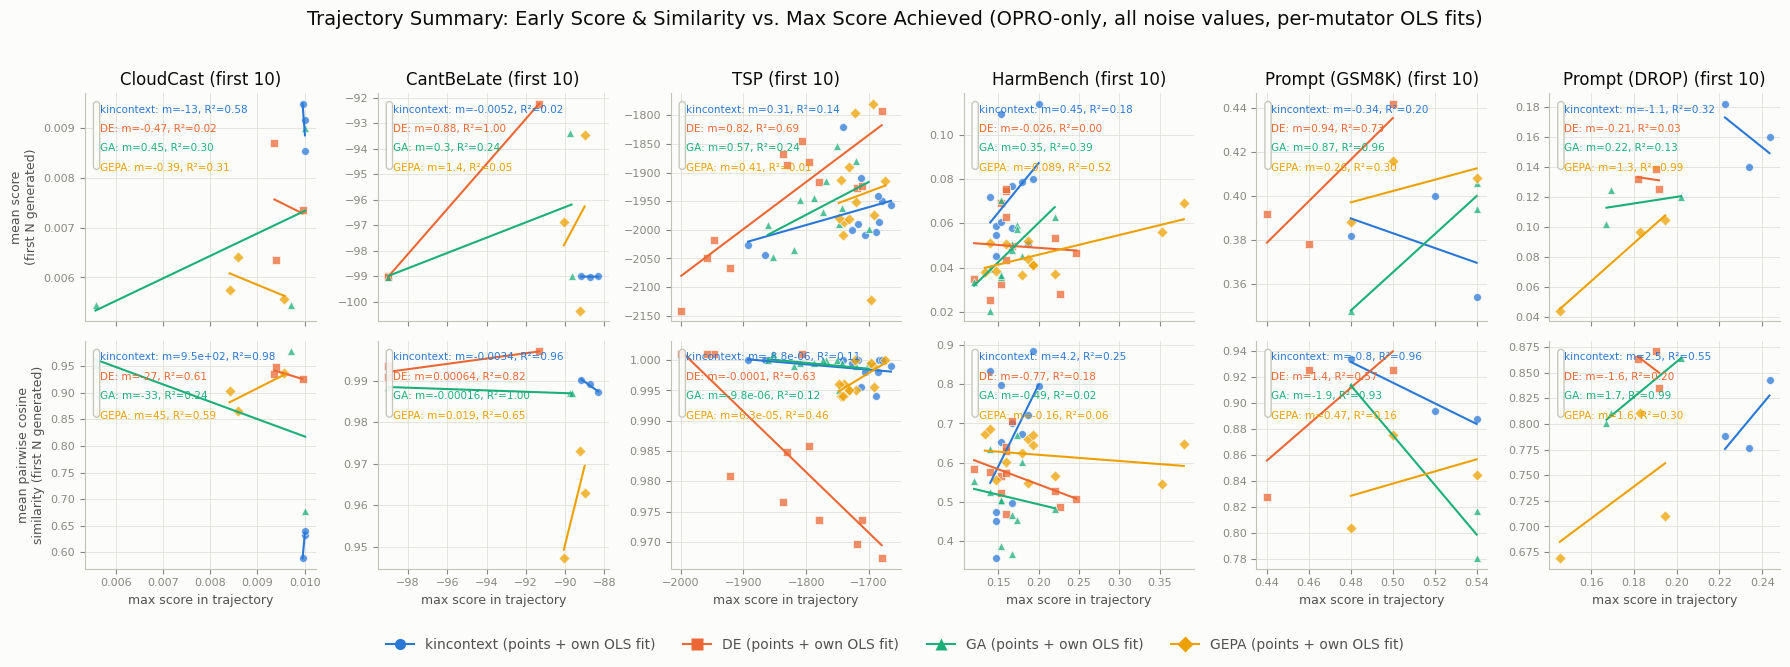

In [15]:
"""Build the 2x6 trajectory-summary scatter figure, per-mutator OLS fits.

Reuses trajectory_points / MUTATOR_ORDER / MUTATOR_COLOR / MUTATOR_MARKER /
mutator_for_label / fit_line from the pooled-fit cell above -- only the fit
line and annotation are per-mutator instead of pooled.
"""

fig, axes = plt.subplots(
    2, 6, figsize=(18, 6), facecolor=SURFACE, sharex='col', sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax_top = axes[0, col_idx]
    ax_bot = axes[1, col_idx]
    ax_top.set_facecolor(SURFACE)
    ax_bot.set_facecolor(SURFACE)
    window = early_window_for(task_for_column(column_key))
    ax_top.set_title(
        f'{COLUMN_TITLES[column_key]} (first {window})', color=INK_PRIMARY, fontsize=12,
    )

    points = trajectory_points.get(column_key, [])
    if not points:
        for ax in (ax_top, ax_bot):
            ax.text(
                0.5, 0.5, 'no data yet', ha='center', va='center',
                color=INK_MUTED, fontsize=10, transform=ax.transAxes,
            )
        continue

    x = np.array([p['max_score'] for p in points])
    y_top = np.array([p['mean_early_score'] for p in points])
    y_bot = np.array([p['mean_early_similarity'] for p in points])
    mutators = np.array([mutator_for_label(p['label']) for p in points])

    fit_lines_top = []
    fit_lines_bot = []
    for mutator in MUTATOR_ORDER:
        mask = mutators == mutator
        color = MUTATOR_COLOR[mutator]

        ax_top.scatter(
            x[mask], y_top[mask], s=32, color=color,
            marker=MUTATOR_MARKER[mutator], alpha=0.75,
            linewidths=0.6, edgecolors=SURFACE, zorder=3,
        )
        ax_bot.scatter(
            x[mask], y_bot[mask], s=32, color=color,
            marker=MUTATOR_MARKER[mutator], alpha=0.75,
            linewidths=0.6, edgecolors=SURFACE, zorder=3,
        )

        # Need >= 2 points (and non-degenerate x) for a fit to mean anything.
        if mask.sum() >= 2 and np.ptp(x[mask]) > 0:
            slope, intercept, r2 = fit_line(x[mask], y_top[mask])
            x_line = np.array([x[mask].min(), x[mask].max()])
            ax_top.plot(
                x_line, slope * x_line + intercept, color=color,
                linewidth=1.5, zorder=4,
            )
            fit_lines_top.append((mutator, slope, r2))

            slope_b, intercept_b, r2_b = fit_line(x[mask], y_bot[mask])
            x_line_b = np.array([x[mask].min(), x[mask].max()])
            ax_bot.plot(
                x_line_b, slope_b * x_line_b + intercept_b, color=color,
                linewidth=1.5, zorder=4,
            )
            fit_lines_bot.append((mutator, slope_b, r2_b))

    for ax, fits in ((ax_top, fit_lines_top), (ax_bot, fit_lines_bot)):
        if not fits:
            continue
        # One shared background box behind the stacked per-mutator lines
        # (matplotlib text is single-color, so each mutator's (m, R^2)
        # line is its own colored text artist; this invisible-text call
        # just reserves/draws the bordered box behind them, sized to fit).
        ax.text(
            0.05, 0.95, '\n'.join('' for _ in fits), transform=ax.transAxes,
            va='top', ha='left', fontsize=7.5, linespacing=1.9,
            bbox={
                'boxstyle': 'round,pad=0.3', 'facecolor': SURFACE,
                'edgecolor': BASELINE, 'alpha': 0.9,
            },
            zorder=5,
        )
        y_cursor = 0.95
        for mutator, slope, r2 in fits:
            ax.text(
                0.065, y_cursor, f'{mutator}: m={slope:.2g}, R²={r2:.2f}',
                transform=ax.transAxes, va='top', ha='left', fontsize=7.5,
                color=MUTATOR_COLOR[mutator], zorder=6,
            )
            y_cursor -= 0.085

    ax_bot.set_xlabel('max score in trajectory', color=INK_SECONDARY, fontsize=9)
    for ax in (ax_top, ax_bot):
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        for spine in ax.spines.values():
            spine.set_color(BASELINE)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(color=GRIDLINE, linewidth=0.6)
        ax.set_axisbelow(True)

axes[0, 0].set_ylabel(
    'mean score\n(first N generated)', color=INK_SECONDARY, fontsize=9,
)
axes[1, 0].set_ylabel(
    'mean pairwise cosine\nsimilarity (first N generated)',
    color=INK_SECONDARY, fontsize=9,
)

legend_handles = [
    plt.Line2D(
        [0], [0], marker=MUTATOR_MARKER[m], color=MUTATOR_COLOR[m],
        markerfacecolor=MUTATOR_COLOR[m], markeredgecolor='none',
        markersize=8, lw=1.5, label=f'{m} (points + own OLS fit)',
    )
    for m in MUTATOR_ORDER
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.07),
)

fig.suptitle(
    'Trajectory Summary: Early Score & Similarity vs. Max Score Achieved '
    '(OPRO-only, all noise values, per-mutator OLS fits)',
    color=INK_PRIMARY, fontsize=14, y=1.02,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual3_trajectory_summary_scatter_per_mutator_fit.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual3_trajectory_summary_scatter_per_mutator_fit.pdf")}',
)

plt.show()


## Similarity-threshold calibration (per-task `sim_thresh` cutoffs)

Not a plot -- an analysis to help pick `--sim_thresh` values for
`llm_optimizer/optimizers/opro.py`'s diversity check (`SolutionBank.eval_cosine_sim`,
gated by `main.py`'s `--sim_thresh`).

**How `sim_thresh` actually works** (confirmed by reading `main.py` +
`opro.py`): when a new candidate is added, its embedding is compared
against every solution currently in the active pool via raw cosine
**similarity** (not distance), and the candidate is rejected only if its
similarity to the single closest pool member exceeds `sim_thresh`. So
**higher `sim_thresh` is MORE admissive** (harder to exceed -> fewer
rejections -> a more lenient/permissive diversity gate); **lower is
stricter** (rejects more candidates as "too similar").

**This analysis**: `llm_optimizer/utils.py`'s `get_similarity_percentiles`
(its last function, and its only caller anywhere in the codebase) -- embeds
a list of texts, computes every pairwise cosine similarity, and returns the
requested percentiles of that distribution. Run per task, pooling **every
solution from all 12 noise=0 OPRO variants** (`runs_by_column` -- already
loaded above, TSP already filtered to valid traces via
`filter_tsp_records`), using each task's own embedding model
(`nomic-ai/CodeRankEmbed` for CantBeLate/CloudCast, all-MiniLM for the rest
-- same pairing as the diversity visuals). `get_similarity_percentiles`
now also passes `trust_remote_code=True` to `SentenceTransformer` (a small
fix to `utils.py` itself, matching `opro.py`'s own call -- it previously
had no caller anywhere in the codebase to expose that this was needed for
a custom-code model like CodeRankEmbed; harmless no-op for
`all-MiniLM-L6-v2`).

**Caveat**: this is the percentile of the *overall pairwise* similarity
distribution (every pair, pooled), not the *max-similarity-to-nearest-pool-
neighbor* distribution `eval_cosine_sim` actually thresholds at generation
time -- a max-of-many-comparisons statistic skews higher than a random pair
drawn from the same pool, so treat these percentiles as a calibration
starting point / ballpark, not an exact "X% of candidates get rejected at
this threshold" guarantee.

In [16]:
"""Similarity-threshold calibration: get_similarity_percentiles per task,
pooling all solutions from the 12 noise=0 OPRO variants (runs_by_column).
"""

from llm_optimizer.utils import get_similarity_percentiles

SIM_PERCENTILES = (25.0, 50.0, 75.0, 90.0, 95.0, 99.0)

sim_threshold_report: dict[str, dict[str, float]] = {}

for column_key in COLUMN_ORDER:
    variants = runs_by_column.get(column_key, {})
    if not variants:
        print(f'[{column_key}] no data yet, skipping')
        continue

    texts = [r['solution'] for records in variants.values() for r in records]
    model_name = embed_model_for(column_key)

    result = get_similarity_percentiles(
        texts, model_name=model_name, percentiles=SIM_PERCENTILES, device=EMBED_DEVICE,
    )
    sim_threshold_report[column_key] = result

    print(f'{COLUMN_TITLES[column_key]:16s} ({len(texts)} solutions pooled, {model_name}):')
    for p in SIM_PERCENTILES:
        print(f'    {p:5.1f}th percentile: {result[f"{p}th_percentile"]:.4f}')
    print()


<All keys matched successfully>


[transformers] Detected the usage of `get_extended_attention_mask`: This function is deprecated and will be removed in v5.12.0. Please use the new API in `transformers.masking_utils`


CloudCast        (1659 solutions pooled, nomic-ai/CodeRankEmbed):
     25.0th percentile: 0.2815
     50.0th percentile: 0.6214
     75.0th percentile: 0.8877
     90.0th percentile: 0.9544
     95.0th percentile: 0.9775
     99.0th percentile: 0.9900



<All keys matched successfully>


CantBeLate       (1812 solutions pooled, nomic-ai/CodeRankEmbed):
     25.0th percentile: 0.9390
     50.0th percentile: 0.9760
     75.0th percentile: 0.9836
     90.0th percentile: 0.9886
     95.0th percentile: 0.9909
     99.0th percentile: 0.9975



...

HarmBench        (612 solutions pooled, all-MiniLM-L6-v2):
     25.0th percentile: 0.2763
     50.0th percentile: 0.3655
     75.0th percentile: 0.4702
     90.0th percentile: 0.5986
     95.0th percentile: 0.6903
     99.0th percentile: 0.8596



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Prompt (GSM8K)   (590 solutions pooled, all-MiniLM-L6-v2):
     25.0th percentile: 0.7147
     50.0th percentile: 0.7690
     75.0th percentile: 0.8179
     90.0th percentile: 0.8695
     95.0th percentile: 0.9070
     99.0th percentile: 0.9655



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Prompt (DROP)    (574 solutions pooled, all-MiniLM-L6-v2):
     25.0th percentile: 0.6115
     50.0th percentile: 0.7034
     75.0th percentile: 0.7737
     90.0th percentile: 0.8305
     95.0th percentile: 0.8707
     99.0th percentile: 0.9405



## Curated initial populations by iteration budget (diversity-rejection / greedy / greedy-no-dedup, OPRO-only)

Uses `llm_optimizer.population_curation_utils.curate_population` (not a notebook-local
reimplementation) to build initial seed populations per-task via `TASK_ITERATION_BUDGETS`:
CloudCast/CantBeLate `2,3,5,10,20`; HarmBench `2,3,4,5,7`; TSP `2,3,5,7,9`; Prompt GSM8K/
DROP `2,3,4,5,7` (all have plenty of runway on disk) -- keys `<= budget` from each pooled
bank; every bank's keys start at `1`, so budget `N` pools exactly `N` entries per bank,
`12 * N` raw candidates total across the 12 pooled runs -- via four curation labels
(`tournament` dropped -- no longer part of this comparison):

- **`diversity` (p=0.98)**: score-first greedy acceptance, rejecting a candidate only if its
  max similarity to an already-accepted member exceeds the pool's own 98th-percentile
  pairwise similarity -- a light-touch filter (rejects roughly the most-similar 2% of
  pairs), now that `population_curation_utils.py`'s percentile-scale bug is fixed.
- **`greedy`**: top-N by score, no diversity filtering, no embedding call at all -- a real
  third branch in `curate_population` (`_greedy_sample`). Originally tried as
  `curation_type='diversity', p=1.0` (100th-percentile threshold makes the diversity accept
  check a no-op), but that hit a floating-point edge case on TSP where a near-duplicate pair
  sitting at the pool's exact max similarity could get wrongly rejected and never backfilled
  -- the direct top-N sort has no such edge case.
- **`greedy_no_dedup`**: same top-N-by-score sort as `greedy`, but `dedup='none'` -- every
  occurrence of a repeated solution counts as its own candidate, so a duplicated high
  scorer can crowd out real diversity. A deliberate worst-case baseline (folded into this
  same grid, row for row against the deduped types, rather than kept as a separate
  section), not a recommended policy.
- **`greedy_n1`**: `greedy` (deduped) with the new `population_size=1` override -- just the
  single best candidate at each budget, no population at all. The degenerate "ignore
  diversity/pop-size entirely" baseline at the other extreme from `greedy_no_dedup`.

`diversity` uses each task's own embedding model (`embed_model_for` -- Qodo-Embed-1.5B for
CloudCast/CantBeLate, all-MiniLM-L6-v2 for the rest), same pairing as the diversity visuals
above, rather than `curate_population`'s flat all-MiniLM default. `greedy`/`greedy_no_dedup`
need no embedding model at all.

**Pool**: the same 12 canonical noise=0 OPRO variant banks used throughout this notebook
(`raw_banks_by_column` below) -- loaded straight from disk as raw `{iter_key: entry}`
dicts, since `curate_population`'s pooling helper walks a bank's own keys directly and
expects that shape, unlike `load_bank`'s flattened, index-ordered list used elsewhere in
this notebook. TSP gets the same invalid-trace filter (`is_valid_tsp_trace`) applied to its
raw bank before pooling, same as everywhere else TSP is touched here.

**Dedup**: `_pool_candidates_within_budget` keeps the HIGHEST observed score when the same
solution text appears more than once in the pooled banks (`dedup='max'`, used by `diversity`
and `greedy` here) -- previously kept whichever occurrence it encountered first. Confirmed
necessary on real data: HarmBench's target generation isn't temperature-pinned (see
`harm_bench.py`/`prompt_lm`), so the exact same trigger text gets independently re-sampled
and re-judged each time it's evaluated -- e.g. one trigger scored anywhere from 0.093 to
0.187 across its 12 separate evaluations at iteration 1 alone. `greedy_no_dedup` uses
`dedup='none'` instead (see above) -- deliberately not fixed, as the worst-case baseline.

4 curation labels x 5 budgets across the 6 tasks (5 budgets each, every task) = 120 curated
populations, each saved to
`../currated_initial_pops_w_diversity_rejection/<task>/<curation_type>_budget_<N>.json` and
reported (token cost, population size actually achieved, n_unique_texts, mean score, max
score) in `curation_df` at the bottom.

In [17]:
"""Raw (unflattened) noise=0 bank dicts per (column, OPRO variant), for the
population-curation section below. Same discovery criteria as the noise=0
score cell above (opro_*, noise=00, inference-model/embed-model/
num_points/diversity-baseline/optimizer-llm pins) -- reuses EXPERIMENT_DIR/
noise_token/parse_run_dir/inference_model_ok/embed_model_ok/num_points_ok/
sim_thresh_ok/optimizer_llm_ok/find_bank_path/is_valid_tsp_trace from the
loader cell -- but keeps each bank as its raw {iter_key: entry} dict
(population_curation_utils.curate_population pools directly over that raw
shape) rather than load_bank's flattened, index-ordered list.
"""

import json

raw_banks_by_column: dict[str, dict[str, dict]] = {}

for dirname in sorted(os.listdir(EXPERIMENT_DIR)):
    run_dir = os.path.join(EXPERIMENT_DIR, dirname)
    if not os.path.isdir(run_dir) or not dirname.startswith('opro_'):
        continue
    if noise_token(dirname) != '00':
        continue
    task_name, column_key, mutator, sampling_strategy = parse_run_dir(dirname)
    if not inference_model_ok(dirname, task_name):
        continue
    if not embed_model_ok(dirname, task_name) or not num_points_ok(dirname, task_name):
        continue
    if not sim_thresh_ok(dirname, task_name) or not optimizer_llm_ok(dirname, task_name):
        continue

    optimizer_label = f'opro_{mutator}_{sampling_strategy}'
    bank_path = find_bank_path(run_dir)
    if bank_path is None:
        continue

    with open(bank_path, encoding='utf-8') as f:
        raw_bank = json.load(f)

    if task_name == 'tsp':
        filtered_bank = {
            k: v for k, v in raw_bank.items() if is_valid_tsp_trace(v['solution'])
        }
        n_dropped = len(raw_bank) - len(filtered_bank)
        if n_dropped:
            print(f'[tsp] dropped {n_dropped} invalid-trace record(s) from {dirname}')
        raw_bank = filtered_bank

    if raw_bank:
        raw_banks_by_column.setdefault(column_key, {})[optimizer_label] = raw_bank

print(f'{len(raw_banks_by_column)} columns loaded for curation:')
for column_key, variants in sorted(raw_banks_by_column.items()):
    sizes = sorted(len(b) for b in variants.values())
    print(
        f'  {column_key:14s} {len(variants):2d}/12 variants  '
        f'raw entry counts {sizes[0]}-{sizes[-1]}',
    )


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_DE_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 6 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 7 invalid-trace record(s) from opro_gemini-37-flash_GA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_GA_wheel_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 8 invalid-trace record(s) from opro_gemini-37-flash_GEPA_wheel_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
6 columns loaded for curation:
  cantbelate     12/12 variants  raw entry counts 151-151
  cloudcast      12/12 variants  raw entry counts 56-151
  harmbench      12/12 variants  raw entry counts 51-51
  prompt_drop    12/12 variants  raw entry counts 34-51
  prompt_gsm8k   12/12 variants  raw entry counts 44-51
  tsp            12/12 variants  raw entry counts 143-201


In [18]:
"""Curate initial populations via population_curation_utils.curate_population,
one per (task, curation label, iteration_budget) -- pooling the 12 noise=0
raw bank dicts loaded above. Three curation labels:

- diversity (p=0.98): now that population_curation_utils.py's percentile
  bug is fixed, a genuine 98th-percentile similarity threshold --
  permissive, rejects only the most-similar ~2% of pairs.
- greedy: top-N by score, no diversity filtering, no embedding call at
  all. A real third branch in curate_population (_greedy_sample) --
  originally tried as curation_type='diversity', p=1.0 (100th-percentile
  threshold makes the diversity accept check a no-op), but that hit a
  floating-point edge case on TSP where a near-duplicate pair sitting at
  the pool's exact max similarity could get wrongly rejected and never
  backfilled, so the population fell short of the true top-N. The direct
  top-N sort has no such edge case (verified: exact match against a plain
  top-K sort, including the TSP case that broke the p=1.0 trick).
- greedy_no_dedup: same top-N-by-score sort, but dedup='none' -- every
  occurrence of a repeated solution counts as its own candidate, so a
  duplicated high scorer can crowd out real diversity. A deliberate
  worst-case baseline (see population_curation_utils.py's dedup='none'
  docstring), not a recommended policy -- included here (rather than as
  a separate section) so it's directly comparable, row for row, against
  the deduped curation types above.
- greedy_n1: greedy (deduped, top-N-by-score) with the new
  population_size=1 override -- just the single best candidate at each
  budget, no population at all. The degenerate "ignore diversity/pop-size
  entirely, take the best you've seen" baseline at the other extreme
  from greedy_no_dedup.

(tournament dropped -- no longer part of this comparison.)

Diversity's embedding model follows the same embed_model_for() task
pairing used everywhere else in this notebook rather than
curate_population's flat all-MiniLM default. greedy/greedy_no_dedup need
no embedding model at all.

Each curated population is reported (token cost, mean/max score, and
n_unique_texts -- how many of the population's slots are actually
distinct solutions vs. wasted on exact repeats -- assembled into
curation_df in the next cell) and saved to disk under
POPULATION_DIR/<column>/<label>_budget_<N>.json so it's usable as an
actual OPRO seed population later.
"""

import json

from llm_optimizer.population_curation_utils import curate_population

DEFAULT_ITERATION_BUDGETS = [2, 3, 4, 5]
# CloudCast, CantBeLate, and HarmBench have plenty of runway on disk
# (raw bank sizes 76-201, 201, and 51 entries respectively, per the
# coverage report above) to support larger budgets too -- CloudCast/
# CantBeLate extended with 10, 20 and dropped 4; HarmBench swapped 10
# for 7. TSP swapped 4 for 7 and dropped 10 (raw bank sizes 143-201).
# Prompt GSM8K/DROP extended with 7 (raw bank sizes 51, plenty of
# runway). Every other task keeps the default 4.
TASK_ITERATION_BUDGETS = {
    'cloudcast': [2, 3, 5, 10, 20],
    'cantbelate': [2, 3, 5, 10, 20],
    'harmbench': [2, 3, 4, 5, 7],
    'tsp': [2, 3, 5, 7, 9],
    'prompt_gsm8k': [2, 3, 4, 5, 7],
    'prompt_drop': [2, 3, 4, 5, 7],
}


def iteration_budgets_for(column_key):
    return TASK_ITERATION_BUDGETS.get(column_key, DEFAULT_ITERATION_BUDGETS)


# (report label, curate_population's curation_type, p, dedup,
# population_size) -- p is unused for the greedy variants but
# curate_population still accepts the kwarg, so pass nan there for a
# self-documenting report column rather than a misleading leftover
# number. population_size=None keeps curate_population's adaptive
# min(max_population_size, total_candidates) sizing; greedy_n1 overrides
# it to an exact 1.
CURATION_CONFIGS = [
    ('diversity', 'diversity', 0.98, 'max', None),
    ('greedy', 'greedy', float('nan'), 'max', None),
    ('greedy_no_dedup', 'greedy', float('nan'), 'none', None),
    ('greedy_n1', 'greedy', float('nan'), 'max', 1),
]
POPULATION_DIR = '../currated_initial_pops_w_diversity_rejection'

curation_rows = []

for column_key in COLUMN_ORDER:
    variants = raw_banks_by_column.get(column_key, {})
    if not variants:
        print(f'[{column_key}] no raw banks loaded, skipping')
        continue

    solution_banks = list(variants.values())
    embed_model_name = embed_model_for(column_key)
    task_dir = os.path.join(POPULATION_DIR, column_key)
    os.makedirs(task_dir, exist_ok=True)

    for label, curation_type, p, dedup, population_size in CURATION_CONFIGS:
        for budget in iteration_budgets_for(column_key):
            population = curate_population(
                solution_banks,
                iteration_budget=budget,
                curation_type=curation_type,
                p=p,
                embed_model_name=embed_model_name,
                dedup=dedup,
                population_size=population_size,
            )
            if not population:
                print(
                    f'[{column_key}] {label} (p={p}) budget={budget}: '
                    'empty population, skipping',
                )
                continue

            scores = np.array([item['score'] for item in population], dtype=float)
            token_cost = population[-1].get('cumulative_tokens_spent', 0)
            n_unique_texts = len({item['solution'] for item in population})

            out_path = os.path.join(task_dir, f'{label}_budget_{budget}.json')
            save_payload = {
                str(idx): {
                    'solution': item['solution'],
                    'score': item['score'],
                    **(
                        {'cumulative_tokens_spent': item['cumulative_tokens_spent']}
                        if 'cumulative_tokens_spent' in item
                        else {}
                    ),
                }
                for idx, item in enumerate(population)
            }
            with open(out_path, 'w', encoding='utf-8') as f:
                json.dump(save_payload, f, indent=2, ensure_ascii=False)

            curation_rows.append({
                'task': COLUMN_TITLES[column_key],
                'curation_type': label,
                'p': p,
                'iteration_budget': budget,
                'population_size': len(population),
                'n_unique_texts': n_unique_texts,
                'token_cost': token_cost,
                'mean_score': scores.mean(),
                'max_score': scores.max(),
            })

print(f'saved curated populations to {POPULATION_DIR}/')


<All keys matched successfully>


<All keys matched successfully>


<All keys matched successfully>


<All keys matched successfully>


<All keys matched successfully>


...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

saved curated populations to ../currated_initial_pops_w_diversity_rejection/


In [19]:
"""Curated-population report: token cost + mean/max score, one row per
(task, curation_type, iteration_budget). Row order follows COLUMN_ORDER x
CURATION_CONFIGS x ITERATION_BUDGETS (curation_rows' insertion order) --
not re-sorted, so it reads top-to-bottom the same way the rest of this
notebook orders tasks.
"""

import pandas as pd

curation_df = pd.DataFrame(curation_rows)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
curation_df


,task,curation_type,p,iteration_budget,population_size,n_unique_texts,token_cost,mean_score,max_score
0,CloudCast,diversity,0.98,2,13,13,63700,0.01,0.01
1,CloudCast,diversity,0.98,3,15,15,155455,0.01,0.01
2,CloudCast,diversity,0.98,5,15,15,445192,0.01,0.01
3,CloudCast,diversity,0.98,10,15,15,1306874,0.01,0.01
4,CloudCast,diversity,0.98,20,15,15,3365475,0.01,0.01
...,...,...,...,...,...,...,...,...,...
115,Prompt (DROP),greedy_n1,NaN,2,1,1,18780,0.16,0.16
116,Prompt (DROP),greedy_n1,NaN,3,1,1,44492,0.21,0.21
117,Prompt (DROP),greedy_n1,NaN,4,1,1,75614,0.21,0.21
118,Prompt (DROP),greedy_n1,NaN,5,1,1,108771,0.21,0.21


## Curated populations overlaid on mean running-max score (token cost vs. max score)

One scatter dot per curated population from the section above -- x = token cost (sum
across the 12 pooled noise=0 runs at that iteration budget), y = max score achieved in
that population (TSP in the same distance/log space as its line panel) -- colored by
curation type (tournament / diversity / greedy; the only 3 palette slots that clear the
all-pairs CVD floor for a scatter chart per the dataviz skill's `references/palette.md`).
Two companion figures, reusing the exact background from the two score figures above:

- `clean_visual1_row2_opro_only_with_curated_pops.pdf` -- noise=0 backdrop.
- `clean_visual1_row2_opro_by_noise_with_curated_pops.pdf` -- by-noise backdrop (the
  populations themselves are still pooled from noise=0 data only -- see the curation
  section above -- shown against this backdrop too for scale reference against the full
  noise-value comparison).

**Caveat**: a population dot's x-position is the SUM of tokens spent across all 12
pooled source runs at that budget, not one run's own cumulative spend the way this axis
is used everywhere else in this notebook -- read these dots as "total cost to build this
seed population", not a literal point on any single trajectory.

**TSP's x-axis is widened just for these two figures** (`TSP_POP_XLIM`, computed from the
actual population token costs) -- its line panel is normally zoomed to `(0, 40k)` tokens
for legibility, but every TSP population costs 95k-412k tokens and would be invisible at
that zoom.

saved to ../figs/clean_visual1_row2_opro_only_with_curated_pops.pdf


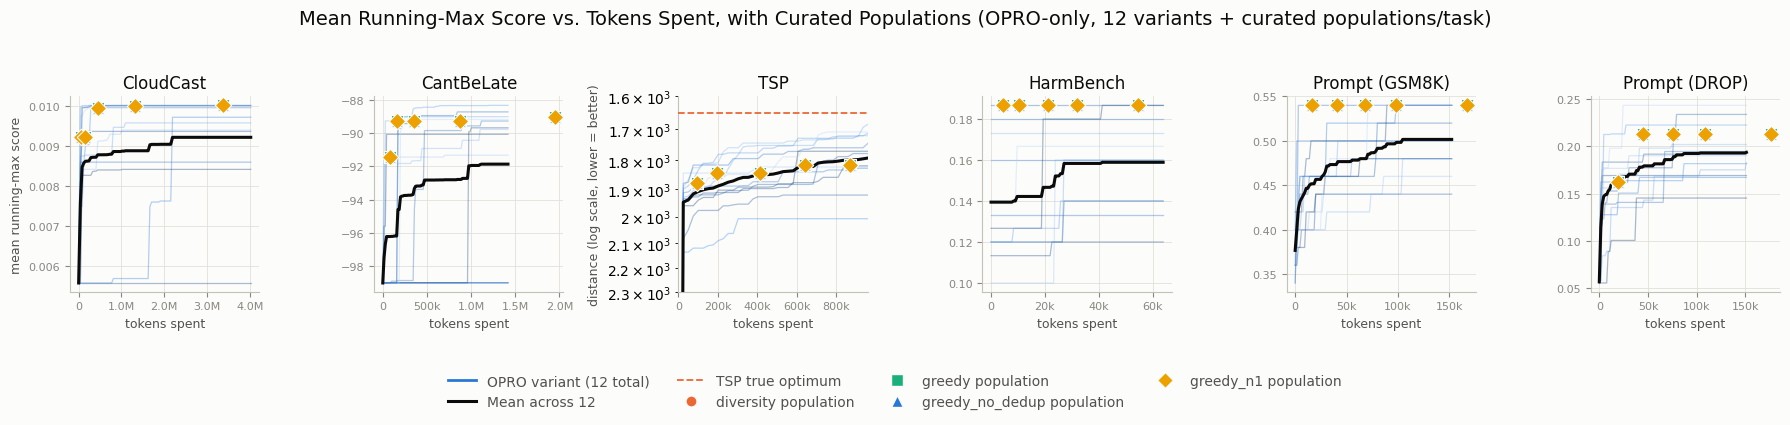

In [20]:
"""Companion to the noise=0 score figure above (clean_visual1_row2_opro_only),
with one scatter dot per curated population (token cost, max score in the
population) overlaid, colored by curation_type. Saved as a SEPARATE file
so the original clean line-only figure is untouched.

Population token_cost is the sum across the 12 pooled source runs at that
budget (see the curation cell above) -- a different quantity than this
axis's usual "one run's own cumulative tokens spent", so read these dots
as "total cost to build this seed population", not literally comparable
run-for-run to where a single trajectory is at that x position.

TSP's line panel is normally zoomed to (0, 40k) tokens for legibility (see
the noise=0 score figure above), but every TSP population costs 95k-412k
tokens -- widened just for this companion figure (TSP_POP_XLIM below) so
the population dots are actually visible; the original clean figure keeps
its tight zoom.
"""

# 4 curation labels now (diversity/greedy/greedy_no_dedup/greedy_n1) --
# only the first 3 palette slots (blue/orange/aqua) clear the all-pairs
# CVD floor for a scatter-type chart, per references/palette.md; slot 4
# (yellow) pairs with orange and fails that floor on color alone, so
# CURATION_MARKER below carries a secondary (shape) channel for every
# label -- same documented mitigation as MUTATOR_MARKER in the
# trajectory-scatter section above.
CURATION_COLOR = {
    'diversity': '#eb6834',  # slot 2 (orange)
    'greedy': '#1baf7a',  # slot 3 (aqua)
    'greedy_no_dedup': '#2a78d6',  # slot 1 (blue)
    'greedy_n1': '#eda100',  # slot 4 (yellow) -- needs the marker-shape
    # channel below, not color-safe alone against orange.
}
CURATION_MARKER = {
    'diversity': 'o',
    'greedy': 's',
    'greedy_no_dedup': '^',
    'greedy_n1': 'D',
}

TSP_POP_XLIM = (
    0,
    float(curation_df.loc[curation_df['task'] == 'TSP', 'token_cost'].max()) * 1.1,
)


def scatter_curated_populations(ax, column_key, sign, df=None):
    """`df` defaults to the max-dedup curation_df; the min-dedup
    comparison section below passes curation_df_min_dedup instead so
    this same helper draws both variants' companion figures."""
    if df is None:
        df = curation_df
    rows = df[df['task'] == COLUMN_TITLES[column_key]]
    for curation_type, color in CURATION_COLOR.items():
        sub = rows[rows['curation_type'] == curation_type]
        if sub.empty:
            continue
        ax.scatter(
            sub['token_cost'], sign * sub['max_score'],
            color=color, marker=CURATION_MARKER[curation_type], s=70,
            zorder=6, edgecolors=SURFACE, linewidths=0.8,
        )


fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)

    variants = runs_by_column.get(column_key, {})
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)
    if not variants:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    trajectories = {
        label: (
            np.array([r['cumulative_tokens_spent'] for r in records], dtype=float),
            running_max(np.array([r['score'] for r in records], dtype=float)),
        )
        for label, records in variants.items()
    }

    grid_end = max(tokens.max() for tokens, _ in trajectories.values())
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    sign = -1.0 if column_key == 'tsp' else 1.0

    interpolated = []
    for label, (tokens, cummax) in trajectories.items():
        resampled = step_interpolate(tokens, cummax, grid)
        interpolated.append(resampled)
        ax.plot(
            grid, sign * resampled, color=color_for(label), linewidth=0.9,
            alpha=0.35, zorder=2,
        )

    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, sign * mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    scatter_curated_populations(ax, column_key, sign)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key == 'tsp':
        ax.set_xlim(*TSP_POP_XLIM)  # widened for this companion figure only
    elif column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO variant (12 total)'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across 12'),
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
] + [
    plt.Line2D(
        [0], [0], marker=CURATION_MARKER[curation_type], color='none',
        markerfacecolor=color, markeredgecolor=SURFACE, markersize=8,
        label=f'{curation_type} population',
    )
    for curation_type, color in CURATION_COLOR.items()
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.24),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent, with Curated Populations '
    '(OPRO-only, 12 variants + curated populations/task)',
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual1_row2_opro_only_with_curated_pops.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual1_row2_opro_only_with_curated_pops.pdf")}',
)

plt.show()


saved to ../figs/clean_visual1_row2_opro_by_noise_with_curated_pops.pdf


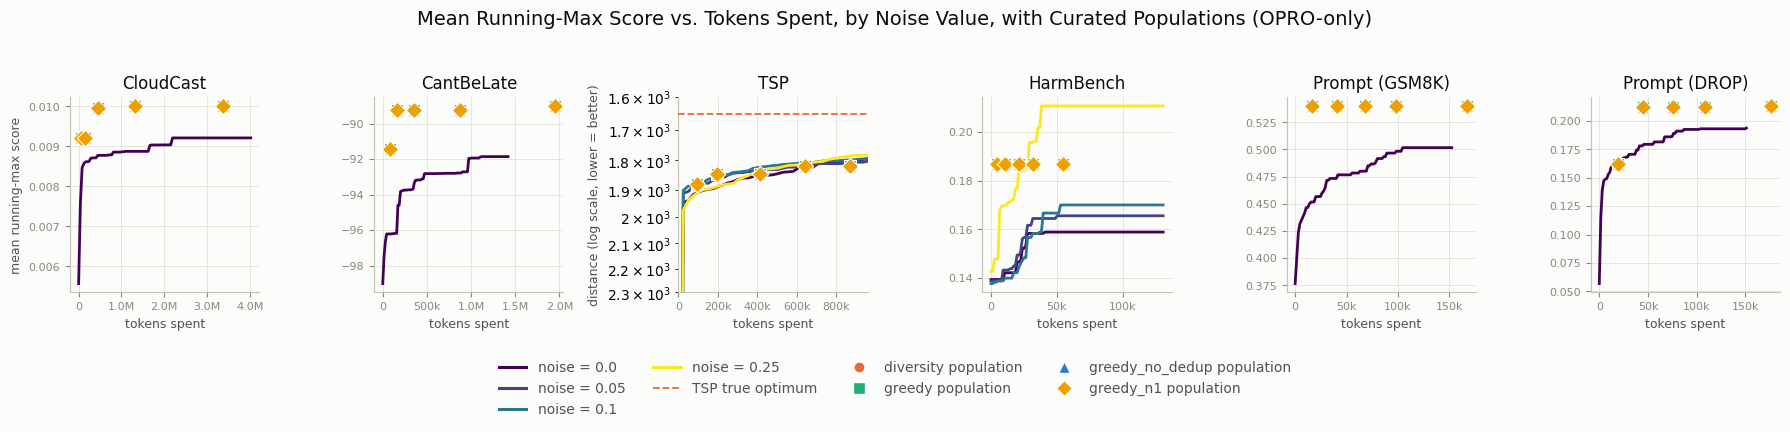

In [21]:
"""Companion to the by-noise score figure above (clean_visual1_row2_opro_by_noise),
with the same curated-population scatter overlay as the companion figure
above. Reuses CURATION_COLOR / TSP_POP_XLIM / scatter_curated_populations
from that cell. Curated populations are pooled from noise=0 data only (see
the curation section above) regardless of which figure they're drawn on --
shown here too so their token cost / max score can be read against the
full noise-value comparison, not just the noise=0-only backdrop.
"""

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    by_noise = runs_by_column_noise.get(column_key, {})
    if not by_noise:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    grid_end = max(
        r['cumulative_tokens_spent']
        for variants in by_noise.values()
        for records in variants.values()
        for r in records
    )
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    sign = -1.0 if column_key == 'tsp' else 1.0

    for noise_value in NOISE_VALUES:
        variants = by_noise.get(noise_value)
        if not variants:
            continue
        interpolated = []
        for records in variants.values():
            tokens = np.array(
                [r['cumulative_tokens_spent'] for r in records], dtype=float,
            )
            cummax = running_max(
                np.array([r['score'] for r in records], dtype=float),
            )
            interpolated.append(step_interpolate(tokens, cummax, grid))
        mean_series = np.nanmean(np.vstack(interpolated), axis=0)
        ax.plot(
            grid, sign * mean_series, color=color_for_noise(noise_value),
            linewidth=2.0, zorder=3,
        )

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    scatter_curated_populations(ax, column_key, sign)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key == 'tsp':
        ax.set_xlim(*TSP_POP_XLIM)
    elif column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=color_for_noise(n), lw=2.2, label=f'noise = {n}')
    for n in NOISE_VALUES
] + [
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
] + [
    plt.Line2D(
        [0], [0], marker=CURATION_MARKER[curation_type], color='none',
        markerfacecolor=color, markeredgecolor=SURFACE, markersize=8,
        label=f'{curation_type} population',
    )
    for curation_type, color in CURATION_COLOR.items()
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.26),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent, by Noise Value, with Curated '
    'Populations (OPRO-only)',
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual1_row2_opro_by_noise_with_curated_pops.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual1_row2_opro_by_noise_with_curated_pops.pdf")}',
)

plt.show()


## Compare-and-contrast: dedup='min' instead of 'max'

Everything above dedups a repeated solution text by keeping its HIGHEST observed score
(`population_curation_utils.py`'s `dedup='max'` default -- see the curation section's
markdown for why: HarmBench's target generation isn't temperature-pinned, so identical
candidate text gets independently re-sampled/re-judged and can land a different score each
time it's evaluated).

This section reruns the same grid -- same tasks, same `TASK_ITERATION_BUDGETS` -- with
`dedup='min'` instead: the LOWEST observed score wins for a repeated solution. Restricted to
`diversity`/`greedy` only (not `greedy_no_dedup`, which already ignores dedup entirely by
design, and not `greedy_n1`, which isn't part of this comparison). Not a recommended policy,
purely a lever to see how much the dedup choice actually moves the curated populations and
the resulting figures. Saved to a separate directory
(`currated_initial_pops_w_diversity_rejection_min_dedup/`) so it doesn't touch the primary
(max-dedup) populations above.

Note: `token_cost` is unaffected by this switch either way -- it's summed from each pooled
bank's `cumulative_tokens_spent` before dedup even happens, so only `population_size`,
`mean_score`, and `max_score` (and the companion-figure dots' y-position) can differ between
the two versions.

In [22]:
"""Curate the same (task, iteration_budget) grid as the main curation
cell above, but with dedup='min' -- see the markdown cell above. Reuses
raw_banks_by_column / TASK_ITERATION_BUDGETS / iteration_budgets_for /
embed_model_for from that section; only the dedup policy, curation-label
subset, and output locations differ.

Deliberately NOT reusing the main section's CURATION_CONFIGS wholesale:
greedy_no_dedup already means dedup='none' (forcing dedup='min' on top
would just silently override that, making it a confusing duplicate of
plain 'greedy' here), and greedy_n1's population_size=1 override isn't
part of this comparison -- so this section covers diversity/greedy only.
"""

MIN_DEDUP_CURATION_CONFIGS = [
    ('diversity', 0.98),
    ('greedy', float('nan')),
]
POPULATION_DIR_MIN_DEDUP = '../currated_initial_pops_w_diversity_rejection_min_dedup'

curation_rows_min_dedup = []

for column_key in COLUMN_ORDER:
    variants = raw_banks_by_column.get(column_key, {})
    if not variants:
        print(f'[{column_key}] no raw banks loaded, skipping')
        continue

    solution_banks = list(variants.values())
    embed_model_name = embed_model_for(column_key)
    task_dir = os.path.join(POPULATION_DIR_MIN_DEDUP, column_key)
    os.makedirs(task_dir, exist_ok=True)

    for curation_type, p in MIN_DEDUP_CURATION_CONFIGS:
        for budget in iteration_budgets_for(column_key):
            population = curate_population(
                solution_banks,
                iteration_budget=budget,
                curation_type=curation_type,
                p=p,
                embed_model_name=embed_model_name,
                dedup='min',
            )
            if not population:
                print(
                    f'[{column_key}] {curation_type} (p={p}) budget={budget}: '
                    'empty population, skipping',
                )
                continue

            scores = np.array([item['score'] for item in population], dtype=float)
            token_cost = population[-1].get('cumulative_tokens_spent', 0)

            out_path = os.path.join(task_dir, f'{curation_type}_budget_{budget}.json')
            save_payload = {
                str(idx): {
                    'solution': item['solution'],
                    'score': item['score'],
                    **(
                        {'cumulative_tokens_spent': item['cumulative_tokens_spent']}
                        if 'cumulative_tokens_spent' in item
                        else {}
                    ),
                }
                for idx, item in enumerate(population)
            }
            with open(out_path, 'w', encoding='utf-8') as f:
                json.dump(save_payload, f, indent=2, ensure_ascii=False)

            curation_rows_min_dedup.append({
                'task': COLUMN_TITLES[column_key],
                'curation_type': curation_type,
                'p': p,
                'iteration_budget': budget,
                'population_size': len(population),
                'token_cost': token_cost,
                'mean_score': scores.mean(),
                'max_score': scores.max(),
            })

curation_df_min_dedup = pd.DataFrame(curation_rows_min_dedup)
print(f'saved min-dedup curated populations to {POPULATION_DIR_MIN_DEDUP}/')
print(f'{len(curation_df_min_dedup)} rows (vs. {len(curation_df)} in the max-dedup curation_df)')


<All keys matched successfully>


<All keys matched successfully>


<All keys matched successfully>


<All keys matched successfully>


<All keys matched successfully>


...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

saved min-dedup curated populations to ../currated_initial_pops_w_diversity_rejection_min_dedup/
60 rows (vs. 120 in the max-dedup curation_df)


saved to ../figs/clean_visual1_row2_opro_only_with_curated_pops_min_dedup.pdf


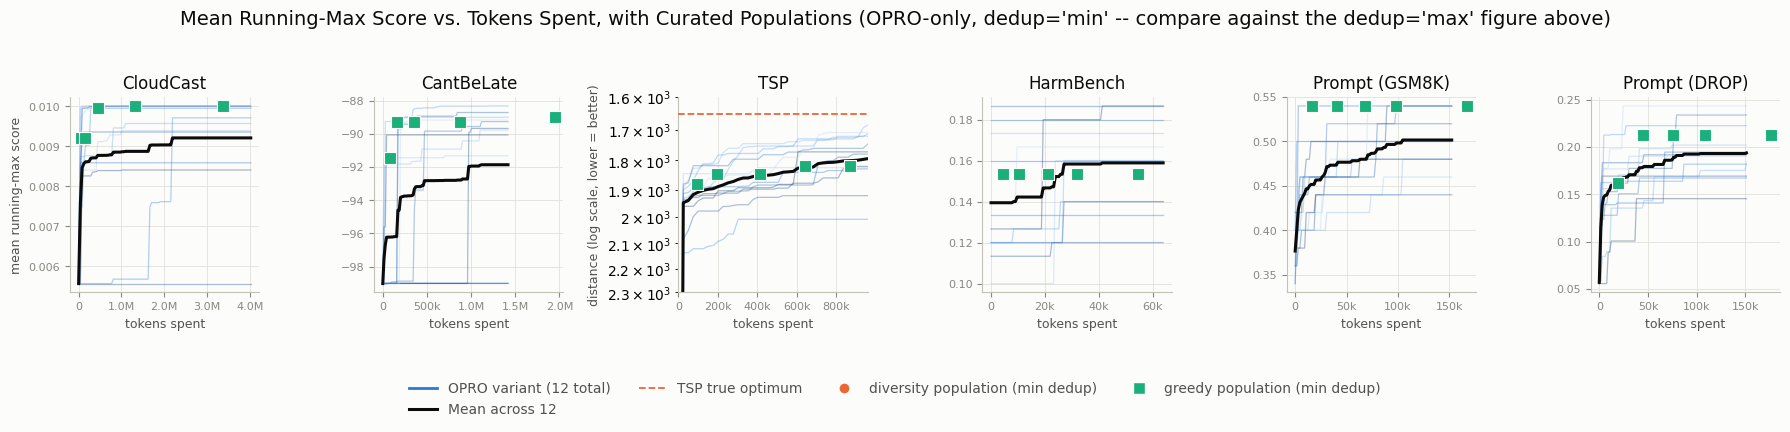

In [23]:
"""Min-dedup companion to the noise=0 score figure (compare against
clean_visual1_row2_opro_only_with_curated_pops.pdf built earlier from the
max-dedup curation_df). Identical plotting logic to that cell -- only the
data source (curation_df_min_dedup) and output filename differ.
"""

TSP_POP_XLIM_MIN_DEDUP = (
    0,
    float(
        curation_df_min_dedup.loc[
            curation_df_min_dedup['task'] == 'TSP', 'token_cost',
        ].max(),
    ) * 1.1,
)

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)

    variants = runs_by_column.get(column_key, {})
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)
    if not variants:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    trajectories = {
        label: (
            np.array([r['cumulative_tokens_spent'] for r in records], dtype=float),
            running_max(np.array([r['score'] for r in records], dtype=float)),
        )
        for label, records in variants.items()
    }

    grid_end = max(tokens.max() for tokens, _ in trajectories.values())
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    sign = -1.0 if column_key == 'tsp' else 1.0

    interpolated = []
    for label, (tokens, cummax) in trajectories.items():
        resampled = step_interpolate(tokens, cummax, grid)
        interpolated.append(resampled)
        ax.plot(
            grid, sign * resampled, color=color_for(label), linewidth=0.9,
            alpha=0.35, zorder=2,
        )

    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, sign * mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    scatter_curated_populations(ax, column_key, sign, df=curation_df_min_dedup)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key == 'tsp':
        ax.set_xlim(*TSP_POP_XLIM_MIN_DEDUP)
    elif column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO variant (12 total)'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across 12'),
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
] + [
    plt.Line2D(
        [0], [0], marker=CURATION_MARKER[curation_type], color='none',
        markerfacecolor=color, markeredgecolor=SURFACE, markersize=8,
        label=f'{curation_type} population (min dedup)',
    )
    for curation_type, color in CURATION_COLOR.items()
    # only diversity/greedy are actually plotted here (see
    # MIN_DEDUP_CURATION_CONFIGS above) -- skip legend entries for
    # curation types this section never draws.
    if curation_type in curation_df_min_dedup['curation_type'].unique()
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.26),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent, with Curated Populations '
    "(OPRO-only, dedup='min' -- compare against the dedup='max' figure above)",
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual1_row2_opro_only_with_curated_pops_min_dedup.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual1_row2_opro_only_with_curated_pops_min_dedup.pdf")}',
)

plt.show()


saved to ../figs/clean_visual1_row2_opro_by_noise_with_curated_pops_min_dedup.pdf


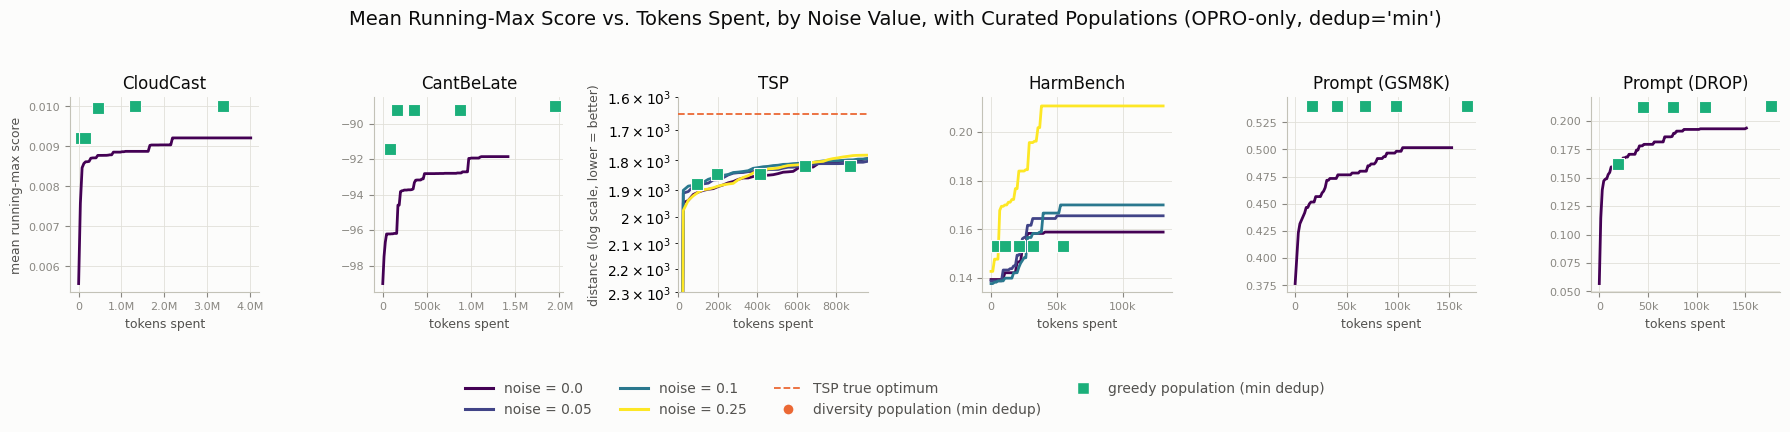

In [24]:
"""Min-dedup companion to the by-noise score figure (compare against
clean_visual1_row2_opro_by_noise_with_curated_pops.pdf built earlier).
Identical plotting logic -- only the data source (curation_df_min_dedup)
and output filename differ. Reuses TSP_POP_XLIM_MIN_DEDUP from the cell
above.
"""

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    by_noise = runs_by_column_noise.get(column_key, {})
    if not by_noise:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    grid_end = max(
        r['cumulative_tokens_spent']
        for variants in by_noise.values()
        for records in variants.values()
        for r in records
    )
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    sign = -1.0 if column_key == 'tsp' else 1.0

    for noise_value in NOISE_VALUES:
        variants = by_noise.get(noise_value)
        if not variants:
            continue
        interpolated = []
        for records in variants.values():
            tokens = np.array(
                [r['cumulative_tokens_spent'] for r in records], dtype=float,
            )
            cummax = running_max(
                np.array([r['score'] for r in records], dtype=float),
            )
            interpolated.append(step_interpolate(tokens, cummax, grid))
        mean_series = np.nanmean(np.vstack(interpolated), axis=0)
        ax.plot(
            grid, sign * mean_series, color=color_for_noise(noise_value),
            linewidth=2.0, zorder=3,
        )

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    scatter_curated_populations(ax, column_key, sign, df=curation_df_min_dedup)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key == 'tsp':
        ax.set_xlim(*TSP_POP_XLIM_MIN_DEDUP)
    elif column_key in ZOOM_XLIM:
        ax.set_xlim(*ZOOM_XLIM[column_key])

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=color_for_noise(n), lw=2.2, label=f'noise = {n}')
    for n in NOISE_VALUES
] + [
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
] + [
    plt.Line2D(
        [0], [0], marker=CURATION_MARKER[curation_type], color='none',
        markerfacecolor=color, markeredgecolor=SURFACE, markersize=8,
        label=f'{curation_type} population (min dedup)',
    )
    for curation_type, color in CURATION_COLOR.items()
    # only diversity/greedy are actually plotted here (see
    # MIN_DEDUP_CURATION_CONFIGS above) -- skip legend entries for
    # curation types this section never draws.
    if curation_type in curation_df_min_dedup['curation_type'].unique()
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.26),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent, by Noise Value, with Curated '
    "Populations (OPRO-only, dedup='min')",
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(
        FIGS_DIR, 'clean_visual1_row2_opro_by_noise_with_curated_pops_min_dedup.pdf',
    ),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual1_row2_opro_by_noise_with_curated_pops_min_dedup.pdf")}',
)

plt.show()


## TSP problem-size comparison (num_points = 80/100/200, OPRO-only, min-dedup curated populations)

Same 12 canonical OPRO variants and same panel config as the TSP column of
`clean_visual1_row2_opro_only_with_curated_pops_min_dedup.pdf` above (log/
inverted distance axis, true-optimum reference line, faint per-variant +
bold mean running-max lines, `dedup='min'` curated-population overlay) --
but as its own 1x3 figure, one panel per TSP instance size now on disk:
`num_points` 80, 100 (the original column), and 200.

**Axis style is shared, axis RANGE is not**: all 3 panels use the same log/
inverted-distance formatting, but the actual x/y zoom is computed
per-panel (`compute_tsp_zoom` below) rather than forced identical --
num_points=80/100/200 are different problem instances with their own true
optimum and their own convergence pace (verified against the data on
disk: num_points=200 hasn't converged even by 300k of its ~1M-token
budget, vs. ~40-50k for 80/100), so a single shared numeric range would
badly crop at least one panel (confirmed with the user).

**True optimum per num_points**: solved the same way as `TSP_TRUE_OPTIMUM`
above (ortools CP-SAT `AddCircuit`, `status=OPTIMAL`) -- see
`TSP_TRUE_OPTIMUM_BY_NUM_POINTS` below.

**Canonical-variant filter**: num_points=200 additionally has a 60-dir
`llm_judge`/`sim_thresh` sweep on disk (5 extra dirs per each of the 12
canonical (mutator, sampling_strategy) combos, all still noise=0) that
doesn't exist at num_points=80/100 -- without an explicit filter these
would silently overwrite the canonical runs (alphabetical `os.listdir`
order puts several sweep variants after the canonical one for the same
mutator/strategy). Filtered to the literal `_None_00_0_tsp_` substring
(default `llm_judge=None`, `sim_thresh=0.0`) -- confirmed against disk:
exactly 12/72 num_points=200 opro/tsp/noise=0 dirs match it, one per
canonical variant.


In [25]:
"""Discover OPRO/noise=0 TSP run dirs across num_points = 80/100/200 (see
markdown cell above). Reuses parse_run_dir/noise_token/find_bank_path/
load_bank unchanged (none of them depend on num_points) and reuses the
num_points=100 slice already loaded as runs_by_column['tsp'] /
raw_banks_by_column['tsp'] instead of re-discovering/re-filtering it.

num_points sits in the dirname as main.py's --num_points value, 3 tokens
from the end (backend, num_points, num_decimals, benchmark -- benchmark is
an unused leftover default for tsp runs): dirname.rsplit('_', 3)[1].
"""

import json


def num_points_of(dirname: str) -> int:
    return int(dirname.rsplit('_', 3)[1])


def is_valid_tsp_trace_n(solution: str, num_points: int) -> bool:
    """Same check as is_valid_tsp_trace above, parametrized on num_points
    instead of hardcoding TSP_NUM_POINTS=100."""
    if '<trace>' not in solution or '</trace>' not in solution:
        return False
    inner = solution[
        solution.index('<trace>') + len('<trace>') : solution.index('</trace>')
    ]
    try:
        points = [int(p.strip()) for p in inner.split(',') if p.strip()]
    except ValueError:
        return False
    return sorted(points) == list(range(num_points))


NUM_POINTS_VALUES = [80, 100, 200]

tsp_runs_by_num_points: dict[int, dict[str, list[dict]]] = {
    100: runs_by_column.get('tsp', {}),
}
tsp_raw_banks_by_num_points: dict[int, dict[str, dict]] = {
    100: raw_banks_by_column.get('tsp', {}),
}

for dirname in sorted(os.listdir(EXPERIMENT_DIR)):
    run_dir = os.path.join(EXPERIMENT_DIR, dirname)
    if not os.path.isdir(run_dir) or not dirname.startswith('opro_') or '_tsp_' not in dirname:
        continue
    if noise_token(dirname) != '00' or '_None_00_0_tsp_' not in dirname:
        continue  # noise != 0, or the llm_judge/sim_thresh sweep (see markdown cell)
    npv = num_points_of(dirname)
    if npv == 100 or npv not in NUM_POINTS_VALUES:
        continue  # 100 already covered by the reused runs_by_column['tsp'] above

    _, _, mutator, sampling_strategy = parse_run_dir(dirname)
    optimizer_label = f'opro_{mutator}_{sampling_strategy}'
    bank_path = find_bank_path(run_dir)
    if bank_path is None:
        continue

    with open(bank_path, encoding='utf-8') as f:
        raw_bank = json.load(f)
    valid_raw_bank = {
        k: v for k, v in raw_bank.items() if is_valid_tsp_trace_n(v['solution'], npv)
    }
    n_dropped = len(raw_bank) - len(valid_raw_bank)
    if n_dropped:
        print(f'[tsp num_points={npv}] dropped {n_dropped} invalid-trace record(s) from {dirname}')
    if not valid_raw_bank:
        continue
    tsp_raw_banks_by_num_points.setdefault(npv, {})[optimizer_label] = valid_raw_bank

    records = load_bank(bank_path)
    records = [r for r in records if is_valid_tsp_trace_n(r['solution'], npv)]
    tsp_runs_by_num_points.setdefault(npv, {})[optimizer_label] = records

print('TSP variants loaded per num_points:')
for npv in NUM_POINTS_VALUES:
    variants = tsp_runs_by_num_points.get(npv, {})
    lens = sorted(len(r) for r in variants.values())
    missing = sorted(set(OPRO_VARIANT_ORDER) - set(variants))
    print(
        f'  num_points={npv:3d}  {len(variants):2d}/12 variants  '
        f'record counts {lens[0] if lens else 0}-{lens[-1] if lens else 0}'
        + (f'  MISSING: {missing}' if missing else ''),
    )


[tsp num_points=200] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_DE_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_200_3_drop
[tsp num_points=200] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_200_3_drop
[tsp num_points=80] dropped 8 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_80_3_drop
[tsp num_points=200] dropped 6 invalid-trace record(s) from opro_gemini-37-flash_GA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_200_3_drop
[tsp num_points=80] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GA_wheel_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_80_3_drop

[tsp num_points=200] dropped 7 invalid-trace record(s) from opro_gemini-37-flash_GEPA_wheel_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_200_3_drop
[tsp num_points=80] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_wheel_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_80_3_drop
[tsp num_points=200] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_200_3_drop
[tsp num_points=80] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_80_3_drop
[tsp num_points=200] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1

In [26]:
"""True-optimum TSP distances for num_points = 80/100/200 (seed=0,
num_decimals=3 -- main.py's untouched defaults for every tsp run on disk,
same as TSP_TRUE_OPTIMUM's own derivation above).

100's value is the existing TSP_TRUE_OPTIMUM computed at the top of this
notebook. 80/200 were solved the same way (numpy rng seeded 0 generates
that num_points' x/y coordinates exactly as TravelingSalesman.__init__
does, then solve_tsp(..., 'ortools_exact') -- the same CP-SAT AddCircuit
solver traveling_salesman.py itself uses, status=OPTIMAL both times) run
once offline and pasted in here as literals, since re-solving a 200-city
instance's CP-SAT model on every notebook run would cost up to
solve_tsp's own 120s time cap.
"""

TSP_TRUE_OPTIMUM_BY_NUM_POINTS = {
    80: -1408.449,
    100: TSP_TRUE_OPTIMUM,  # -1651.054, already computed above
    200: -2219.653,
}


In [27]:
"""Curated (dedup='min') initial populations for the num_points=80/200 TSP
pools, for the num_points comparison figure below. Same diversity(p=0.98)/
greedy grid as the min-dedup curation section above
(MIN_DEDUP_CURATION_CONFIGS, TASK_ITERATION_BUDGETS['tsp'] =
[2, 3, 5, 7, 9]), applied to tsp_raw_banks_by_num_points[80]/[200] instead
of the pooled noise=0 banks used everywhere else.

num_points=100's own min-dedup curation is NOT redone here -- reused
directly from curation_df_min_dedup (already built above, filtered to
task=='TSP') into the same per-num_points dict below, so all 3 problem
sizes end up in one consistent structure without recomputing 100's
populations twice.
"""

POPULATION_DIR_MIN_DEDUP_TSP_NP = (
    '../currated_initial_pops_w_diversity_rejection_min_dedup/tsp_num_points'
)

curation_df_min_dedup_by_num_points: dict[int, pd.DataFrame] = {
    100: curation_df_min_dedup[curation_df_min_dedup['task'] == 'TSP'].reset_index(drop=True),
}

for npv in (80, 200):
    variants = tsp_raw_banks_by_num_points.get(npv, {})
    if not variants:
        print(f'[tsp num_points={npv}] no raw banks loaded, skipping curation')
        continue

    solution_banks = list(variants.values())
    embed_model_name = embed_model_for('tsp')
    task_dir = os.path.join(POPULATION_DIR_MIN_DEDUP_TSP_NP, str(npv))
    os.makedirs(task_dir, exist_ok=True)

    rows = []
    for curation_type, p in MIN_DEDUP_CURATION_CONFIGS:
        for budget in iteration_budgets_for('tsp'):
            population = curate_population(
                solution_banks,
                iteration_budget=budget,
                curation_type=curation_type,
                p=p,
                embed_model_name=embed_model_name,
                dedup='min',
            )
            if not population:
                print(
                    f'[tsp num_points={npv}] {curation_type} (p={p}) '
                    f'budget={budget}: empty population, skipping',
                )
                continue

            scores = np.array([item['score'] for item in population], dtype=float)
            token_cost = population[-1].get('cumulative_tokens_spent', 0)

            out_path = os.path.join(task_dir, f'{curation_type}_budget_{budget}.json')
            save_payload = {
                str(idx): {
                    'solution': item['solution'],
                    'score': item['score'],
                    **(
                        {'cumulative_tokens_spent': item['cumulative_tokens_spent']}
                        if 'cumulative_tokens_spent' in item
                        else {}
                    ),
                }
                for idx, item in enumerate(population)
            }
            with open(out_path, 'w', encoding='utf-8') as f:
                json.dump(save_payload, f, indent=2, ensure_ascii=False)

            rows.append({
                'task': 'TSP',
                'curation_type': curation_type,
                'p': p,
                'iteration_budget': budget,
                'population_size': len(population),
                'token_cost': token_cost,
                'mean_score': scores.mean(),
                'max_score': scores.max(),
            })

    curation_df_min_dedup_by_num_points[npv] = pd.DataFrame(rows)
    print(f'[tsp num_points={npv}] saved {len(rows)} curated populations to {task_dir}/')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[tsp num_points=200] saved 10 curated populations to ../currated_initial_pops_w_diversity_rejection_min_dedup/tsp_num_points/200/


saved to ../figs/clean_visual_tsp_by_num_points_with_curated_pops_min_dedup.pdf


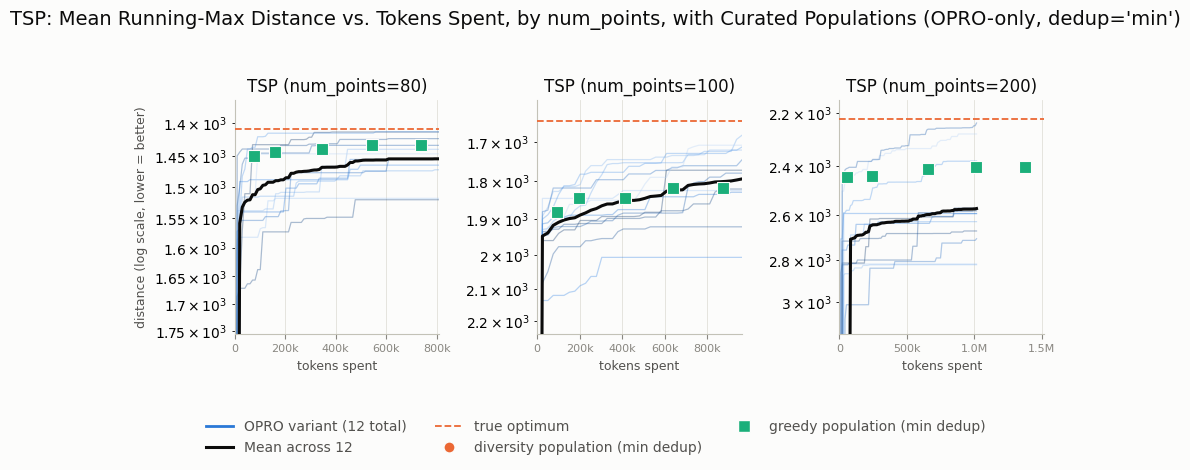

In [28]:
"""Build the 1x3 figure: mean running-max distance vs. tokens spent for
TSP, one panel per num_points (80/100/200), reusing the exact panel style
from the noise=0 dedup='min' curated-populations figure above (tsp_style's
log/inverted distance axis, REFERENCE_LINE_COLOR optimum line, faint
per-variant + bold mean lines, CURATION_COLOR/CURATION_MARKER-coded
curated-population overlay) -- just applied per num_points instead of
being one column in the 6-task grid. Axis STYLE (log scale, inverted,
tokens_fmt formatting, colors) is identical across all 3 panels; the
actual x/y RANGE is computed per panel via compute_tsp_zoom rather than
forced identical (see markdown cell above)."""


def compute_tsp_zoom(
    grid: np.ndarray,
    per_variant_dist: dict[str, np.ndarray],
    true_optimum_dist: float,
    escape_multiple: float = 1.3,
    x_pad_multiple: float = 2.0,
    y_pad_fraction: float = 0.05,
) -> tuple[tuple[float, float], tuple[float, float]]:
    """Auto-zoom (xlim, ylim) for one TSP num_points panel, generalizing
    the hand-tuned ZOOM_XLIM['tsp'] = (0, 40_000) / TSP_YLIM_DIST =
    (1600, 2300) used for num_points=100 elsewhere in this notebook to
    whatever token budget/convergence pace a given problem size actually
    has (sanity-checked against num_points=100's own data: this heuristic
    lands on ~(0, 51k) / (1602, 2243) -- close to the manually-tuned
    (40k) / (1600, 2300) above).

    - x-zoom: the mean-across-variants running-max distance's own escape
      point -- first grid token at which it drops to within
      `escape_multiple`x the true optimum -- padded by `x_pad_multiple`
      (capped at the panel's actual token extent). Distinct problem sizes
      converge on very different token budgets (num_points=200 hadn't
      converged even by 300k tokens in the raw data, vs. ~40-50k for
      80/100), so this is deliberately not a single shared constant.
    - y-zoom: near edge is `true_optimum_dist` with a small margin below
      it; far edge is the worst per-variant distance actually visible
      within the x-zoom window (from the escape point onward), padded by
      `y_pad_fraction`. Same intent as TSP_YLIM_DIST above (crop the
      shared seed-tour spike every variant starts at, not any variant's
      real converged tail) without hardcoding the edges.
    """
    mean_dist = np.nanmean(np.vstack(list(per_variant_dist.values())), axis=0)
    thresh = escape_multiple * true_optimum_dist
    below = mean_dist <= thresh
    escape_idx = int(np.argmax(below)) if below.any() else len(mean_dist) - 1
    x_zoom_end = min(grid[escape_idx] * x_pad_multiple, grid[-1])
    zoom_idx_end = np.searchsorted(grid, x_zoom_end, side='right')

    post_escape = np.concatenate([
        d[escape_idx:zoom_idx_end][~np.isnan(d[escape_idx:zoom_idx_end])]
        for d in per_variant_dist.values()
    ])
    y_near = true_optimum_dist * 0.97
    y_far = post_escape.max() * (1 + y_pad_fraction) if len(post_escape) else thresh

    return (0.0, x_zoom_end), (y_near, y_far)


fig, axes = plt.subplots(
    1, 3, figsize=(9.5, 3.6), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, npv in enumerate(NUM_POINTS_VALUES):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)
    ax.set_title(f'TSP (num_points={npv})', color=INK_PRIMARY, fontsize=12)

    variants = tsp_runs_by_num_points.get(npv, {})
    if not variants:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    trajectories = {
        label: (
            np.array([r['cumulative_tokens_spent'] for r in records], dtype=float),
            running_max(np.array([r['score'] for r in records], dtype=float)),
        )
        for label, records in variants.items()
    }
    grid_end = max(tokens.max() for tokens, _ in trajectories.values())
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    per_variant_dist = {}
    for label, (tokens, cummax) in trajectories.items():
        resampled = step_interpolate(tokens, cummax, grid)
        per_variant_dist[label] = -resampled
        ax.plot(
            grid, -resampled, color=color_for(label), linewidth=0.9,
            alpha=0.35, zorder=2,
        )

    mean_dist = np.nanmean(np.vstack(list(per_variant_dist.values())), axis=0)
    ax.plot(grid, mean_dist, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    true_optimum_dist = -TSP_TRUE_OPTIMUM_BY_NUM_POINTS[npv]
    ax.axhline(
        true_optimum_dist, color=REFERENCE_LINE_COLOR, linewidth=1.3,
        linestyle='--', zorder=4,
    )
    tsp_style(ax)

    xlim, ylim = compute_tsp_zoom(grid, per_variant_dist, true_optimum_dist)

    pop_df = curation_df_min_dedup_by_num_points.get(npv)
    if pop_df is not None and not pop_df.empty:
        for curation_type, color in CURATION_COLOR.items():
            sub = pop_df[pop_df['curation_type'] == curation_type]
            if sub.empty:
                continue
            ax.scatter(
                sub['token_cost'], -sub['max_score'], color=color,
                marker=CURATION_MARKER[curation_type], s=70, zorder=6,
                edgecolors=SURFACE, linewidths=0.8,
            )
        pop_x_max = pop_df['token_cost'].max()
        if pop_x_max > xlim[1]:
            xlim = (xlim[0], pop_x_max * 1.1)

    ax.set_xlim(*xlim)
    ax.set_ylim(ylim[1], ylim[0])  # inverted: bottom=worse/larger, top=better/smaller

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)

axes[0].set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO variant (12 total)'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across 12'),
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='true optimum',
    ),
] + [
    plt.Line2D(
        [0], [0], marker=CURATION_MARKER[curation_type], color='none',
        markerfacecolor=color, markeredgecolor=SURFACE, markersize=8,
        label=f'{curation_type} population (min dedup)',
    )
    for curation_type, color in CURATION_COLOR.items()
    if curation_type in {label for label, _ in MIN_DEDUP_CURATION_CONFIGS}
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=3,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.22),
)

fig.suptitle(
    "TSP: Mean Running-Max Distance vs. Tokens Spent, by num_points, "
    "with Curated Populations (OPRO-only, dedup='min')",
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual_tsp_by_num_points_with_curated_pops_min_dedup.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual_tsp_by_num_points_with_curated_pops_min_dedup.pdf")}',
)

plt.show()


## Score distribution: parallel zero-shot discovery, by mutator

Same `parallel_zeroshot/` sweep as the "Parallel zero-shot discovery: token
budget + best score" cell near the top of this notebook (see that cell's
markdown for what the sweep is and why only `kincontext`/`GEPA`) -- this
section reuses its `pz_generated_by_column` (no second disk scan) to build
a **val_score** histogram + failed/duplicate summary stats instead of that
cell's raw-`score` token-budget overlay.

Scored on **`val_score`** (the actual held-out score; `score` is what OPRO
itself optimizes against, and is what the token-budget overlay above uses
instead, to match those figures' own y-metric) -- except TSP, whose single
fixed instance (seed=0, no train/val split) always has `val_score=None`, so
TSP falls back to `score`.

**CloudCast/CantBeLate failure sentinel**: both tasks' `evaluate()` returns
a hardcoded `FAILED_SCORE = -100_000.0` (see `cloudcast_utils/simulation.py`
/ `cant_be_late_utils/simulation.py`) on a syntax or simulation failure --
score and val_score fail independently, so a record can have a real `score`
but a `FAILED_SCORE` `val_score` or vice versa. This never surfaced in the
running-max line plots above (a running max just never picks a -100k dip),
but it directly wrecks a *distribution* plot -- a handful of these per
column blow the x-axis out to -100000 and flatten every real value into one
bar. Filtered out below at load time, the same way `is_valid_tsp_trace`
already handles TSP's own correctness gap.

One histogram per task (6 columns, same `COLUMN_ORDER`/`COLUMN_TITLES` as
every figure above), hued by mutator. Each panel's title prints that
panel's per-mutator total tokens spent (`pz_tokens_by_column`, computed
above -- sum of `cumulative_tokens_spent` across every generated attempt,
failed included) and the max `val_score` achieved across both mutators.

A summary table (one row per column x mutator) precedes the figure with
seed counts, failed-solution counts (the `FAILED_SCORE` sentinel), and
duplicate-solution counts -- how many of that group's generated candidates
are exact repeats of another seed's solution text, i.e. `n_generated -
n_unique_solution_strings`. Duplicates are counted over *all* generated
candidates (failed included, since a failure can itself repeat verbatim --
e.g. the same syntax error every time), not just the ones that make it into
the histogram.


In [29]:
"""val_score-based histogram data + summary table
(seed/failed/duplicate counts) for parallel_zeroshot. Reuses
pz_generated_by_column / pz_tokens_by_column / PZ_MUTATORS /
FAILED_SCORE_SENTINEL from the "Parallel zero-shot discovery" cell near the
top of this notebook -- no second disk scan. See the markdown cell above
for why val_score (with a TSP fallback to score) and how
duplicates/failures are counted."""

import pandas as pd

pz_vals_by_column: dict[str, dict[str, list[float]]] = {}
pz_solutions_by_column: dict[str, dict[str, list[str]]] = {}

for column_key, per_mutator in pz_generated_by_column.items():
    for mutator, records in per_mutator.items():
        for record in records:
            # val_score is the held-out score; falls back to score only for
            # TSP, whose single fixed instance has no train/val split
            # (val_score=None for every TSP record).
            value = (
                record['val_score']
                if record['val_score'] is not None
                else record['score']
            )
            pz_solutions_by_column.setdefault(column_key, {}).setdefault(
                mutator, [],
            ).append(record['solution'])
            if value != FAILED_SCORE_SENTINEL:
                pz_vals_by_column.setdefault(column_key, {}).setdefault(
                    mutator, [],
                ).append(value)

# --- Summary table: one row per (column, mutator) -- seed/failed/duplicate
# counts (see markdown cell above for how duplicates are counted). ---
summary_rows = []
for column_key in COLUMN_ORDER:
    for mutator in PZ_MUTATORS:
        solutions = pz_solutions_by_column.get(column_key, {}).get(mutator, [])
        if not solutions:
            continue
        n_generated = len(solutions)
        n_unique = len(set(solutions))
        n_duplicate = n_generated - n_unique
        n_valid = len(pz_vals_by_column.get(column_key, {}).get(mutator, []))
        n_failed = n_generated - n_valid
        summary_rows.append({
            'column': column_key,
            'mutator': mutator,
            'n_seeds': n_generated,
            'n_failed': n_failed,
            'n_duplicate': n_duplicate,
            'total_tokens': pz_tokens_by_column[column_key][mutator],
            'max_score': max(pz_vals_by_column[column_key][mutator]) if n_valid else float('nan'),
        })

pz_summary_df = pd.DataFrame(summary_rows)
print(pz_summary_df.to_string(index=False))

      column    mutator  n_seeds  n_failed  n_duplicate  total_tokens  max_score
   cloudcast kincontext      592         6            0       3008380       0.00
   cloudcast       GEPA      600         5            0       4634793       0.00
  cantbelate kincontext      300         0            0       1592260    -105.52
  cantbelate       GEPA      300         1            0       1996043    -104.54
         tsp kincontext      193         0            0       1425401  -1,754.04
         tsp       GEPA      188         0            0       2643444  -1,751.21
prompt_gsm8k kincontext      150         0            2        162098       0.66
prompt_gsm8k       GEPA      150         0            0        359660       0.60
 prompt_drop kincontext      150         0            0        166836       0.37
 prompt_drop       GEPA      150         0            0        507202       0.30


saved to ../figs/parallel_zeroshot_score_histograms.pdf


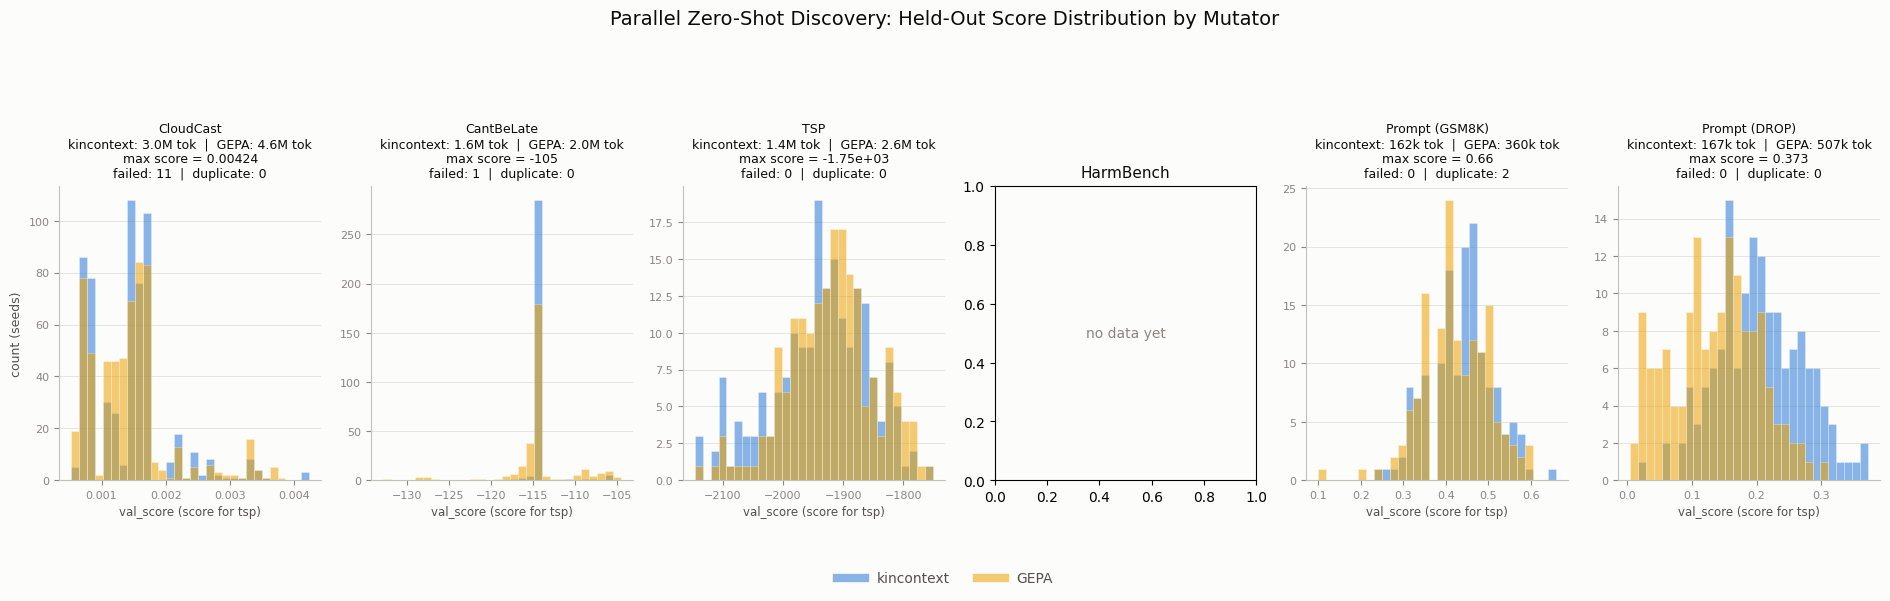

In [30]:
"""Build the 1x6 figure: parallel_zeroshot's held-out score distribution,
one histogram per task, hued by mutator (kincontext vs GEPA -- see loader
cell above). Each panel's title prints its per-mutator total tokens spent,
the max score achieved across both mutators, and (summed across both
mutators) how many of that column's generated candidates failed / were
duplicates -- see pz_summary_df above for the per-mutator breakdown."""

PZ_HIST_BINS = 30

fig, axes = plt.subplots(
    1, 6, figsize=(19, 4.6), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)

    per_mutator = pz_vals_by_column.get(column_key, {})
    if not per_mutator:
        ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=11)
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    all_vals = [v for vals in per_mutator.values() for v in vals]
    max_score = max(all_vals)
    lo, hi = min(all_vals), max(all_vals)
    bin_edges = np.linspace(lo, hi, PZ_HIST_BINS + 1) if lo < hi else PZ_HIST_BINS

    for mutator in PZ_MUTATORS:
        vals = per_mutator.get(mutator)
        if not vals:
            continue
        ax.hist(
            vals, bins=bin_edges, color=MUTATOR_COLOR[mutator], alpha=0.55,
            label=mutator, edgecolor=SURFACE, linewidth=0.4,
        )

    token_line = '  |  '.join(
        f'{mutator}: {tokens_fmt(pz_tokens_by_column[column_key][mutator])} tok'
        for mutator in PZ_MUTATORS
        if mutator in pz_tokens_by_column[column_key]
    )
    col_summary = pz_summary_df[pz_summary_df['column'] == column_key]
    n_failed_total = int(col_summary['n_failed'].sum())
    n_duplicate_total = int(col_summary['n_duplicate'].sum())
    ax.set_title(
        f'{COLUMN_TITLES[column_key]}\n{token_line}\n'
        f'max score = {max_score:.3g}\n'
        f'failed: {n_failed_total}  |  duplicate: {n_duplicate_total}',
        color=INK_PRIMARY, fontsize=9,
    )

    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6, axis='y')
    ax.set_axisbelow(True)
    ax.set_xlabel('val_score (score for tsp)', color=INK_SECONDARY, fontsize=8.5)

axes[0].set_ylabel('count (seeds)', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=MUTATOR_COLOR[m], lw=6, alpha=0.55, label=m)
    for m in PZ_MUTATORS
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=2,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.14),
)

fig.suptitle(
    'Parallel Zero-Shot Discovery: Held-Out Score Distribution by Mutator',
    color=INK_PRIMARY, fontsize=14, y=1.14,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'parallel_zeroshot_score_histograms.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "parallel_zeroshot_score_histograms.pdf")}')

plt.show()

## Parallel zero-shot: max score at several token budgets (seed order)

Companion to the single-point overlay drawn on the score-vs-tokens figures
above (`draw_pz_overlay` -- one star per mutator, at that mutator's *total*
token spend across all its parallel_zeroshot seeds). This section instead
asks "how does the best score seen so far grow as more of the (already-run)
parallel seeds are counted in, up to a fixed token budget" -- several
checkpoints per column instead of one endpoint.

**Ordering**: seeds are added in **seed-index order** (parsed from each
dirname -- the token immediately preceding `_{task}_`; confirmed against
disk to sit in the same position for cloudcast/cantbelate/prompt), not
alphabetical `os.listdir` order (which sorts `"10"` before `"100"`..`"109"`
before `"11"`) and not sorted-by-own-token-cost order. Cumulative tokens =
running sum of each included seed's own `cumulative_tokens_spent`; score at
a checkpoint = max raw `score` (FAILED_SCORE_SENTINEL excluded, same
convention as `pz_score_field_max` above) among seeds included so far.

**Budgets checked** (confirmed with the user):

- CloudCast, CantBeLate: 100k, 200k, 500k, 1M, 1.25M, 1.5M
- Prompt (GSM8K and DROP): 25k, 50k, 75k, 100k, 125k, 150k

**TSP included** as of this revision -- its parallel-zeroshot
token-computation bug is fixed (per the user), though the underlying
`parallel_zeroshot/` TSP experiment may still be catching up to the other
tasks' seed counts when this notebook is re-run. **HarmBench excluded**
(out of scope for this comparison, per the user).

**Line/star convention** (revised -- confirmed with the user): each
mutator is a thin step line at its seeds' own real cumulative-token
positions (not snapped to the checkpoint grid), extended flat past its
actual last seed out to the panel's largest checkpoint budget -- that flat
segment itself is the "ran out of seeds" cue now. A star marks only a
genuine score increase (a new best found), not every fixed budget
checkpoint -- see `plot_pz_curve`/`pz_increase_mask` below.


In [31]:
"""Loader for the multi-budget parallel zero-shot figure below.

Re-scans PARALLEL_ZEROSHOT_DIR independently of pz_generated_by_column
(loader cell near the top of the notebook) rather than reusing/mutating
it, so that cell's existing consumers (draw_pz_overlay, the histogram
section) are left completely untouched -- this cell only *adds* a new,
separate structure alongside it.
"""

MULTI_BUDGET_COLUMNS = [
    'cloudcast', 'cantbelate', 'tsp', 'prompt_gsm8k', 'prompt_drop',
]
# Dense grids (confirmed with the user): cloudcast/cantbelate every 100k
# tokens up to the original 1.5M ceiling; prompt (gsm8k/drop) every 10k
# tokens up to the original 150k ceiling -- same endpoints as the first cut
# of this figure, just filled in. TSP every 100k up to 3M -- covers both
# mutators' actual total spend on disk (kincontext ~1.47M, GEPA ~2.82M
# summed across 200 seeds each, verified against parallel_zeroshot/tsp),
# now that TSP's token-computation bug is fixed (per the user) and it's
# no longer excluded below.
_CLOUDCAST_CANTBELATE_BUDGETS = list(range(100_000, 1_500_000 + 1, 100_000))
_PROMPT_BUDGETS = list(range(10_000, 150_000 + 1, 10_000))
_TSP_BUDGETS = list(range(100_000, 3_000_000 + 1, 100_000))
MULTI_BUDGETS = {
    'cloudcast': _CLOUDCAST_CANTBELATE_BUDGETS,
    'cantbelate': _CLOUDCAST_CANTBELATE_BUDGETS,
    'tsp': _TSP_BUDGETS,
    'prompt_gsm8k': _PROMPT_BUDGETS,
    'prompt_drop': _PROMPT_BUDGETS,
}


def pz_seed(dirname: str, task_name: str) -> int:
    """Seed index parsed from a parallel_zeroshot dirname: the token
    immediately preceding `_{task_name}_` (verified against disk -- same
    position for cloudcast/cantbelate/prompt/tsp dirnames)."""
    marker = f'_{task_name}_'
    idx = dirname.index(marker)
    return int(dirname[:idx].rsplit('_', 1)[-1])


# {column: {mutator: [(seed, cumulative_tokens_spent, score), ...]}}, one
# entry per seed, NOT yet sorted (sorted by seed just below).
pz_seed_ordered_by_column: dict[str, dict[str, list[tuple[int, float, float]]]] = {}

for dirname in sorted(os.listdir(PARALLEL_ZEROSHOT_DIR)):
    run_dir = os.path.join(PARALLEL_ZEROSHOT_DIR, dirname)
    if not os.path.isdir(run_dir) or not dirname.startswith('opro_'):
        continue
    task_name, column_key, mutator = parse_pz_run_dir(dirname)
    if column_key not in MULTI_BUDGET_COLUMNS or mutator not in PZ_MUTATORS:
        continue

    bank_path = find_bank_path(run_dir)
    if bank_path is None:
        continue
    records = load_bank(bank_path)
    records = filter_tsp_records(dirname, task_name, records)  # no-op except tsp
    generated = [r for r in records if r['cumulative_tokens_spent'] > 0]
    if not generated:
        continue

    seed = pz_seed(dirname, task_name)
    record = generated[-1]
    pz_seed_ordered_by_column.setdefault(column_key, {}).setdefault(mutator, []).append(
        (seed, record['cumulative_tokens_spent'], record['score']),
    )

# Sort by seed index, then fold into running cumulative-tokens /
# running-max-score arrays per (column, mutator) -- same running-max idea
# as `running_max` above, just keyed by seed order instead of eval order.
pz_budget_curve_by_column: dict[str, dict[str, tuple[np.ndarray, np.ndarray]]] = {}
for column_key, per_mutator in pz_seed_ordered_by_column.items():
    for mutator, rows in per_mutator.items():
        rows = sorted(rows, key=lambda r: r[0])
        tokens = np.array([r[1] for r in rows], dtype=float)
        scores = np.array(
            [r[2] if r[2] != FAILED_SCORE_SENTINEL else np.nan for r in rows],
        )
        cum_tokens = np.cumsum(tokens)
        running_max_scores = np.full_like(scores, np.nan)
        current_max = np.nan
        for i, s in enumerate(scores):
            if not np.isnan(s):
                current_max = s if np.isnan(current_max) else max(current_max, s)
            running_max_scores[i] = current_max
        pz_budget_curve_by_column.setdefault(column_key, {})[mutator] = (
            cum_tokens, running_max_scores,
        )

print(f'{len(pz_budget_curve_by_column)} multi-budget columns loaded:')
for column_key in MULTI_BUDGET_COLUMNS:
    for mutator, (cum_tokens, _) in sorted(pz_budget_curve_by_column.get(column_key, {}).items()):
        max_budget = MULTI_BUDGETS[column_key][-1]
        note = '' if cum_tokens[-1] >= max_budget else '  (never reaches largest budget)'
        print(
            f'  {column_key:14s} {mutator:10s} {len(cum_tokens):3d} seeds, '
            f'total {tokens_fmt(cum_tokens[-1])} tok{note}',
        )


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_102_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_104_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_113_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_116_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_142_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_145_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_20_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_34_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_35_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_65_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_67_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_81_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_10_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_125_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_169_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_174_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_26_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_94_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_95_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
5 multi-budget columns loaded:
  cloudcast      GEPA       600 seeds, total 4.6M tok
  cloudcast      kincontext 592 seeds, total 3.0M tok
  cantbelate     GEPA       300 seeds, total 2.0M tok
  cantbelate     kincontext 300 seeds, total 1.6M tok
  tsp            GEPA       188 seeds, total 2.6M tok  (never reaches largest budget)
  tsp            kincontext 193 seeds, total 1.4M tok  (never reaches largest budget)
  prompt_gsm8k   GEPA       150 seeds, total 360k tok
  prompt_gsm8k   kincontext 150 seeds, total 162k tok
  prompt_drop    GEPA       150 seeds, total 507k tok
  prompt_drop    kincon

In [32]:
"""Shared helper for drawing a parallel_zeroshot multi-budget curve: a
thin step line (best-so-far, seed-index order, plotted at each seed's own
real cumulative-token x-position -- not snapped to the budget grid) with a
star only where the running max actually increases, instead of a star at
every fixed budget checkpoint (got visually noisy once the budget grids
got dense -- confirmed with the user). Used both by the standalone
multi-budget figure below and by draw_pz_curve_overlay's panel overlay
further down.
"""


def pz_increase_mask(y: np.ndarray) -> np.ndarray:
    """True at each index where `y` (already itself a running max, so
    non-decreasing wherever defined) sets a new best over its own
    previous non-NaN value -- including the very first non-NaN value,
    which counts as a "new best" over having nothing yet.
    """
    mask = np.zeros(len(y), dtype=bool)
    prev = np.nan
    for i, v in enumerate(y):
        if np.isnan(v):
            continue
        if np.isnan(prev) or v > prev:
            mask[i] = True
        prev = v
    return mask


def plot_pz_curve(
    ax: plt.Axes,
    cum_tokens: np.ndarray,
    running_max_scores: np.ndarray,
    color: str,
    sign: float = 1.0,
    extend_to: float | None = None,
    label: str | None = None,
) -> None:
    """Thin step curve (best-so-far vs. cumulative tokens, seed-index
    order) + star markers only at genuine score increases. Extends flat
    to `extend_to` (if past the curve's own last real point) so a mutator
    that ran out of seeds still visibly continues across the rest of the
    panel -- that flat segment is the "ran out of seeds" cue now, no
    filled/hollow star distinction needed for it.
    """
    y = sign * running_max_scores
    x_line, y_line = cum_tokens, y
    if extend_to is not None and extend_to > cum_tokens[-1]:
        x_line = np.append(cum_tokens, extend_to)
        y_line = np.append(y, y[-1])
    ax.plot(
        x_line, y_line, color=color, linewidth=0.8, drawstyle='steps-post',
        zorder=4, label=label,
    )
    increase = pz_increase_mask(running_max_scores)
    if increase.any():
        ax.scatter(
            cum_tokens[increase], y[increase], color=color, marker='*', s=40,
            zorder=6, edgecolors=SURFACE, linewidths=0.4,
        )


saved to ../figs/clean_visual4_parallel_zeroshot_multi_budget.pdf


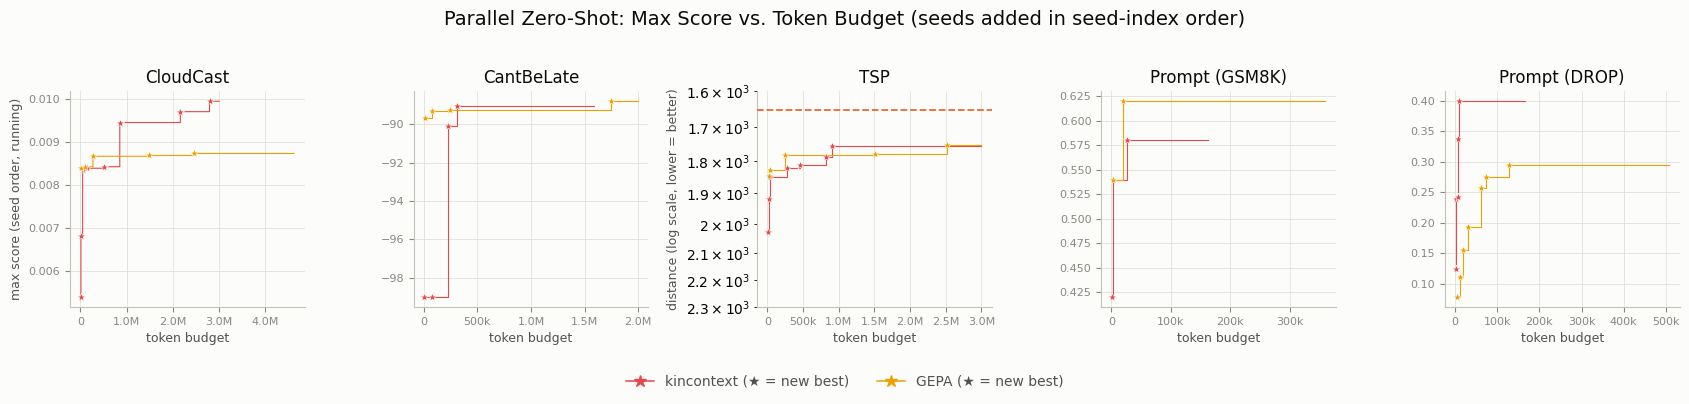

In [33]:
"""Build the 1x4 figure: parallel zero-shot max score vs. cumulative
tokens spent, seeds added in seed-index order (see loader cell above).
Uses plot_pz_curve (see helper cell above) -- a thin step line at each
seed's own real cumulative-token position, star only at genuine score
increases, extended flat out to each column's largest checkpoint budget.
New, standalone figure -- does not replace or alter the single-point
overlay already drawn on the score-vs-tokens figures (draw_pz_overlay),
which keeps using TSP's un-fixed token computation untouched, per the
user.
"""

fig, axes = plt.subplots(
    1, len(MULTI_BUDGET_COLUMNS), figsize=(3.4 * len(MULTI_BUDGET_COLUMNS), 3.4),
    facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(MULTI_BUDGET_COLUMNS):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    curves = pz_budget_curve_by_column.get(column_key, {})
    budgets = np.array(MULTI_BUDGETS[column_key], dtype=float)
    if not curves:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    # TSP's raw `score` field is already -distance (see TSP_TRUE_OPTIMUM
    # in the loader cell near the top of this notebook), so `sign` flips
    # it back to distance for display, same convention as every other
    # score-vs-tokens figure in this notebook.
    sign = -1.0 if column_key == 'tsp' else 1.0

    for mutator in PZ_MUTATORS:
        if mutator not in curves:
            continue
        cum_tokens, running_max_scores = curves[mutator]
        plot_pz_curve(
            ax, cum_tokens, running_max_scores, PZ_MUTATOR_COLOR[mutator],
            sign=sign, extend_to=budgets[-1], label=mutator,
        )

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('token budget', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)

axes[0].set_ylabel('max score (seed order, running)', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=PZ_MUTATOR_COLOR[m], lw=1.1, marker='*',
               markersize=9, label=f'{m} (★ = new best)')
    for m in PZ_MUTATORS
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=2, frameon=False,
    labelcolor=INK_SECONDARY, fontsize=10, bbox_to_anchor=(0.5, -0.12),
)

fig.suptitle(
    'Parallel Zero-Shot: Max Score vs. Token Budget (seeds added in seed-index order)',
    color=INK_PRIMARY, fontsize=14, y=1.03,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual4_parallel_zeroshot_multi_budget.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual4_parallel_zeroshot_multi_budget.pdf")}',
)

plt.show()


## Score evolution vs. tokens spent, by diversity-check variant (OPRO-only)

Same shape as the "by noise value" score visual above, but sweeping the
6-way `sim_thresh`/`llm_judge` diversity-check grid
(`DIVERSITY_CHECK_VARIANTS` in `generate_experiment_args.py`) instead of
noise, at noise=0: plain baseline (no filtering, current default), an
exact-dedup baseline, and `sim_thresh` in {0.95, 0.8} each with and
without an LLM-judge second opinion -- 6 lines per panel. Colored by
*family* (none / exact-dedup / 0.95 / 0.8, one hue each, from the dataviz
skill's categorical palette, picking slots not already used by the
mutator/reference-line colors that share this same panel) with judged
variants dashed and unjudged variants solid, so no hue has to carry all 6
distinctions on its own.

Overlaid with the **parallel zero-shot multi-budget curves** (one line per
mutator, same construction as the standalone
`clean_visual4_parallel_zeroshot_multi_budget.pdf` figure above) instead
of the noise-value figure's single-point-at-total-spend star -- "how does
sequential refinement under each diversity variant compare to breadth-only
search at every budget along the way", not just at parallel zero-shot's
own endpoint. TSP is included now that its parallel-zeroshot
token-computation bug is fixed (per the user); HarmBench stays out of
scope, same as the standalone multi-budget figure above.

**Embed-model / num_points pins** (confirmed with the user, backported to
the noise=0 and by-noise discovery cells near the top of this notebook
too): CloudCast/CantBeLate each held a full second (and, at noise=0/
sim_thresh=0, third) 12-variant sweep on disk under embed_model values
other than the current `nomic-ai/CodeRankEmbed` default (`get_embed_model`)
-- pinned to nomic-ai via `embed_model_ok`. TSP separately held a full
`num_points` in {80, 100, 200} sweep under every noise value and diversity
variant, and `num_points` isn't part of `optimizer_label` -- pinned to
`num_points=100` via `num_points_ok` (current default, and what
`TSP_TRUE_OPTIMUM` above was solved for). Both pins live in the loader
cell near the top of this notebook and are reused here.

**Cell order**: this section reuses `pz_budget_curve_by_column` /
`MULTI_BUDGETS` / `MULTI_BUDGET_COLUMNS` from the multi-budget loader cell
above, so it must run after it (it's placed after in the notebook, so a
top-to-bottom "Run All" is fine either way).


In [34]:
"""Discover OPRO run dirs across the 6 diversity-check variants (noise=0
only), grouped by column x diversity_variant x OPRO variant. Reuses
parse_run_dir / noise_token / find_bank_path / load_bank /
inference_model_ok / embed_model_ok / num_points_ok / filter_tsp_records
from the loader cell near the top of this notebook -- same
inference-model/embed-model/num_points pins (cloudcast/cantbelate pinned
to nomic-ai, TSP pinned to num_points=100), same nested-bank-path
handling, same invalid-TSP-trace filtering."""

# (sim_thresh_token, llm_judge_token) as they appear in a dirname -> fixed
# canonical order + display label, matching DIVERSITY_CHECK_VARIANTS in
# generate_experiment_args.py. sim_thresh tokens follow main.py's
# str(val).replace('.', '') CLI serialization (e.g. 0.95 -> '095',
# -1.0 -> '-10'); llm_judge is the literal model name or 'None'.
DIVERSITY_VARIANT_ORDER: list[tuple[str, str]] = [
    ('00', 'None'),               # plain baseline (current default)
    ('-10', 'None'),              # exact-dedup baseline
    ('095', 'None'),              # sim_thresh=0.95, no judge
    ('095', 'gemini-35-flash'),   # sim_thresh=0.95, judged
    ('08', 'None'),               # sim_thresh=0.8, no judge
    ('08', 'gemini-35-flash'),    # sim_thresh=0.8, judged
]
DIVERSITY_VARIANT_LABEL: dict[tuple[str, str], str] = {
    ('00', 'None'): 'plain baseline',
    ('-10', 'None'): 'exact dedup',
    ('095', 'None'): 'sim_thresh=0.95',
    ('095', 'gemini-35-flash'): 'sim_thresh=0.95 + judge',
    ('08', 'None'): 'sim_thresh=0.8',
    ('08', 'gemini-35-flash'): 'sim_thresh=0.8 + judge',
}


def diversity_tokens(dirname: str) -> tuple[str, str] | None:
    """(sim_thresh_token, llm_judge_token), or None if dirname's noise != 0.

    Dirname layout right after 'lowest_scoring_' (main.py's argparse
    definition order): noise, prune_noise, embed_model, llm_judge,
    sim_thresh, seed -- see noise_token's docstring for how noise itself
    is pinned down; sim_thresh/llm_judge are unconditionally the two
    tokens right after embed_model, since embed_model is always exactly
    one token (main.py's dirname-building strips '/' rather than
    replacing it with '_' -- verified against every embed_model on disk,
    including the two-segment 'nomic-ai/CodeRankEmbed' and
    'jina-ai/jina-embeddings-v2-base-code').
    """
    rest = dirname.split('lowest_scoring_', 1)[1]
    noise, _prune_noise, _embed_model, llm_judge, sim_thresh = rest.split('_')[:5]
    if noise != '00':
        return None
    return (sim_thresh, llm_judge)


runs_by_column_diversity: dict[
    str, dict[tuple[str, str], dict[str, list[dict]]]
] = {}

for dirname in sorted(os.listdir(EXPERIMENT_DIR)):
    run_dir = os.path.join(EXPERIMENT_DIR, dirname)
    if not os.path.isdir(run_dir) or not dirname.startswith('opro_'):
        continue
    variant = diversity_tokens(dirname)
    if variant is None or variant not in DIVERSITY_VARIANT_LABEL:
        continue
    task_name, column_key, mutator, sampling_strategy = parse_run_dir(dirname)
    if not inference_model_ok(dirname, task_name):
        continue
    if not embed_model_ok(dirname, task_name) or not num_points_ok(dirname, task_name):
        continue

    optimizer_label = f'opro_{mutator}_{sampling_strategy}'
    bank_path = find_bank_path(run_dir)
    if bank_path is None:
        continue  # job hasn't produced a bank file yet
    records = load_bank(bank_path)
    records = filter_tsp_records(dirname, task_name, records)
    if not records:
        continue

    runs_by_column_diversity.setdefault(column_key, {}).setdefault(
        variant, {},
    )[optimizer_label] = records

print(f'{len(runs_by_column_diversity)} columns loaded:')
for column_key, by_variant in sorted(runs_by_column_diversity.items()):
    coverage = ', '.join(
        f'{DIVERSITY_VARIANT_LABEL[v]}: {len(by_variant.get(v, {})):2d}/12'
        for v in DIVERSITY_VARIANT_ORDER
    )
    print(f'  {column_key:14s} {coverage}')


[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_DE_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 9 invalid-trace record(s) from opro_gemini-37-flash_DE_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_08_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_DE_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_095_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_DE_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_gemini-35-flash_095_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 5 invalid-trace record(s) from opro_gemini-37-flash_DE_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_08_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 4 invalid-trace record(s) from op

[tsp] dropped 6 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_08_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_095_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_gemini-35-flash_08_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_GA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_-10_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 7 invalid-trace record(s) from op

[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_-10_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_08_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_GEPA_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_095_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_-10_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 3 invalid-trace record(s) from opro_gemini-37-flash_GEPA_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 4 invalid-trace record(s) from opro_ge

[tsp] dropped 4 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 5 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_08_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 2 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_095_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_highest_scoring_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_gemini-35-flash_095_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] dropped 1 invalid-trace record(s) from opro_gemini-37-flash_kincontext_tournament_05_5_-1_15_lowest_scoring_00_00_all-MiniLM-L6-v2_None_00_0_tsp_googlegemma-4-E4B-it_1_1_cuda_100_3_drop
[tsp] d

6 columns loaded:
  cantbelate     plain baseline: 12/12, exact dedup: 12/12, sim_thresh=0.95: 12/12, sim_thresh=0.95 + judge: 12/12, sim_thresh=0.8: 12/12, sim_thresh=0.8 + judge: 12/12
  cloudcast      plain baseline: 12/12, exact dedup: 12/12, sim_thresh=0.95: 11/12, sim_thresh=0.95 + judge: 12/12, sim_thresh=0.8: 12/12, sim_thresh=0.8 + judge: 12/12
  harmbench      plain baseline: 12/12, exact dedup: 12/12, sim_thresh=0.95: 12/12, sim_thresh=0.95 + judge: 12/12, sim_thresh=0.8: 12/12, sim_thresh=0.8 + judge: 12/12
  prompt_drop    plain baseline: 12/12, exact dedup: 12/12, sim_thresh=0.95: 12/12, sim_thresh=0.95 + judge: 12/12, sim_thresh=0.8: 12/12, sim_thresh=0.8 + judge: 12/12
  prompt_gsm8k   plain baseline: 12/12, exact dedup: 12/12, sim_thresh=0.95: 12/12, sim_thresh=0.95 + judge: 12/12, sim_thresh=0.8: 12/12, sim_thresh=0.8 + judge: 12/12
  tsp            plain baseline: 12/12, exact dedup: 12/12, sim_thresh=0.95: 12/12, sim_thresh=0.95 + judge: 12/12, sim_thresh=0.8: 12/12

saved to ../figs/clean_visual5_row2_opro_by_diversity_variant.pdf


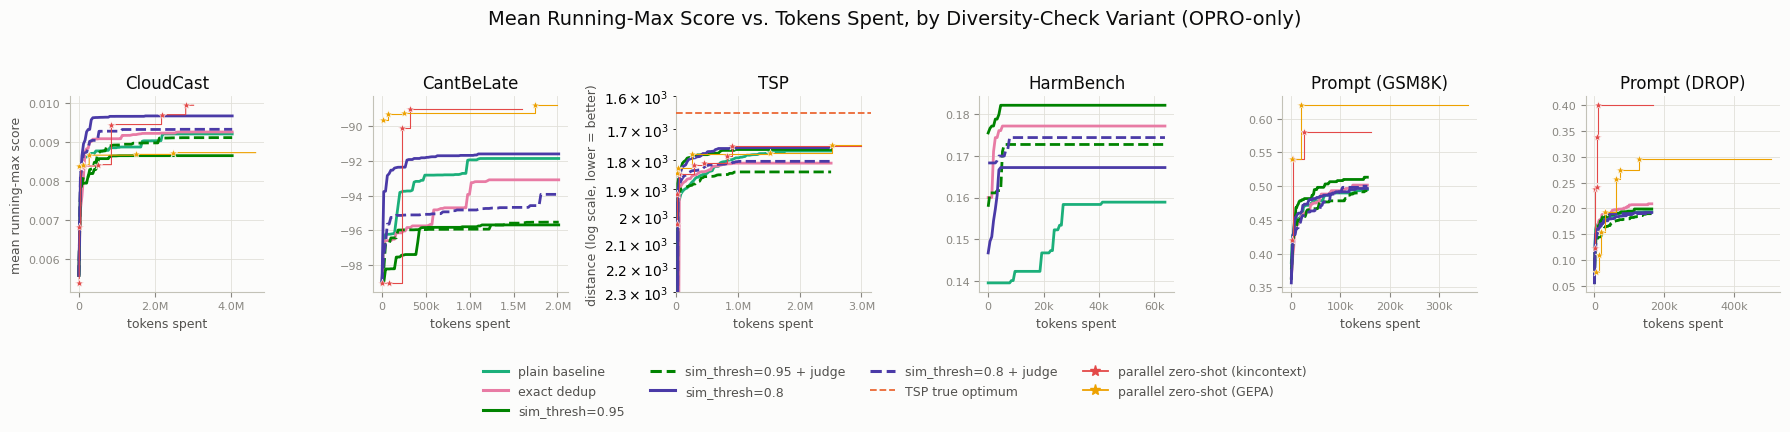

In [35]:
"""Build the 1x6 figure: mean running-max score vs. tokens spent,
OPRO-only, one mean line per diversity-check variant (colored by family,
judged variants dashed), overlaid with the parallel zero-shot multi-budget
curves (see markdown cell above). Reuses pz_budget_curve_by_column /
MULTI_BUDGETS / MULTI_BUDGET_COLUMNS / PZ_MUTATORS / PZ_MUTATOR_COLOR from
the multi-budget section above -- must run after it."""

DIVERSITY_FAMILY_COLOR = {
    'plain': '#1baf7a',       # aqua
    'exact_dedup': '#e87ba4', # magenta
    'sim_095': '#008300',     # green
    'sim_08': '#4a3aa7',      # violet
}
DIVERSITY_VARIANT_STYLE: dict[tuple[str, str], tuple[str, str]] = {
    ('00', 'None'): ('plain', '-'),
    ('-10', 'None'): ('exact_dedup', '-'),
    ('095', 'None'): ('sim_095', '-'),
    ('095', 'gemini-35-flash'): ('sim_095', '--'),
    ('08', 'None'): ('sim_08', '-'),
    ('08', 'gemini-35-flash'): ('sim_08', '--'),
}


def draw_pz_curve_overlay(ax: plt.Axes, column_key: str, sign: float = 1.0) -> None:
    """Overlay parallel_zeroshot's multi-budget curve (one thin step line
    per mutator, star only at genuine score increases -- see plot_pz_curve
    in the multi-budget section above) on an already-drawn
    running-max-score panel -- exactly
    clean_visual4_parallel_zeroshot_multi_budget.pdf's own per-mutator
    curve, plotted onto this panel's own axes instead of a standalone one.
    No-op for a column outside MULTI_BUDGET_COLUMNS (HarmBench)."""
    curves = pz_budget_curve_by_column.get(column_key)
    if not curves:
        return
    extend_to = max(MULTI_BUDGETS[column_key])
    for mutator in PZ_MUTATORS:
        if mutator not in curves:
            continue
        cum_tokens, running_max_scores = curves[mutator]
        plot_pz_curve(
            ax, cum_tokens, running_max_scores, PZ_MUTATOR_COLOR[mutator],
            sign=sign, extend_to=extend_to,
        )


fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    by_variant = runs_by_column_diversity.get(column_key, {})
    if not by_variant:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    # Same "extend to the furthest-along point, not the shortest" grid
    # convention as every other running-max figure in this notebook.
    grid_end = max(
        r['cumulative_tokens_spent']
        for variants in by_variant.values()
        for records in variants.values()
        for r in records
    )
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    sign = -1.0 if column_key == 'tsp' else 1.0

    for variant in DIVERSITY_VARIANT_ORDER:
        variants = by_variant.get(variant)
        if not variants:
            continue
        interpolated = []
        for records in variants.values():
            tokens = np.array(
                [r['cumulative_tokens_spent'] for r in records], dtype=float,
            )
            cummax = running_max(
                np.array([r['score'] for r in records], dtype=float),
            )
            interpolated.append(step_interpolate(tokens, cummax, grid))
        mean_series = np.nanmean(np.vstack(interpolated), axis=0)
        family, linestyle = DIVERSITY_VARIANT_STYLE[variant]
        ax.plot(
            grid, sign * mean_series, color=DIVERSITY_FAMILY_COLOR[family],
            linestyle=linestyle, linewidth=2.0, zorder=3,
        )

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    draw_pz_curve_overlay(ax, column_key, sign=sign)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key in ZOOM_XLIM:
        # See the matching widening in the noise=0/by-noise score figures
        # above -- TSP's parallel_zeroshot curve budgets run well past the
        # hand-zoomed window.
        x_lo, x_hi = ZOOM_XLIM[column_key]
        curve_budget_max = max(MULTI_BUDGETS.get(column_key, [0]))
        x_hi = max(x_hi, curve_budget_max * 1.05)
        ax.set_xlim(x_lo, x_hi)

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D(
        [0], [0], color=DIVERSITY_FAMILY_COLOR[DIVERSITY_VARIANT_STYLE[v][0]],
        linestyle=DIVERSITY_VARIANT_STYLE[v][1], lw=2.2,
        label=DIVERSITY_VARIANT_LABEL[v],
    )
    for v in DIVERSITY_VARIANT_ORDER
] + [
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
] + [
    plt.Line2D(
        [0], [0], color=PZ_MUTATOR_COLOR[m], lw=1.3, marker='*', markersize=8,
        label=f'parallel zero-shot ({m})',
    )
    for m in PZ_MUTATORS
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=9,
    bbox_to_anchor=(0.5, -0.26),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent, by Diversity-Check Variant (OPRO-only)',
    color=INK_PRIMARY, fontsize=14, y=1.05,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual5_row2_opro_by_diversity_variant.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual5_row2_opro_by_diversity_variant.pdf")}',
)

plt.show()


## Score evolution vs. tokens spent, with parallel zero-shot curve overlay (OPRO-only, plain baseline)

Companion to `clean_visual1_row2_opro_only.pdf` above -- identical 12
faint per-variant lines + bold mean line, plain diversity-check baseline
(sim_thresh=0, noise=0), but with parallel zero-shot's **multi-budget
curve** overlay (`draw_pz_curve_overlay`, same construction as
`clean_visual5_row2_opro_by_diversity_variant.pdf`'s overlay) in place of
that figure's single-point-at-total-spend star (`draw_pz_overlay`) -- the
curve shows how the comparison holds at every budget checkpoint along the
way, not just at parallel zero-shot's own endpoint. Saved as a separate
file so the original star-overlay figure is untouched.

**Cell order**: reuses `draw_pz_curve_overlay` / `pz_budget_curve_by_column`
/ `MULTI_BUDGETS` from the multi-budget section above, so it must run
after it (placed after in the notebook, so a top-to-bottom "Run All" is
fine either way).


saved to ../figs/clean_visual1_row2_opro_only_with_pz_curves.pdf


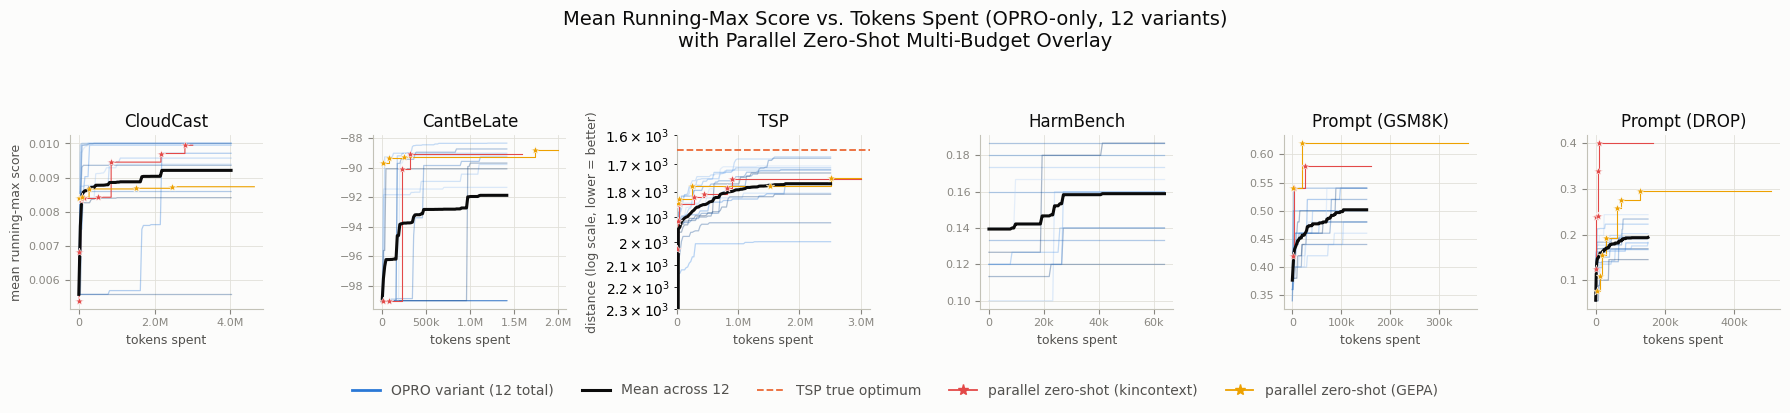

In [36]:
"""Companion to the noise=0 score figure above (clean_visual1_row2_opro_only),
with the parallel zero-shot multi-budget CURVE overlay (draw_pz_curve_overlay)
in place of that figure's single-point star (draw_pz_overlay). Identical
plotting logic to that cell otherwise -- same 12 per-variant lines + bold
mean line, same TSP log/inverted axis treatment. Saved as a SEPARATE file
so the original star-overlay figure is untouched.
"""

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.2), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)

    variants = runs_by_column.get(column_key, {})
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)
    if not variants:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    trajectories = {
        label: (
            np.array([r['cumulative_tokens_spent'] for r in records], dtype=float),
            running_max(np.array([r['score'] for r in records], dtype=float)),
        )
        for label, records in variants.items()
    }

    grid_end = max(tokens.max() for tokens, _ in trajectories.values())
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    sign = -1.0 if column_key == 'tsp' else 1.0

    interpolated = []
    for label, (tokens, cummax) in trajectories.items():
        resampled = step_interpolate(tokens, cummax, grid)
        interpolated.append(resampled)
        ax.plot(
            grid, sign * resampled, color=color_for(label), linewidth=0.9,
            alpha=0.35, zorder=2,
        )

    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, sign * mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    if column_key == 'tsp':
        ax.axhline(
            sign * TSP_TRUE_OPTIMUM, color=REFERENCE_LINE_COLOR, linewidth=1.3,
            linestyle='--', zorder=4,
        )
        tsp_style(ax)
        ax.set_ylabel(TSP_YLABEL, color=INK_SECONDARY, fontsize=9)

    draw_pz_curve_overlay(ax, column_key, sign=sign)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)
    if column_key in ZOOM_XLIM:
        # See the matching widening on the other score figures above --
        # TSP's parallel_zeroshot curve budgets run well past the
        # hand-zoomed window.
        x_lo, x_hi = ZOOM_XLIM[column_key]
        curve_budget_max = max(MULTI_BUDGETS.get(column_key, [0]))
        x_hi = max(x_hi, curve_budget_max * 1.05)
        ax.set_xlim(x_lo, x_hi)

axes[0].set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO variant (12 total)'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across 12'),
    plt.Line2D(
        [0], [0], color=REFERENCE_LINE_COLOR, lw=1.3, linestyle='--',
        label='TSP true optimum',
    ),
] + [
    plt.Line2D(
        [0], [0], color=PZ_MUTATOR_COLOR[m], lw=1.3, marker='*', markersize=8,
        label=f'parallel zero-shot ({m})',
    )
    for m in PZ_MUTATORS
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=5,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.15),
)

fig.suptitle(
    'Mean Running-Max Score vs. Tokens Spent (OPRO-only, 12 variants)\n'
    'with Parallel Zero-Shot Multi-Budget Overlay',
    color=INK_PRIMARY, fontsize=14, y=1.1,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual1_row2_opro_only_with_pz_curves.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual1_row2_opro_only_with_pz_curves.pdf")}',
)

plt.show()


## Score at a shared token budget, by diversity-check variant (bar chart)

Bar-chart variant of `clean_visual5_row2_opro_by_diversity_variant.pdf`
above: instead of a full running-max-vs-tokens trajectory per diversity
variant, one **bar** per variant at a single shared token budget per
column -- `grid_end`, the same "furthest-along variant" budget that
figure's x-axis runs out to. Bar height = that variant's mean
running-max score at `grid_end` (`step_interpolate`'s forward-filled
value, so a variant that hasn't caught up to `grid_end` yet still reports
its current best-so-far, not a fabricated lower number). Colored by the
same family hues as the line-plot version; judged variants hatched
instead of dashed (a bar has no line style).

**TSP is plotted as excess distance over the true optimum**
(`score - TSP_TRUE_OPTIMUM`, zero-based) rather than raw distance -- a
plain zero-baseline bar of raw distance (~1600-2300) would dwarf the
actual spread between variants (tens of units) under a shared baseline.
Zero-basing against the known optimum keeps the bar chart's zero-baseline
honest (never truncate a bar axis) while keeping the comparison legible;
every other column keeps raw `sign * score`.

**Parallel zero-shot** is drawn as a horizontal dashed reference line per
mutator (its own best score at this same shared budget, from
`pz_budget_curve_by_column`) rather than a 7th/8th bar -- it isn't one of
the 6 diversity variants being compared, and a threshold line reads more
honestly than folding it into the same bar group.


saved to ../figs/clean_visual5b_diversity_variant_barplot.pdf


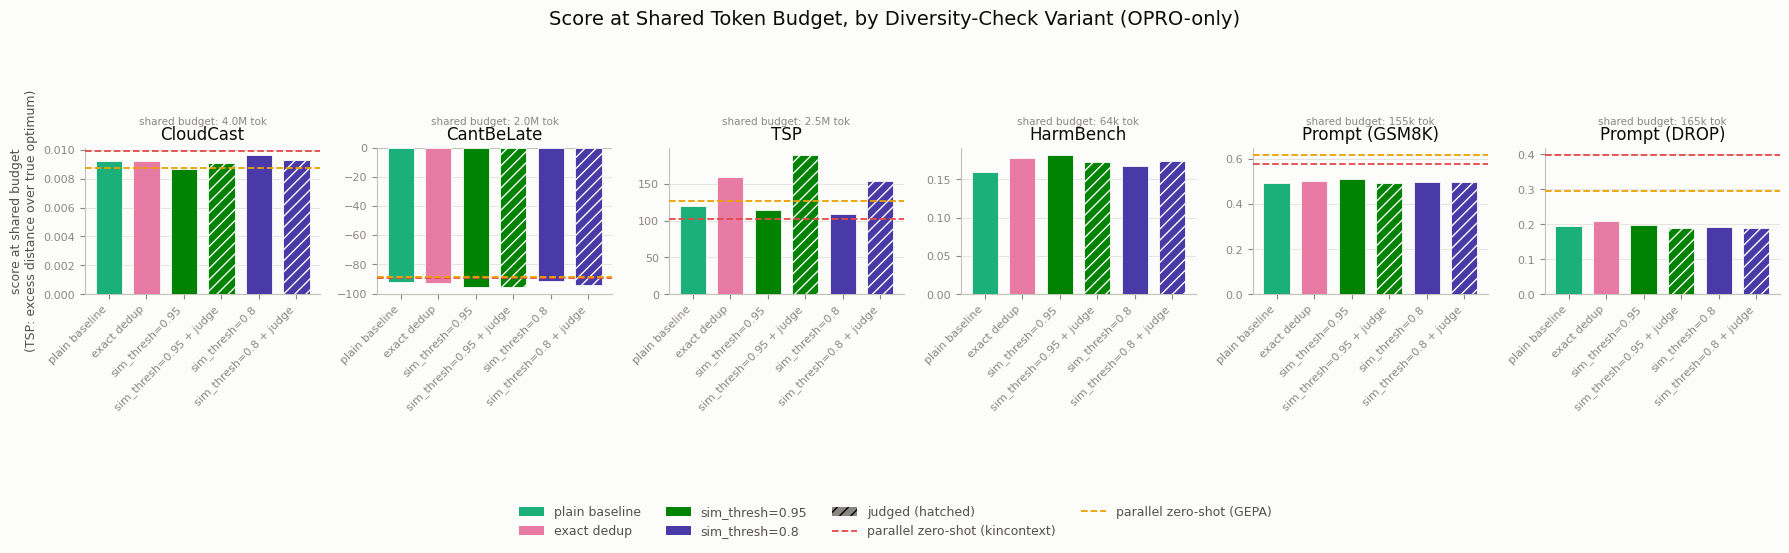

In [37]:
"""Build the 1x6 figure: bar chart of mean running-max score at a shared
token budget (grid_end), one bar per diversity-check variant, parallel
zero-shot drawn as horizontal reference lines instead of bars (see
markdown cell above)."""

fig, axes = plt.subplots(
    1, 6, figsize=(18, 3.8), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    ax = axes[col_idx]
    ax.set_facecolor(SURFACE)
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    by_variant = runs_by_column_diversity.get(column_key, {})
    if not by_variant:
        ax.text(
            0.5, 0.5, 'no data yet', ha='center', va='center',
            color=INK_MUTED, fontsize=10, transform=ax.transAxes,
        )
        continue

    grid_end = max(
        r['cumulative_tokens_spent']
        for variants in by_variant.values()
        for records in variants.values()
        for r in records
    )
    sign = -1.0 if column_key == 'tsp' else 1.0
    # TSP only: zero-base against the true optimum instead of plotting raw
    # distance from a zero baseline (see markdown cell above).
    baseline_offset = sign * TSP_TRUE_OPTIMUM if column_key == 'tsp' else 0.0

    bar_labels, bar_heights, bar_colors, bar_hatches = [], [], [], []
    for variant in DIVERSITY_VARIANT_ORDER:
        variants = by_variant.get(variant)
        if not variants:
            continue
        per_label_scores = []
        for records in variants.values():
            tokens = np.array(
                [r['cumulative_tokens_spent'] for r in records], dtype=float,
            )
            cummax = running_max(
                np.array([r['score'] for r in records], dtype=float),
            )
            per_label_scores.append(
                step_interpolate(tokens, cummax, np.array([grid_end]))[0],
            )
        mean_score = np.nanmean(per_label_scores)
        family, linestyle = DIVERSITY_VARIANT_STYLE[variant]
        bar_labels.append(DIVERSITY_VARIANT_LABEL[variant])
        bar_heights.append(sign * mean_score - baseline_offset)
        bar_colors.append(DIVERSITY_FAMILY_COLOR[family])
        bar_hatches.append('///' if linestyle == '--' else None)

    x = np.arange(len(bar_labels))
    for xi, height, color, hatch in zip(
        x, bar_heights, bar_colors, bar_hatches, strict=True,
    ):
        ax.bar(
            xi, height, color=color, hatch=hatch, edgecolor=SURFACE,
            linewidth=0.6, width=0.7, zorder=3,
        )

    # Parallel zero-shot reference lines -- same shared budget (grid_end),
    # forward-filled past a mutator's own last eval, same convention as
    # every curve overlay in this notebook.
    curves = pz_budget_curve_by_column.get(column_key, {})
    for mutator in PZ_MUTATORS:
        if mutator not in curves:
            continue
        cum_tokens, running_max_scores = curves[mutator]
        y = (
            sign * step_interpolate(
                cum_tokens, running_max_scores, np.array([grid_end]),
            )[0]
            - baseline_offset
        )
        ax.axhline(
            y, color=PZ_MUTATOR_COLOR[mutator], linewidth=1.3, linestyle='--',
            zorder=5,
        )

    ax.axhline(0, color=BASELINE, linewidth=0.8, zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=7)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6, axis='y')
    ax.set_axisbelow(True)

    ax.text(
        0.5, 1.14, f'shared budget: {tokens_fmt(grid_end)} tok',
        ha='center', va='bottom', fontsize=7.5, color=INK_MUTED,
        transform=ax.transAxes,
    )

axes[0].set_ylabel(
    'score at shared budget\n(TSP: excess distance over true optimum)',
    color=INK_SECONDARY, fontsize=9,
)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=DIVERSITY_FAMILY_COLOR[fam], label=label)
    for fam, label in [
        ('plain', 'plain baseline'), ('exact_dedup', 'exact dedup'),
        ('sim_095', 'sim_thresh=0.95'), ('sim_08', 'sim_thresh=0.8'),
    ]
] + [
    plt.Rectangle(
        (0, 0), 1, 1, facecolor=INK_MUTED, hatch='///', label='judged (hatched)',
    ),
] + [
    plt.Line2D(
        [0], [0], color=PZ_MUTATOR_COLOR[m], lw=1.3, linestyle='--',
        label=f'parallel zero-shot ({m})',
    )
    for m in PZ_MUTATORS
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=9,
    bbox_to_anchor=(0.5, -0.32),
)

fig.suptitle(
    'Score at Shared Token Budget, by Diversity-Check Variant (OPRO-only)',
    color=INK_PRIMARY, fontsize=14, y=1.1,
)
fig.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual5b_diversity_variant_barplot.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual5b_diversity_variant_barplot.pdf")}',
)

plt.show()


## Population initialization vs rollout compute trade-off (OPRO-only, plain baseline)

Modeled on the user's proof-of-concept reference figure / `general_rollout.ipynb`'s
"Fig B" (`figB_compute_ratio_bars.pdf`), extended from that figure's 1x2
(CantBeLate/CloudCast only, one strategy) to the full **4 strategies x 6
tasks** grid.

**Strategies** (confirmed with the user, traced from
`generate_experiment_args.py`'s `get_args_for_pop_dynamics` +
`population_dynamics_launch_exps.sh`'s currently-active `POP_DIR` ->
`currated_initial_populations_baselines/`): `population_curation_utils.
curate_population`'s 3 `curation_type` values, plus one extra
`population_size` variant --
- `greedy` -- top-N candidates by score, `dedup='max'`, no diversity filtering.
- `greedy_n1` -- same top-score selection, but `population_size=1` (a
  single-solution seed).
- `greedy_no_dedup` -- top-N by score, `dedup='none'` (a repeated high
  scorer can crowd out the pool -- a worst-case baseline, not a
  recommended policy).
- `diversity` -- diversity-rejection sampling (cosine-similarity
  percentile threshold, greedy backfill for under-filled pools).

`tournament` is also supported by `curate_population` but was never
launched under `currated_initial_populations_baselines/` -- confirmed
absent from every task's file listing there -- so it isn't one of the 4.

**Baseline**: the "no init" bar in every panel reuses `runs_by_column`
(the plain-baseline, noise=0/sim_thresh=0/no-judge OPRO trajectories
already loaded near the top of this notebook), per the user -- not the
diversity-check sweep (a different "diversity" axis entirely from the
`diversity` curation strategy above).

**Bars**: one 'no init' bin (ratio 0) plus one bin per seed-population
budget that has continuation data, following Fig B's construction (mean,
across every matched continuation trajectory's own running-max score
capped at that task's own `TASK_TOKEN_BUDGETS` token cap, of `x` = the
bin's `cost_tokens / (cap - cost_tokens)` ratio). Per-bar annotation is
the reference image's simpler single-line style (`max=<seed pool's own
best score>, r=<ratio>, n=<matched trajectories>`), not
`general_rollout.ipynb`'s later, more elaborate 4-line version.

**TSP**: bars plotted as excess distance over the true optimum (same
zero-baseline convention as `clean_visual5b_diversity_variant_barplot.pdf`
above) rather than raw score, for the same reason -- a raw-distance
zero-baseline bar would dwarf the real spread between bars.


In [38]:
"""Population-initialization experiment: seed-population + continuation-run
loader for the 4-strategy x 6-task bar-chart grid below (see markdown cell
above for the strategies/directory-layout background).

get_args_for_pop_dynamics never sweeps sim_thresh/llm_judge/embed_model/
num_points (main.py's stock defaults apply unconditionally to every
population_dynamics run, unlike general_rollout/'s OPRO sweep), so there
is no cross-variant collision risk on those axes the way general_rollout/
has -- the pins below (embed_model_ok/num_points_ok/sim_thresh_ok/
optimizer_llm_ok, reused from the loader cell near the top of this
notebook) are applied anyway, defensively, in case an older code era's
defaults ever differed.
"""

POP_DYNAMICS_DIR = '../population_dynamics'
CURATED_BASELINES_DIR = '../currated_initial_populations_baselines'

INIT_STRATEGY_ORDER = ['greedy', 'greedy_n1', 'greedy_no_dedup', 'diversity']
INIT_STRATEGY_TITLES = {
    'greedy': 'Greedy (top-N by score)',
    'greedy_n1': 'Greedy (n=1 seed)',
    'greedy_no_dedup': 'Greedy (no dedup)',
    'diversity': 'Diversity-rejection',
}
INIT_STRATEGY_COLOR = {
    'greedy': '#4a3aa7',           # violet
    'greedy_n1': '#e87ba4',        # magenta
    'greedy_no_dedup': '#008300',  # green
    'diversity': '#c9962f',        # mustard -- matches general_rollout.ipynb's
                                    # COLOR_REJECTION_POP for this same concept
}
COLOR_NOINIT = INK_MUTED

# Per-task token cap (confirmed with the user): TASK_TOKEN_BUDGETS from
# generate_experiment_args.py, duplicated here since this notebook doesn't
# import that module -- the same cumulative-token budget general_rollout's
# own OPRO runs are capped at.
POP_INIT_TOKEN_CAP: dict[str, int] = {
    'cloudcast': 4_000_000,
    'cantbelate': 2_000_000,
    'tsp': 1_000_000,
    'harmbench': 70_000,
    'prompt_gsm8k': 150_000,
    'prompt_drop': 150_000,
}


def pop_dynamics_config_ok(dirname: str, task_token: str) -> bool:
    """Cross-variant pins from general_rollout/'s loader cell, reused
    defensively (see cell docstring above) -- EXCEPT embed_model_ok:
    get_args_for_pop_dynamics never calls get_embed_model, so every
    population_dynamics run (cloudcast/cantbelate included) uses main.py's
    stock 'all-MiniLM-L6-v2' default, not general_rollout/'s per-task
    nomic-ai pin -- applying that pin here rejected every real match
    (verified against disk: 0/12 cloudcast/cantbelate/harmbench matches
    passed with it, 12/12 without)."""
    return (
        noise_token(dirname) == '00'
        and inference_model_ok(dirname, task_token)
        and num_points_ok(dirname, task_token)
        and sim_thresh_ok(dirname, task_token)
        and optimizer_llm_ok(dirname, task_token)
    )


def load_pop_dynamics_trajectory(
    bank_path: str, num_seeds: int, cost_offset: float,
) -> dict[str, np.ndarray] | None:
    """Continuation trajectory (absolute tokens, running-max score) for the
    post-seed portion of one variant run. None if it hasn't produced any
    new (post-seed) solutions yet. Same mechanics as general_rollout.ipynb's
    helper of the same name -- seeds carry no cumulative_tokens_spent of
    their own (see opro.py's SolutionBank), so own_tokens correctly starts
    the running total at 0 for them; cost_offset (the seed pool's own
    build cost) is added back in explicitly."""
    if not os.path.exists(bank_path):
        return None
    records = load_bank(bank_path)
    if len(records) <= num_seeds:
        return None
    own_tokens = np.array(
        [r.get('cumulative_tokens_spent') or 0 for r in records], dtype=float,
    )
    scores = np.array([r['score'] for r in records], dtype=float)
    cummax = running_max(scores)  # over the FULL bank (seeds included)
    return {
        'tokens': cost_offset + own_tokens[num_seeds:],
        'scores': cummax[num_seeds:],
    }


def capped_running_max(
    tokens: np.ndarray, scores: np.ndarray, cap: float,
) -> float | None:
    """Running-max score as of the last eval at/before `cap` tokens, or
    None if this trajectory has no eval within budget at all."""
    within = tokens <= cap
    if not within.any():
        return None
    return running_max(scores)[within][-1]


def sem(values: list[float]) -> float:
    """Standard error of the mean -- 0 for a single-trajectory bin."""
    if len(values) < 2:
        return 0.0
    return float(np.std(values, ddof=1) / np.sqrt(len(values)))


# {column_key: {strategy: [{'budget', 'cost_tokens', 'num_seeds',
# 'max_score', 'values'}, ...]}} -- 'values' is one capped running-max
# score per matched continuation variant (<=12 canonical OPRO variants).
pop_init_bins: dict[str, dict[str, list[dict]]] = {}

for column_key in COLUMN_ORDER:
    task_dir = os.path.join(CURATED_BASELINES_DIR, column_key)
    if not os.path.isdir(task_dir):
        continue
    cap = POP_INIT_TOKEN_CAP[column_key]
    task_token = column_key.split('_')[0]  # 'prompt_drop' -> 'prompt', else unchanged

    for strategy in INIT_STRATEGY_ORDER:
        prefix = f'{strategy}_budget_'
        pop_files = sorted(
            f for f in os.listdir(task_dir)
            if f.startswith(prefix) and f.endswith('.json')
        )
        for fname in pop_files:
            budget = int(fname[len(prefix):-len('.json')])
            # Population files are saved in the same {iter_key: entry}
            # dict shape as a solution bank (save_population_json), not a
            # plain list -- load_bank already handles that (sorted by int
            # key) -- confirmed against disk after a first pass here
            # naively json.load()'d these as a list and KeyError'd on
            # population[-1].
            records = load_bank(os.path.join(task_dir, fname))
            if not records:
                continue
            num_seeds = len(records)
            cost_tokens = records[-1].get('cumulative_tokens_spent') or 0
            max_score = max(r['score'] for r in records)
            if cost_tokens >= cap:
                # No rollout budget left after building this seed pool --
                # ratio/comparison against the no-init bar is meaningless.
                print(
                    f'[{column_key}/{strategy}] skipping budget={budget}: '
                    f'seed cost {tokens_fmt(cost_tokens)} >= cap {tokens_fmt(cap)}',
                )
                continue

            variant_glob = os.path.join(
                POP_DYNAMICS_DIR, '*', 'currated_initial_populations_baselines',
                column_key, f'{strategy}_budget_{budget}',
                'long_running_solution_bank.json',
            )
            label_to_value: dict[str, float] = {}
            for bank_path in sorted(glob.glob(variant_glob)):
                config_dir = os.path.basename(
                    bank_path.split('/currated_initial_populations_baselines/')[0],
                )
                if not config_dir.startswith('opro_'):
                    continue
                if not pop_dynamics_config_ok(config_dir, task_token):
                    continue
                _tn, _ck, mutator, sampling_strategy = parse_run_dir(config_dir)
                optimizer_label = f'opro_{mutator}_{sampling_strategy}'
                traj = load_pop_dynamics_trajectory(bank_path, num_seeds, cost_tokens)
                if traj is None:
                    continue
                v = capped_running_max(traj['tokens'], traj['scores'], cap)
                if v is not None:
                    label_to_value[optimizer_label] = v

            if not label_to_value:
                continue
            pop_init_bins.setdefault(column_key, {}).setdefault(strategy, []).append({
                'budget': budget,
                'cost_tokens': cost_tokens,
                'num_seeds': num_seeds,
                'max_score': max_score,
                'values': list(label_to_value.values()),
            })

print(f'{len(pop_init_bins)} columns loaded:')
for column_key in COLUMN_ORDER:
    by_strategy = pop_init_bins.get(column_key, {})
    coverage = ', '.join(
        f'{s}: {len(by_strategy.get(s, []))} budget(s)' for s in INIT_STRATEGY_ORDER
    )
    print(f'  {column_key:14s} {coverage}')


5 columns loaded:
  cloudcast      greedy: 4 budget(s), greedy_n1: 4 budget(s), greedy_no_dedup: 4 budget(s), diversity: 4 budget(s)
  cantbelate     greedy: 4 budget(s), greedy_n1: 4 budget(s), greedy_no_dedup: 4 budget(s), diversity: 4 budget(s)
  tsp            greedy: 3 budget(s), greedy_n1: 3 budget(s), greedy_no_dedup: 3 budget(s), diversity: 3 budget(s)
  harmbench      greedy: 0 budget(s), greedy_n1: 0 budget(s), greedy_no_dedup: 0 budget(s), diversity: 0 budget(s)
  prompt_gsm8k   greedy: 3 budget(s), greedy_n1: 3 budget(s), greedy_no_dedup: 3 budget(s), diversity: 3 budget(s)
  prompt_drop    greedy: 3 budget(s), greedy_n1: 3 budget(s), greedy_no_dedup: 3 budget(s), diversity: 3 budget(s)


saved to ../figs/clean_visual6_population_init_by_strategy.pdf


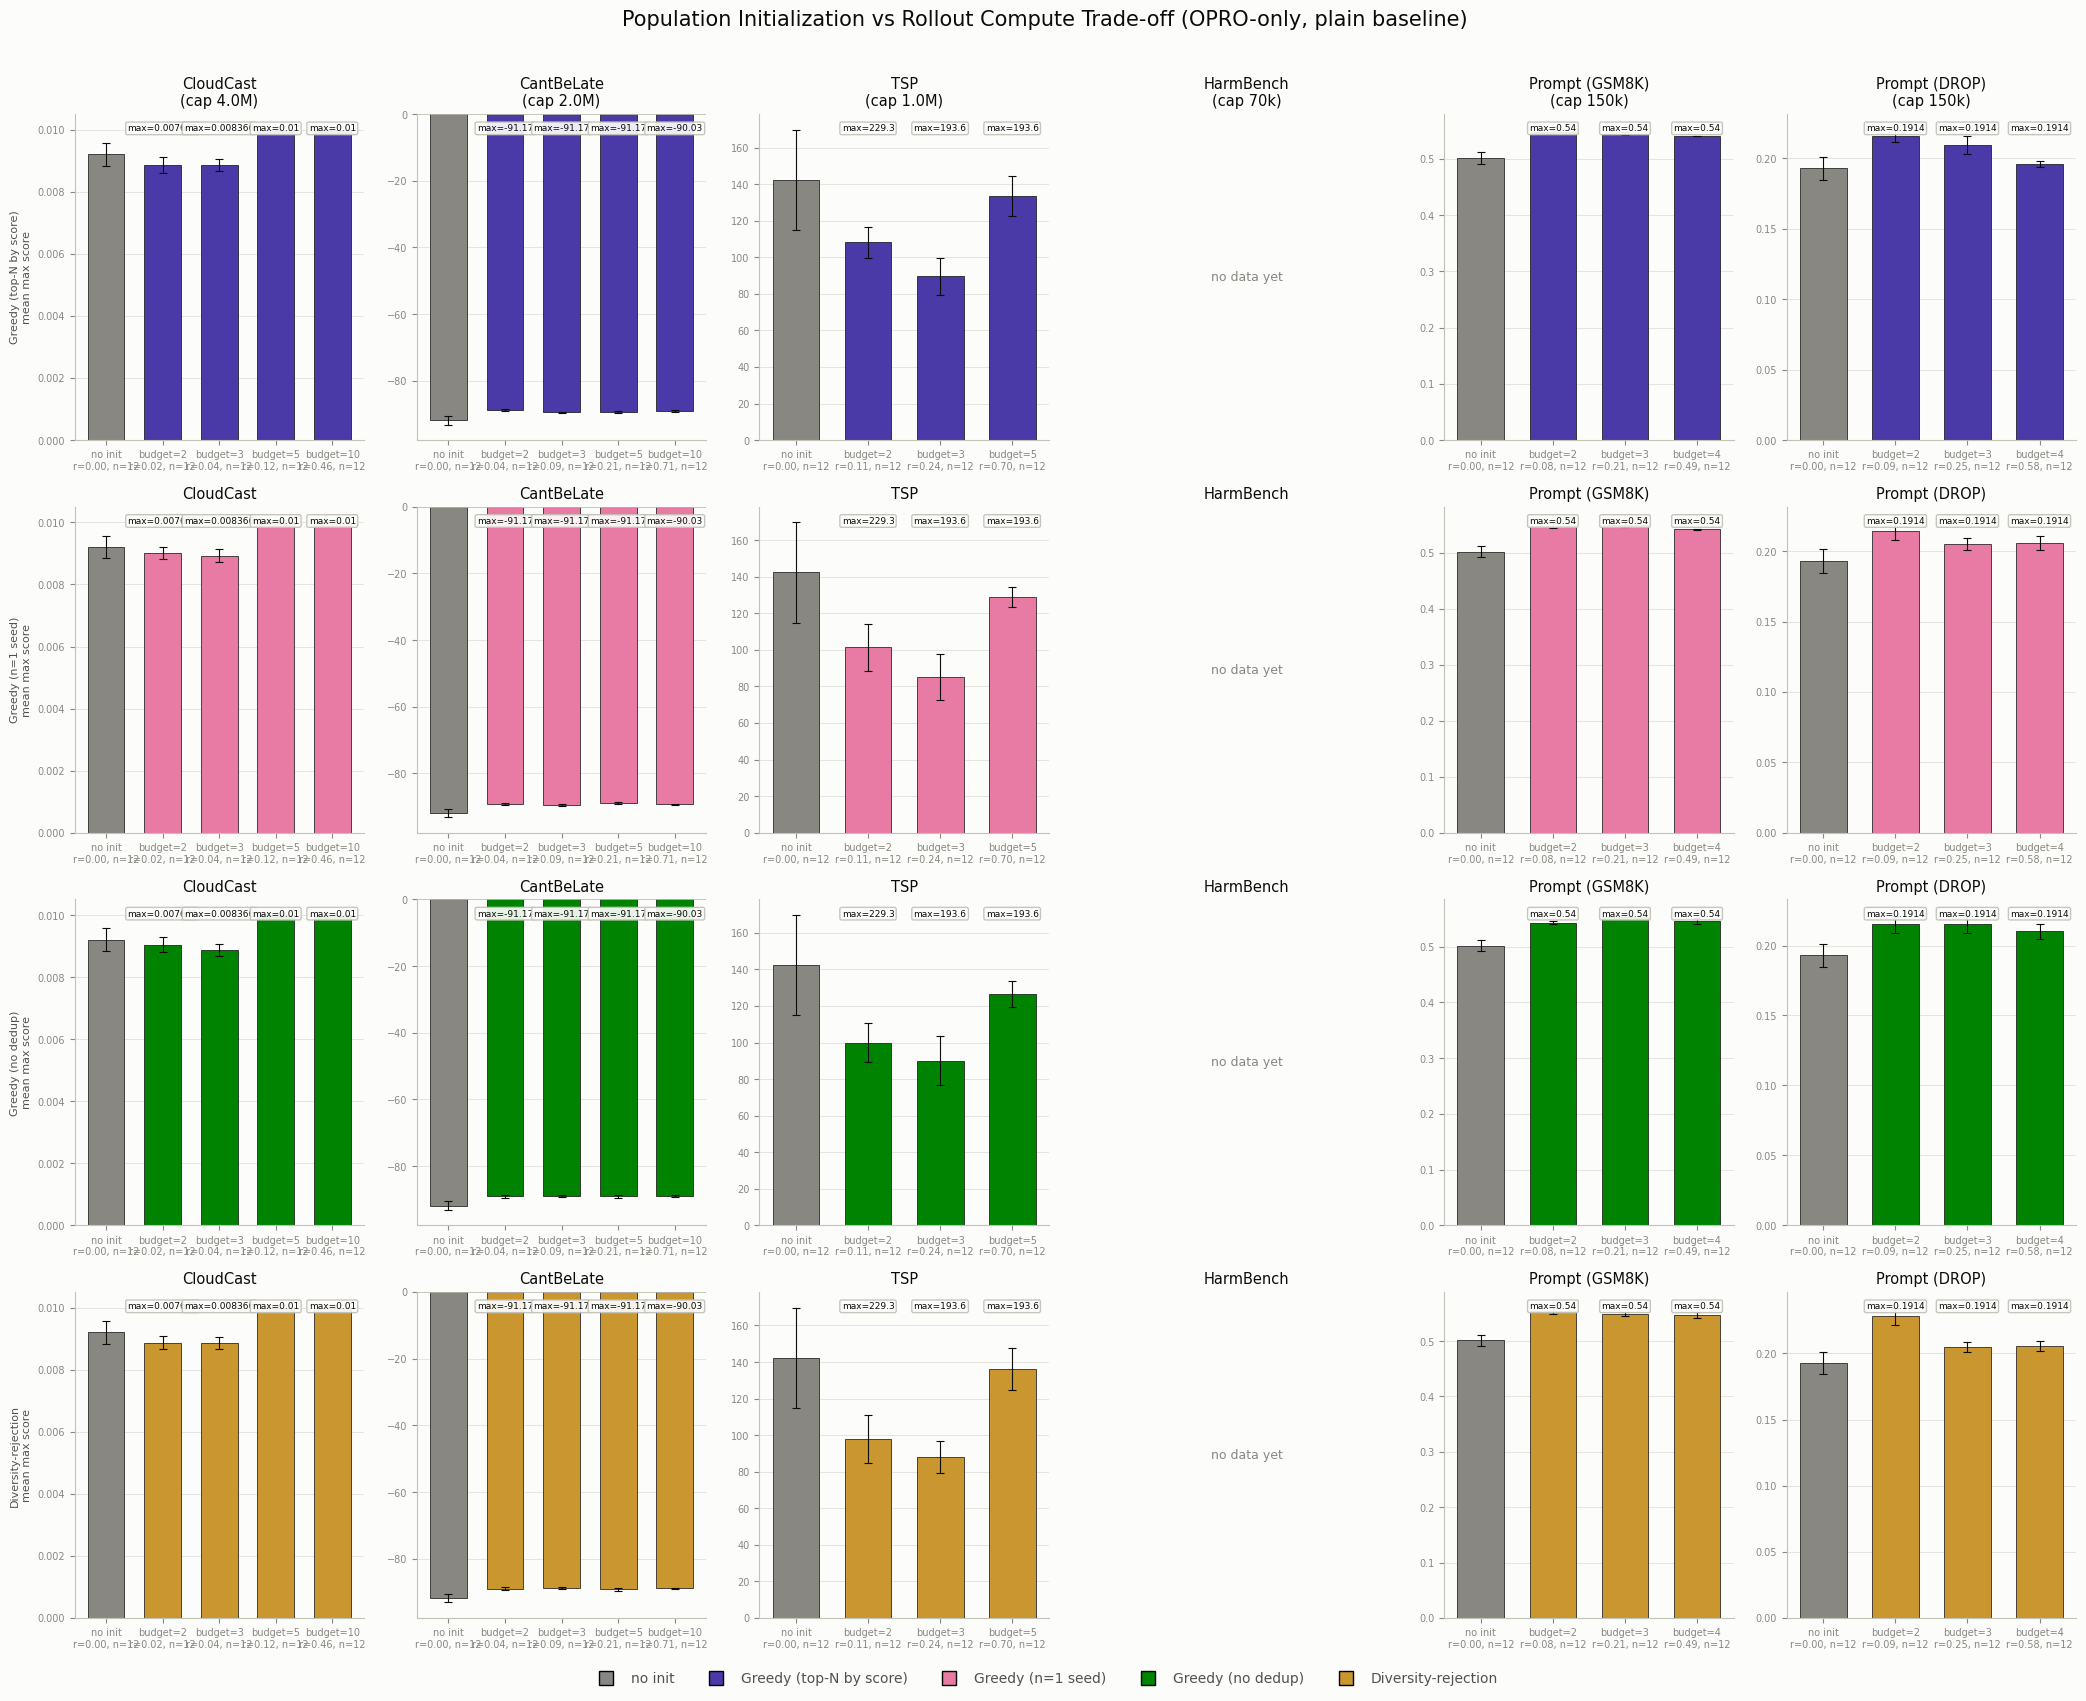

In [39]:
"""Build the 4x6 figure: population-initialization strategies vs no-init,
mean capped max-score bars at init:rollout compute ratio bins (see loader
cell above). One row per strategy, one column per task. Bar-height/
annotation style modeled on the user's proof-of-concept reference figure
(single-line 'max=<seed pool's own best score>, r=<ratio>, n=<matched
variants>' per bar) -- simpler than general_rollout.ipynb's later 4-line
seed/ni-max/mean/ni-mean version, per the user.
"""


def compute_ratio_bars(column_key: str, strategy: str) -> list[dict]:
    cap = POP_INIT_TOKEN_CAP[column_key]
    sign = -1.0 if column_key == 'tsp' else 1.0
    # TSP only: zero-base against the true optimum instead of raw distance
    # from a zero baseline (see markdown cell above / clean_visual5b's
    # same treatment) -- keeps the zero-baseline honest while keeping the
    # real spread between bars legible.
    baseline_offset = sign * TSP_TRUE_OPTIMUM if column_key == 'tsp' else 0.0

    noinit_values = [
        v for label, records in runs_by_column.get(column_key, {}).items()
        if (v := capped_running_max(
            np.array([r['cumulative_tokens_spent'] for r in records], dtype=float),
            np.array([r['score'] for r in records], dtype=float),
            cap,
        )) is not None
    ]

    bars = []
    if noinit_values:
        signed = [sign * v - baseline_offset for v in noinit_values]
        bars.append({
            'tick_label': 'no init',
            'ratio': 0.0,
            'mean_score': float(np.mean(signed)),
            'sem': sem(signed),
            'n': len(noinit_values),
            'max_score': None,
        })

    for entry in pop_init_bins.get(column_key, {}).get(strategy, []):
        cost_tokens = entry['cost_tokens']
        ratio = cost_tokens / (cap - cost_tokens)
        signed = [sign * v - baseline_offset for v in entry['values']]
        bars.append({
            'tick_label': f"budget={entry['budget']}",
            'ratio': ratio,
            'mean_score': float(np.mean(signed)),
            'sem': sem(signed),
            'n': len(signed),
            'max_score': sign * entry['max_score'] - baseline_offset,
        })

    bars.sort(key=lambda b: b['ratio'])
    return bars


fig, axes = plt.subplots(
    len(INIT_STRATEGY_ORDER), 6, figsize=(21, 4.2 * len(INIT_STRATEGY_ORDER)),
    facecolor=SURFACE, sharex=False, sharey=False,
)

for row_idx, strategy in enumerate(INIT_STRATEGY_ORDER):
    for col_idx, column_key in enumerate(COLUMN_ORDER):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor(SURFACE)
        cap = POP_INIT_TOKEN_CAP[column_key]
        title = COLUMN_TITLES[column_key]
        if row_idx == 0:
            title = f'{title}\n(cap {tokens_fmt(cap)})'

        bars = compute_ratio_bars(column_key, strategy)
        if len(bars) < 2:  # nothing but (at most) the 'no init' bar
            ax.text(
                0.5, 0.5, 'no data yet', ha='center', va='center',
                color=INK_MUTED, fontsize=9, transform=ax.transAxes,
            )
            ax.set_title(title, color=INK_PRIMARY, fontsize=10.5)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            continue

        x = np.arange(len(bars))
        heights = [b['mean_score'] for b in bars]
        errs = [b['sem'] for b in bars]
        colors = [
            COLOR_NOINIT if b['ratio'] == 0 else INIT_STRATEGY_COLOR[strategy]
            for b in bars
        ]
        ax.bar(
            x, heights, yerr=errs, capsize=3,
            error_kw={'ecolor': INK_PRIMARY, 'elinewidth': 0.8, 'capthick': 0.8},
            color=colors, edgecolor=INK_PRIMARY, linewidth=0.5, width=0.65,
        )
        ax.axhline(0, color=BASELINE, linewidth=0.6, zorder=1)
        ax.set_xticks(x)
        ax.set_xticklabels(
            [f"{b['tick_label']}\nr={b['ratio']:.2f}, n={b['n']}" for b in bars],
            fontsize=6.5, color=INK_SECONDARY,
        )
        for i, b in enumerate(bars):
            if b['max_score'] is None:
                continue
            ax.text(
                x[i], 0.97, f"max={b['max_score']:.4g}",
                transform=ax.get_xaxis_transform(), ha='center', va='top',
                fontsize=6.5, color=INK_PRIMARY,
                bbox={
                    'facecolor': SURFACE, 'edgecolor': BASELINE,
                    'boxstyle': 'round,pad=0.2', 'alpha': 0.92,
                },
            )

        ax.set_title(title, color=INK_PRIMARY, fontsize=10.5)
        if col_idx == 0:
            ylabel = f'{INIT_STRATEGY_TITLES[strategy]}\nmean max score'
            if column_key == 'tsp':
                ylabel += '\n(excess dist. over optimum)'
            ax.set_ylabel(ylabel, color=INK_SECONDARY, fontsize=8)
        ax.tick_params(colors=INK_MUTED, labelsize=7)
        for spine in ax.spines.values():
            spine.set_color(BASELINE)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', color=GRIDLINE, linewidth=0.6)
        ax.set_axisbelow(True)

legend_handles = [
    plt.Line2D([0], [0], marker='s', color='none', markerfacecolor=COLOR_NOINIT,
               markersize=10, label='no init'),
] + [
    plt.Line2D([0], [0], marker='s', color='none',
               markerfacecolor=INIT_STRATEGY_COLOR[s], markersize=10,
               label=INIT_STRATEGY_TITLES[s])
    for s in INIT_STRATEGY_ORDER
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=5, frameon=False,
    labelcolor=INK_SECONDARY, fontsize=10, bbox_to_anchor=(0.5, -0.005),
)

fig.suptitle(
    'Population Initialization vs Rollout Compute Trade-off (OPRO-only, plain baseline)',
    color=INK_PRIMARY, fontsize=15, y=1.0,
)
fig.tight_layout(rect=(0, 0.015, 1, 0.99))

fig.savefig(
    os.path.join(FIGS_DIR, 'clean_visual6_population_init_by_strategy.pdf'),
    bbox_inches='tight',
)
print(
    'saved to '
    f'{os.path.join(FIGS_DIR, "clean_visual6_population_init_by_strategy.pdf")}',
)

plt.show()
